<a href="https://colab.research.google.com/github/suphitchakh-web/SC663402_Data-Warehouse-and-Big-Data-Analytics/blob/main/Homework_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


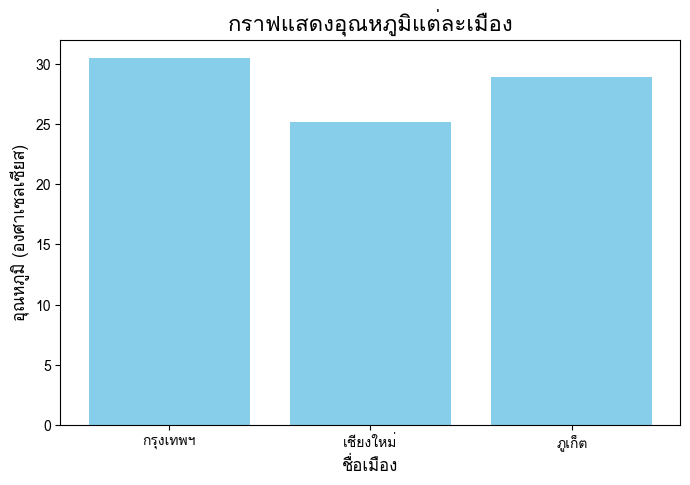

In [9]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [10]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [11]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


ข้อ 1.1 `s["a"]` เป็นการเลือกข้อมูลโดยอ้างอิงจาก label ของ index จึงได้ค่า 10 ส่วน `s.iloc[0]` เป็นการเลือกข้อมูลตามตำแหน่ง โดยตำแหน่งที่ 0 คือข้อมูลตัวแรก จึงได้ค่า 10 เช่นกัน ส่วน `s[["a", "c"]]` เป็นการเลือกข้อมูลหลายรายการโดยใช้ label และผลลัพธ์เป็น Series

ในทางปฏิบัติ ควรใช้การเลือกด้วย label เมื่อต้องการเข้าถึงข้อมูลจากชื่อ index และใช้ `.iloc[]` เมื่อต้องการเลือกข้อมูลตามตำแหน่งของข้อมูล


In [12]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


ข้อ 1.2 คำสั่ง `df["city"]` จะเลือกคอลัมน์ `city` ออกมาเป็นชนิดข้อมูล Series จึงมีขนาด `(2075,)` ซึ่งเป็นข้อมูลหนึ่งมิติ ส่วนคำสั่ง `df[["city"]]` จะเลือกคอลัมน์ `city` ออกมาเป็นชนิดข้อมูล DataFrame จึงมีขนาด `(2075, 1)` ซึ่งเป็นข้อมูลสองมิติ แม้ว่าจะเลือกคอลัมน์เดียวกัน แต่โครงสร้างข้อมูลที่ได้แตกต่างกัน การใช้ `df["city"]` เหมาะกับการนำคอลัมน์เดียวไปประมวลผล ส่วน `df[["city"]]` เหมาะเมื่อ ต้องการคงรูปแบบตาราง DataFrame ไว้สำหรับการประมวลผลข้อมูลต่อไป


In [13]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


ข้อ 1.3 คำสั่ง `df.loc[0:3]` และ `df.iloc[0:3]` แตกต่างกันที่วิธีการเลือกแถว โดย `loc` ใช้ label ของ index ในการเลือกข้อมูล และช่วง `0:3` จะรวม index 3 ด้วย จึงได้ข้อมูล 4 แถว ทำให้มีขนาด `(4, 10)` ส่วน `iloc` ใช้ตำแหน่งของข้อมูลในการเลือก และช่วง `0:3` จะไม่รวมตำแหน่งที่ 3 ตามหลักการ slice ของ Python จึงได้ข้อมูล 3 แถว ทำให้มีขนาด `(3, 10)`

การใช้งานจริง `loc` เหมาะสำหรับการเลือกข้อมูลโดยอ้างอิงจาก label หรือเงื่อนไขของ index ส่วน `iloc` เหมาะสำหรับการเลือกข้อมูลตามตำแหน่งของแถวหรือคอลัมน์


In [14]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


ข้อ 1.4 คำสั่ง `df.groupby("city")["temperature_c"].count()` จะนับจำนวนค่าที่ไม่เป็นค่าว่างของคอลัมน์ `temperature_c` ในแต่ละเมือง ดังนั้นถ้ามีค่า `temperature_c` ที่เป็นค่าว่าง จำนวนที่นับได้จะไม่รวมแถวนั้น

ส่วนคำสั่ง `df.groupby("city").size()` จะนับจำนวนแถวทั้งหมดในแต่ละกลุ่ม โดยไม่สนใจว่าค่าใน `temperature_c` จะเป็นค่าว่างหรือไม่ จากผลลัพธ์พบว่า Beijing มีค่า `count()` เท่ากับ 89 แต่ `size()` เท่ากับ 90 แสดงว่ามีข้อมูลจำนวน 1 แถวที่ค่า `temperature_c` เป็นค่าว่าง

การใช้งานจริง `count()` เหมาะสำหรับตรวจสอบจำนวนข้อมูลที่มีค่าจริงและไม่เป็นค่าว่าง ส่วน `size()` เหมาะสำหรับนับจำนวนระเบียนหรือจำนวนแถวทั้งหมดในแต่ละกลุ่ม


In [15]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


ข้อ 1.5 คำสั่ง `df.groupby("city")["temperature_c"].mean()` จะเลือกคอลัมน์ `temperature_c` เป็น Series แล้วคำนวณค่าเฉลี่ยของอุณหภูมิในแต่ละเมือง จึงได้ผลลัพธ์เป็น Series

ส่วนคำสั่ง `df.groupby("city")[["temperature_c"]].mean()` จะเลือกคอลัมน์ `temperature_c` เป็น DataFrame แล้วคำนวณค่าเฉลี่ยเช่นเดียวกัน จึงได้ผลลัพธ์เป็น DataFrame ที่มี 1 คอลัมน์

ดังนั้นค่าที่คำนวณได้จากทั้งสองคำสั่งมีค่าเท่ากัน แต่ชนิดและโครงสร้างของผลลัพธ์แตกต่างกัน โดยแบบแรกเหมาะกับการนำข้อมูลคอลัมน์เดียวไปใช้งานในรูปแบบ Series ส่วนแบบที่สองเหมาะกับการใช้งานที่ต้องการคงโครงสร้างข้อมูลแบบ DataFrame เช่น การนำไปประมวลผลร่วมกับหลายคอลัมน์ในขั้นตอนต่อไป


In [16]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


ข้อ 1.6 เมื่อใช้ `a + b` ซึ่งเป็น Series ของ pandas การคำนวณจะจับคู่ข้อมูลตามค่า index ที่ตรงกัน ไม่ได้จับคู่ตามตำแหน่ง ดังนั้น `x` จะคำนวณเป็น `1 + 30 = 31`, `y` เป็น `2 + 20 = 22` และ `z` เป็น `3 + 10 = 13` จึงได้ผลลัพธ์เป็น Series ที่มีค่า `[31, 22, 13]` ตามลำดับของ index

ส่วน `a.to_numpy() + b.to_numpy()` จะเปลี่ยน Series เป็น NumPy array ทำให้ไม่สนใจ index และคำนวณข้อมูลตามตำแหน่ง จึงได้ `[11, 22, 33]`

ความแตกต่างนี้มีประโยชน์เมื่อทำงานกับข้อมูล pandas ที่มี index เพราะ pandas สามารถจับคู่ข้อมูลตาม label ได้โดยอัตโนมัติ ทำให้ลดความผิดพลาดจากการนำข้อมูลที่มีลำดับต่างกันมาคำนวณกัน ส่วนการใช้ NumPy เหมาะเมื่อเราต้องการคำนวณตามตำแหน่งของข้อมูลโดยไม่ใช้ index


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [17]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [18]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

print("3 เมืองที่มีปริมาณฝนรวมสูงสุด:")
print(rain_by_city.nlargest(3))

rain_share = rain_by_city / rain_by_city.sum() * 100
print("\nสัดส่วนปริมาณฝนของแต่ละเมือง (%):")
print(rain_share.round(2))

n_above_mean = (rain_by_city > rain_by_city.mean()).sum()
print("\nจำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย:", n_above_mean)


3 เมืองที่มีปริมาณฝนรวมสูงสุด:
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

สัดส่วนปริมาณฝนของแต่ละเมือง (%):
city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64

จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย: 8


ข้อ 2.1 สร้าง Series ชื่อ `rain_by_city` โดยใช้ `groupby("city")` เพื่อจัดกลุ่มข้อมูลตามเมือง และใช้ `sum()` เพื่อคำนวณปริมาณฝนรวมของแต่ละเมือง โดยมีชื่อเมืองเป็น index

จากนั้นใช้ `nlargest(3)` เพื่อหา 3 เมืองที่มีปริมาณฝนรวมสูงที่สุด โดยไม่กำหนดค่าผลลัพธ์เอง

สำหรับสัดส่วนปริมาณฝนของแต่ละเมือง คำนวณจากปริมาณฝนรวมของเมืองนั้นหารด้วยปริมาณฝนรวมของทุกเมือง แล้วคูณด้วย 100 และปัดเศษให้เหลือทศนิยม 2 ตำแหน่ง

สุดท้ายคำนวณค่าเฉลี่ยของปริมาณฝนรวมของทุกเมืองด้วย `mean()` แล้วตรวจสอบว่าเมืองใดมีปริมาณฝนรวมมากกว่าค่าเฉลี่ย จากนั้นใช้ `sum()` เพื่อนับจำนวนเมืองที่ตรงตามเงื่อนไข


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [19]:
# คำตอบข้อ 2.2
city_profile = (
    df.groupby("city", as_index=False)
      .agg(
          country=("country", "first"),
          region=("region", "first"),
          n_records=("city", "size"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum")
      )
)

print(city_profile)

            city       country         region  n_records   avg_temp  \
0       Auckland   New Zealand        Oceania         90  17.804444   
1        Bangkok      Thailand           Asia         91  32.453846   
2        Beijing         China           Asia         90  15.598876   
3         Berlin       Germany         Europe         90  12.383146   
4   Buenos Aires     Argentina  South America         90  19.171910   
5          Cairo         Egypt         Africa         91  26.089888   
6      Cape Town  South Africa         Africa         90  30.162921   
7     Chiang Mai      Thailand           Asia         91  29.680220   
8          Lagos       Nigeria         Africa         90  29.494253   
9           Lima          Peru  South America         90  21.490000   
10        London            UK         Europe         90  13.490909   
11   Los Angeles           USA  North America         90  20.657303   
12   Mexico City        Mexico  North America         90  19.187778   
13    

In [20]:
print(city_profile.shape)
print(city_profile.columns)

(23, 6)
Index(['city', 'country', 'region', 'n_records', 'avg_temp', 'total_rain'], dtype='object')


ข้อ 2.2 ข้อนี้สร้าง DataFrame ชื่อ `city_profile` โดยใช้ `groupby("city")` เพื่อจัดกลุ่มข้อมูลตามเมือง ทำให้แต่ละเมืองมีเพียง 1 แถวในผลลัพธ์

กำหนดคอลัมน์ `country` และ `region` ด้วยค่าแรกของแต่ละกลุ่ม ส่วน `n_records` ใช้ `size` เพื่อนับจำนวนข้อมูลทั้งหมดของแต่ละเมือง และ `avg_temp` ใช้ `mean` เพื่อหาค่าเฉลี่ยของอุณหภูมิของแต่ละเมือง

สำหรับ `total_rain` ใช้ `sum` เพื่อหาปริมาณฝนรวมของแต่ละเมือง และใช้ `as_index=False` เพื่อให้ `city` ยังคงเป็นคอลัมน์ของ DataFrame แทนที่จะกลายเป็น index

วิธีนี้ใช้ `groupby` และ aggregation ของ pandas โดยตรง จึงเป็นการประมวลผลแบบ vectorized และไม่มีการกำหนดค่าคำตอบแบบ hard-code


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [21]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [22]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [23]:
# คำตอบข้อ 3.1
df_31 = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=[
        "date",
        "city",
        "region",
        "temperature_c",
        "humidity_pct",
        "rainfall_mm"
    ],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={
        "city": "category",
        "region": "category"
    },
    index_col="city"
)

print(df_31.dtypes)
df_31.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


ข้อ 3.1 ข้อนี้ใช้ `pd.read_csv()` คำสั่งเดียวเพื่อจัดการข้อมูลตั้งแต่ขั้นตอนการนำเข้า

`usecols` ใช้เลือกเฉพาะคอลัมน์ที่โจทย์กำหนด ส่วน `parse_dates=["date"]` ใช้แปลงคอลัมน์ `date` ให้เป็นชนิด datetime ตั้งแต่ตอนอ่านไฟล์

กำหนด `na_values=[999, -999]` เพื่อให้ค่าที่กำหนดถูกอ่านเป็นค่าว่าง และใช้ `dtype` เพื่อกำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`

สุดท้ายใช้ `index_col="city"` เพื่อกำหนดให้ `city` เป็น index ของ DataFrame จากนั้นใช้ `.dtypes` และ `.info()` เพื่อตรวจสอบชนิดข้อมูลและโครงสร้างของ DataFrame ที่นำเข้า


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [24]:
# คำตอบข้อ 3.2
# หน่วยความจำของ DataFrame เดิม
memory_original = df.memory_usage(deep=True).sum()

# หน่วยความจำของ DataFrame จากข้อ 3.1
memory_31 = df_31.memory_usage(deep=True).sum()

# คำนวณเปอร์เซ็นต์ที่ลดลง
memory_reduction_pct = (
    (memory_original - memory_31)
    / memory_original
    * 100
)

print("หน่วยความจำเดิม:", memory_original, "bytes")
print("หน่วยความจำหลังปรับ:", memory_31, "bytes")
print("หน่วยความจำลดลง:", round(memory_reduction_pct, 2), "%")

หน่วยความจำเดิม: 571645 bytes
หน่วยความจำหลังปรับ: 72917 bytes
หน่วยความจำลดลง: 87.24 %


ข้อ 3.2 ข้อนี้ใช้ `.memory_usage(deep=True)` เพื่อวัดปริมาณหน่วยความจำที่ DataFrame ใช้ โดย `deep=True` จะตรวจสอบหน่วยความจำของข้อมูลภายในชนิดข้อมูลที่เป็น object อย่างละเอียดมากขึ้น

จากนั้นนำหน่วยความจำของ DataFrame เดิมมาเปรียบเทียบกับ DataFrame ที่สร้างในข้อ 3.1 และคำนวณเปอร์เซ็นต์การลดลงด้วยสูตร

เปอร์เซ็นต์ที่ลดลง = (หน่วยความจำเดิม − หน่วยความจำใหม่) / หน่วยความจำเดิม × 100

การกำหนด `city` และ `region` เป็นชนิด `category` ช่วยลดการใช้หน่วยความจำเมื่อข้อมูลมีค่าซ้ำกันจำนวนมาก เพราะไม่จำเป็นต้องเก็บข้อความเดิมซ้ำทุกแถว นอกจากนี้ ข้อ 3.1 ยังเลือกอ่านเฉพาะคอลัมน์ที่โจทย์กำหนด จึงทำให้ไม่ต้องเก็บคอลัมน์อื่นที่ไม่ได้ใช้งานไว้ใน DataFrame


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [25]:
# คำตอบข้อ 3.3
# กำหนดตัวแปรสำหรับเก็บค่าสูงสุดและต่ำสุด
global_max = None
global_min = None

# สำหรับค่าเฉลี่ยรายเมือง ต้องสะสม "ผลรวม" และ "จำนวนข้อมูล"
city_sum = {}
city_count = {}

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=500
):
    # ค่าสูงสุดและต่ำสุดของแต่ละ chunk
    chunk_max = chunk["temperature_c"].max()
    chunk_min = chunk["temperature_c"].min()

    if global_max is None or chunk_max > global_max:
        global_max = chunk_max

    if global_min is None or chunk_min < global_min:
        global_min = chunk_min

    # สะสมผลรวมและจำนวนข้อมูลแยกตามเมือง
    grouped = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])

    for city, row in grouped.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

# คำนวณค่าเฉลี่ยรายเมืองหลังจากอ่านครบทุก chunk
avg_temp_by_city = pd.Series(
    {
        city: city_sum[city] / city_count[city]
        for city in city_sum
    },
    name="avg_temperature"
)

print("อุณหภูมิสูงสุด:", global_max)
print("อุณหภูมิต่ำสุด:", global_min)

print("\nอุณหภูมิเฉลี่ยรายเมือง:")
print(avg_temp_by_city)

อุณหภูมิสูงสุด: 999.0
อุณหภูมิต่ำสุด: -88.0

อุณหภูมิเฉลี่ยรายเมือง:
Auckland        17.804444
Bangkok         32.453846
Beijing         15.598876
Berlin          12.383146
Buenos Aires    19.171910
Cairo           26.089888
Cape Town       30.162921
Chiang Mai      29.680220
Lagos           29.494253
Lima            21.490000
London          13.490909
Los Angeles     20.657303
Mexico City     19.187778
Moscow           7.233333
Mumbai          30.872222
Nairobi         21.440000
New York        15.476667
Paris           25.811236
Sao Paulo       22.841573
Singapore       40.083333
Sydney          20.347778
Tokyo           18.414773
Toronto         11.613636
Name: avg_temperature, dtype: float64


ข้อ 3.3 ข้อนี้ใช้ `chunksize` เพื่ออ่านข้อมูลทีละส่วน ทำให้ไม่จำเป็นต้องโหลดข้อมูลทั้งไฟล์เข้า memory พร้อมกัน และไม่ได้ใช้ `pd.concat` ตามเงื่อนไขของโจทย์

สำหรับการหาอุณหภูมิสูงสุดและต่ำสุด สามารถเปรียบเทียบค่าของแต่ละ chunk แล้วเก็บค่าสูงสุดและต่ำสุดของทั้งไฟล์ไว้ได้

ส่วนการหาอุณหภูมิเฉลี่ยรายเมือง ไม่ควรนำค่าเฉลี่ยของแต่ละ chunk มาเฉลี่ยกันโดยตรง เพราะแต่ละ chunk อาจมีจำนวนข้อมูลของแต่ละเมืองไม่เท่ากัน การทำเช่นนั้นจะให้น้ำหนักแต่ละ chunk เท่ากันและอาจทำให้ค่าเฉลี่ยสุดท้ายผิด

วิธีที่ถูกต้องคือสะสมผลรวม (`sum`) และจำนวนข้อมูล (`count`) ของแต่ละเมืองจากทุก chunk แล้วจึงนำผลรวมทั้งหมดหารด้วยจำนวนข้อมูลทั้งหมดของเมืองนั้น วิธีนี้จะได้ค่าเฉลี่ยที่ถูกต้องโดยไม่ต้องเก็บข้อมูลทั้งไฟล์ไว้ในหน่วยความจำพร้อมกัน


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [27]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [28]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [29]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
    "example_value": df.bfill().iloc[0]
}).sort_values("n_missing", ascending=False)

print(summary)

                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


ข้อ 4.1 สร้าง DataFrame `summary` โดยใช้ข้อมูลจากแต่ละคอลัมน์ของ `df` ได้แก่ ชนิดข้อมูล (`dtype`), จำนวนค่าว่าง (`n_missing`), ร้อยละของค่าว่าง (`pct_missing`), จำนวนค่าที่ไม่ซ้ำกัน (`n_unique`) และตัวอย่างค่าจากแต่ละคอลัมน์ (`example_value`)

การใช้ `df.bfill().iloc[0]` ช่วยเลือกค่าที่ไม่เป็นค่าว่างตัวแรกของแต่ละคอลัมน์มาเป็น `example_value` โดยไม่ต้องวนซ้ำทีละคอลัมน์ จากนั้นใช้ `.sort_values("n_missing", ascending=False)` เพื่อเรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุดไปน้อยที่สุด


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [30]:
# คำตอบข้อ 4.2
# 1. temperature_c อยู่นอกช่วง -60 ถึง 60
temp_invalid = ~df["temperature_c"].between(-60, 60)

# 2. humidity_pct อยู่นอกช่วง 0 ถึง 100
humidity_invalid = ~df["humidity_pct"].between(0, 100)

# 3. ผิดปกติอย่างน้อยหนึ่งคอลัมน์
any_invalid = temp_invalid | humidity_invalid

print("จำนวนแถวที่ temperature_c ผิดปกติ:", temp_invalid.sum())
print("จำนวนแถวที่ humidity_pct ผิดปกติ:", humidity_invalid.sum())
print("จำนวนแถวที่ผิดปกติอย่างน้อยหนึ่งคอลัมน์:", any_invalid.sum())

จำนวนแถวที่ temperature_c ผิดปกติ: 25
จำนวนแถวที่ humidity_pct ผิดปกติ: 85
จำนวนแถวที่ผิดปกติอย่างน้อยหนึ่งคอลัมน์: 109


ข้อ 4.2 ใช้ `.between()` เพื่อตรวจสอบว่าค่าอยู่ในช่วงที่กำหนดหรือไม่ และใช้ `~` เพื่อกลับเงื่อนไขให้ได้เฉพาะค่าที่อยู่นอกช่วง

สำหรับข้อ 3 ใช้ `|` (OR) ระหว่างเงื่อนไข `temperature_c` และ `humidity_pct` เพื่อให้แต่ละแถวถูกนับเพียงครั้งเดียว แม้ว่าแถวนั้นจะมีค่าผิดปกติทั้งสองคอลัมน์ก็ตาม จากนั้นใช้ `.sum()` เพื่อนับจำนวนแถวที่เข้าเงื่อนไข


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [31]:
# คำตอบข้อ 4.3
country_key = df["country"].str.strip().str.lower()

country_groups = (
    pd.DataFrame({
        "original": df["country"],
        "key": country_key
    })
    .drop_duplicates()
    .sort_values("key")
)

print(country_groups)

          original           key
1371     ARGENTINA     argentina
6        Argentina     argentina
17       Australia     australia
60          Brazil        brazil
433         CANADA        canada
92          Canada        canada
12           China         china
43           Egypt         egypt
22          France        france
366        GERMANY       germany
55         Germany       germany
3            India         india
1            Japan         japan
1493         JAPAN         japan
1770         KENYA         kenya
11           Kenya         kenya
7           Mexico        mexico
5      New Zealand   new zealand
1330   NEW ZEALAND   new zealand
18         Nigeria       nigeria
19            Peru          peru
10          Russia        russia
1127     SINGAPORE     singapore
24       Singapore     singapore
4     South Africa  south africa
54        Thailand      thailand
44              UK            uk
0              USA           usa


In [32]:
country_title = df["country"].str.title()

print(country_title.unique())
print("จำนวนประเทศหลังใช้ title():", country_title.nunique())

['Usa' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'Uk' 'Thailand' 'Germany' 'Brazil' 'Canada']
จำนวนประเทศหลังใช้ title(): 21


In [33]:
country_normalized = df["country"].str.strip()

print(sorted(country_normalized.dropna().unique()))
print("จำนวนประเทศ:", country_normalized.nunique())

['ARGENTINA', 'Argentina', 'Australia', 'Brazil', 'CANADA', 'Canada', 'China', 'Egypt', 'France', 'GERMANY', 'Germany', 'India', 'JAPAN', 'Japan', 'KENYA', 'Kenya', 'Mexico', 'NEW ZEALAND', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'SINGAPORE', 'Singapore', 'South Africa', 'Thailand', 'UK', 'USA']
จำนวนประเทศ: 28


ข้อ 4.3 คอลัมน์ `country` มีค่าที่แตกต่างกันจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ จึงต้องตรวจสอบค่าที่แทนประเทศเดียวกันก่อนทำการ normalize โดยสามารถใช้ `str.strip()` เพื่อตัดช่องว่างหัวท้าย และใช้ `str.lower()` เป็น key สำหรับเปรียบเทียบโดยไม่สนใจตัวพิมพ์เล็ก–ใหญ่

เมื่อทดลองใช้ `df["country"].str.title()` วิธีนี้จะเปลี่ยนตัวอักษรต้นของทุกคำให้เป็นตัวพิมพ์ใหญ่ ซึ่งอาจทำให้ชื่อประเทศที่มีรูปแบบการเขียนเฉพาะเสียหายได้ ดังนั้น `title()` ไม่ใช่วิธี normalize ที่ปลอดภัยสำหรับข้อมูลชุดนี้ เพราะเป็นการเปลี่ยนรูปแบบชื่อทุกค่าโดยไม่ตรวจสอบว่าชื่อเดิมควรเขียนอย่างไร

วิธี normalize ที่เหมาะสมคือใช้ `str.strip()` เพื่อตัดช่องว่างหัวท้ายก่อน แล้วตรวจสอบค่าที่เหลือและแก้เฉพาะค่าที่เป็นชื่อประเทศเดียวกันด้วย mapping ที่กำหนดจากข้อมูลจริง วิธีนี้ไม่เปลี่ยนรูปแบบชื่อประเทศอื่นโดยไม่จำเป็น และเมื่อ normalize ถูกต้องแล้ว จำนวนประเทศควรเป็น **21 ประเทศ จากทั้งหมด 23 เมือง** ตามเงื่อนไขตรวจสอบของโจทย์


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [34]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [35]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [36]:
# คำตอบข้อ 5.1
# 1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก
#    เฉพาะ 3 คอลัมน์สุดท้าย
print(df.iloc[0:20:2, -3:])

# 2. ห้าแถวสุดท้าย โดยเรียงจากแถวล่างสุดขึ้นไป
print(df.iloc[-1:-6:-1])

# 3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตาราง
#    และคอลัมน์สุดท้าย
middle_row = len(df) // 2
print(df.iloc[middle_row, -1])

    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  
2074        

ข้อ 5.1 กำหนดให้ใช้ `.iloc[]` เท่านั้น ดังนั้นจึงเลือกข้อมูลโดยอ้างอิงจากตำแหน่งของแถวและคอลัมน์ ไม่ใช้ชื่อคอลัมน์

ข้อ 1 ใช้ `df.iloc[0:20:2, -3:]` โดย `0:20:2` หมายถึงเริ่มจากตำแหน่ง 0 ถึงก่อนตำแหน่ง 20 และข้ามทีละ 2 ตำแหน่ง จึงได้แถวตำแหน่งเลขคู่ 10 แถวแรก ส่วน `-3:` หมายถึงเลือกตั้งแต่ 3 คอลัมน์สุดท้ายจนถึงคอลัมน์สุดท้าย

ข้อ 2 ใช้ `df.iloc[-1:-6:-1]` โดยเริ่มจากแถวสุดท้ายที่ตำแหน่ง `-1` แล้วถอยกลับทีละ 1 จนถึงก่อนตำแหน่ง `-6` จึงได้ทั้งหมด 5 แถว และเรียงจากแถวล่างสุดขึ้นไป

ข้อ 3 ต้องหาตำแหน่งแถวกึ่งกลางจากจำนวนแถวก่อน จึงใช้ `len(df) // 2` เพื่อคำนวณตำแหน่งแถวกึ่งกลาง แล้วใช้ `df.iloc[middle_row, -1]` เพื่อเลือกค่าในแถวนั้นและคอลัมน์สุดท้ายเพียงค่าเดียว

ทั้งสามข้อใช้ตำแหน่งแถวและคอลัมน์ผ่าน `.iloc[]` โดยไม่มีการอ้างอิงชื่อคอลัมน์ตามเงื่อนไขของโจทย์


### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [37]:
# คำตอบข้อ 5.2
multi = df.set_index(["region", "city"]).sort_index()

# 1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
ans1 = multi.loc["Asia", ["date", "temperature_c"]]
print(ans1)

# 2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
ans2 = multi.loc[
    multi.index.get_level_values("city").isin(["Tokyo", "Bangkok"])
]
print(ans2)

# 3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ขึ้นต้นด้วยตัวอักษร B
ans3 = multi.loc[
    multi.index.get_level_values("city").str.startswith("B")
]
print(ans3)

               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0
...             ...            ...
Tokyo    2025-01-08           15.3
Tokyo    2025-02-19           19.1
Tokyo    2025-01-02           16.3
Tokyo    2025-03-30           20.4
Tokyo    2025-03-06           16.6

[542 rows x 2 columns]
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Bangkok         53  2025-02-22  Thailand           30.8          74.5   
       Bangkok         10  2025-01-10  Thailand           28.9          71.3   
       Bangkok         27  2025-01-27  Thailand           27.9          75.5   
       Bangkok          3  2025-01-03  Thailand           29.0          71.3   
       Bangkok         87  2025-03-28  Th

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [38]:
# คำตอบข้อ 5.3
# รูปแบบที่ 1
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

In [39]:
# รูปแบบที่ 2
subset = df.loc[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

ข้อ 5.3 คำสั่ง `subset = df[df["city"] == "Bangkok"]` แล้วแก้ `subset["temperature_c"]` โดยตรงไม่ควรใช้ เพราะ `subset` อาจเป็น view หรือ copy ของ `df` ทำให้เกิด `SettingWithCopyWarning` และไม่ควรคาดหวังว่าการแก้ไขจะเปลี่ยน `df` อย่างแน่นอน

ถ้าต้องการแก้ไข `df` จริง ควรใช้ `.loc[]` เพื่อระบุทั้งเงื่อนไขของแถวและคอลัมน์ที่ต้องการแก้ไขโดยตรง ส่วนถ้าต้องการทำงานกับข้อมูลแยกจาก `df` ควรใช้ `.copy()` อย่างชัดเจน

**แนวปฏิบัติของฉัน:** ถ้าต้องการแก้ DataFrame ต้นฉบับ จะใช้ `.loc[]` โดยตรง และถ้าต้องการแก้เฉพาะข้อมูลที่แยกออกมา จะใช้ `.copy()` ก่อนแก้ไข เพื่อให้พฤติกรรมของโค้ดชัดเจนและหลีกเลี่ยง `SettingWithCopyWarning`


---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [40]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

176
1894
740
295


In [41]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [42]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [43]:
# คำตอบข้อ 6.1
# 1. ภูมิภาค Asia, ฝน > 5 mm และความเร็วลม > 20 km/h
result1 = df[
    (df["region"] == "Asia")
    & (df["rainfall_mm"] > 5)
    & (df["wind_speed_kmh"] > 20)
]

print(result1)

# 2. ไม่ใช่ Bangkok, Tokyo และ London
#    และความชื้นอยู่ระหว่าง 40 ถึง 60
result2 = df[
    (~df["city"].isin(["Bangkok", "Tokyo", "London"]))
    & (df["humidity_pct"].between(40, 60))
]

print(result2)

# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
result3 = df[df.isna().sum(axis=1) >= 2]

print(result3)

# 4. ชื่อเมืองมีคำว่า New หรือ San
#    โดยใช้ str.contains() และ regular expression
result4 = df[
    df["city"].str.contains(r"New|San", regex=True, na=False)
]

print(result4)



      record_id        date        city    country region  temperature_c  \
38          517  2025-03-08      Mumbai      India   Asia           32.6   
49          525  2025-03-16      Mumbai      India   Asia           33.6   
178          51  2025-02-20     Bangkok   Thailand   Asia            0.0   
234         330  2025-03-01   Singapore  Singapore   Asia           32.5   
286         465  2025-01-15      Mumbai      India   Asia           30.1   
290          23  2025-01-23     Bangkok   Thailand   Asia            0.0   
328         232  2025-02-21       Tokyo      Japan   Asia           21.6   
350         352  2025-03-23   Singapore  Singapore   Asia           35.4   
374          15  2025-01-15     Bangkok   Thailand   Asia            0.0   
413          75  2025-03-16     Bangkok   Thailand   Asia            0.0   
424         125  2025-02-04  Chiang Mai   Thailand   Asia           27.3   
427         283  2025-01-13   Singapore  Singapore   Asia           32.2   
447         

ข้อ 6.1 ข้อ 1 ใช้ `&` เชื่อมเงื่อนไขทั้งสามข้อเข้าด้วยกัน โดยต้องอยู่ในภูมิภาค Asia มีปริมาณฝนมากกว่า 5 มิลลิเมตร และมีความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง

ข้อ 2 ใช้ `~df["city"].isin(...)` เพื่อเลือกเมืองที่ไม่ใช่ Bangkok, Tokyo และ London และใช้ `.between(40, 60)` เพื่อตรวจสอบว่าความชื้นอยู่ระหว่าง 40 ถึง 60

ข้อ 3 ใช้ `df.isna().sum(axis=1)` เพื่อนับจำนวนค่าว่างในแต่ละแถว แล้วเลือกเฉพาะแถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป

ข้อ 4 ใช้ `.str.contains()` ร่วมกับ regular expression `r"New|San"` โดย `|` หมายถึง “หรือ” จึงเลือกชื่อเมืองที่มีคำว่า New หรือ San และใช้ `na=False` เพื่อให้ค่าที่เป็นค่าว่างไม่ทำให้เกิดปัญหาในการกรอง


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [44]:
# คำตอบข้อ 6.2
# หาค่า percentile ที่ 99 ของปริมาณฝน
rain_p99 = df["rainfall_mm"].quantile(0.99)

# 1. อุณหภูมิที่ผิดปกติให้แทนด้วยค่าว่าง
temp_clean = df["temperature_c"].where(
    df["temperature_c"].between(-60, 60)
)

# 2. จำกัดปริมาณฝนไม่ให้เกินค่า percentile ที่ 99
rain_capped = df["rainfall_mm"].mask(
    df["rainfall_mm"] > rain_p99,
    rain_p99
)

# สร้างคอลัมน์ใหม่
df["temperature_clean"] = temp_clean
df["rainfall_capped"] = rain_capped

print(df[[
    "temperature_c",
    "temperature_clean",
    "rainfall_mm",
    "rainfall_capped"
]].head())

   temperature_c  temperature_clean  rainfall_mm  rainfall_capped
0           15.7               15.7          6.3              6.3
1           18.3               18.3          0.0              0.0
2           20.6               20.6          1.2              1.2
3           31.0               31.0          8.0              8.0
4           19.1               19.1          0.0              0.0


ข้อ 6.2 ใช้ `.where()` กับ `temperature_c` เพื่อคงค่าอุณหภูมิที่อยู่ในช่วงที่ยอมรับได้ คือ -60 ถึง 60 องศาเซลเซียส และแทนค่าที่อยู่นอกช่วงด้วย `NaN` โดยไม่ลบแถวออกจาก DataFrame

ส่วน `rainfall_mm` ใช้ `.mask()` โดยหาค่าเปอร์เซ็นไทล์ที่ 99 ก่อน แล้วแทนค่าฝนที่สูงกว่า percentile ดังกล่าวด้วยค่า percentile ที่ 99 ทำให้ยังคงจำนวนแถวและข้อมูลส่วนอื่นไว้ แต่ลดผลกระทบจากค่าฝนที่สูงผิดปกติ

แนวทางนี้แตกต่างจากการลบแถวทิ้ง เพราะ `.where()` และ `.mask()` ยังรักษาแถวเดิมไว้ ทำให้ข้อมูลจากคอลัมน์อื่นในแถวนั้นยังสามารถนำไปวิเคราะห์ต่อได้ เช่น การหาค่าเฉลี่ยหรือวิเคราะห์ความสัมพันธ์ โดยค่าที่ผิดปกติจะถูกจัดการเฉพาะคอลัมน์ที่มีปัญหา ในขณะที่การลบแถวจะทำให้ข้อมูลของทุกคอลัมน์ในแถวนั้นหายไปด้วย


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [45]:
# คำตอบข้อ 6.3
# ค่าเฉลี่ยอุณหภูมิของแต่ละเมือง
city_mean = df.groupby("city")["temperature_c"].transform("mean")

# ระยะห่างจากค่าเฉลี่ยของเมือง
df["deviation"] = (df["temperature_c"] - city_mean).abs()

# เลือกแถวที่มี deviation มากที่สุดของแต่ละเมือง
idx = df.groupby("city")["deviation"].idxmax()

result = (
    df.loc[idx, ["city", "date", "temperature_c", "deviation"]]
      .sort_values("city")
      .reset_index(drop=True)
)

print(result)

            city        date  temperature_c   deviation
0       Auckland  2025-02-27           25.6    7.795556
1        Bangkok  2025-02-22            0.0    0.000000
2        Beijing  2025-03-06           22.6    7.001124
3         Berlin  2025-03-26           19.4    7.016854
4   Buenos Aires  2025-01-19          -88.0  107.171910
5          Cairo  2025-03-31           33.6    7.510112
6      Cape Town  2025-02-10          999.0  968.837079
7     Chiang Mai  2025-03-28           37.3    7.619780
8          Lagos  2025-01-01           21.1    8.394253
9           Lima  2025-01-22           12.9    8.590000
10        London  2025-02-09           23.4    9.909091
11   Los Angeles  2025-01-09           13.4    7.257303
12   Mexico City  2025-02-24           26.5    7.312222
13        Moscow  2025-01-20           -0.2    7.433333
14        Mumbai  2025-01-07           24.2    6.672222
15       Nairobi  2025-03-11           27.8    6.360000
16      New York  2025-03-16           24.5    9

ข้อ 6.3 เริ่มจากใช้ `groupby("city").transform("mean")` เพื่อคำนวณค่าเฉลี่ยอุณหภูมิของแต่ละเมืองและนำค่าเฉลี่ยนั้นกลับมาเทียบกับทุกแถวของเมืองเดียวกัน จากนั้นคำนวณ `deviation` เป็นค่าความแตกต่างแบบค่าสัมบูรณ์ระหว่างอุณหภูมิจริงกับค่าเฉลี่ยของเมือง

ต่อมาใช้ `groupby("city")["deviation"].idxmax()` เพื่อหาตำแหน่งของแถวที่มีค่า `deviation` มากที่สุดในแต่ละเมือง แล้วใช้ `.loc[]` ดึงเฉพาะ `city`, `date`, `temperature_c` และ `deviation` ทำให้ผลลัพธ์มีหนึ่งแถวต่อหนึ่งเมืองตามที่โจทย์กำหนด


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [46]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [47]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [48]:
# คำตอบข้อ 7.1
df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5
)

print(df[[
    "date",
    "year_month",
    "week_of_year",
    "day_name",
    "is_weekend"
]].head())

        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True
3 2025-01-19    2025-01             3    Sunday        True
4 2025-02-03    2025-02             6    Monday       False


ข้อ 7.1 ใช้ `.assign()` เพียงคำสั่งเดียวในการสร้างคอลัมน์ใหม่ทั้ง 4 คอลัมน์จาก `date`

`year_month` แปลงวันที่ให้เป็นปีและเดือนในรูป `YYYY-MM`, `week_of_year` ใช้หมายเลขสัปดาห์ของปี, `day_name` ใช้ชื่อวัน และ `is_weekend` ตรวจสอบว่าวันนั้นเป็นวันเสาร์หรือวันอาทิตย์หรือไม่ โดยค่าที่ได้จะเป็น `True` หรือ `False`

การใช้ `.assign()` ทำให้สามารถสร้างหลายคอลัมน์ต่อเนื่องกันในคำสั่งเดียว และยังคงรูปแบบการเขียนแบบ vectorized โดยไม่ต้องวนลูปทีละแถว


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [49]:
# คำตอบข้อ 7.2
# 1. ข้อมูลครอบคลุมทั้งหมดกี่วัน
date_range = pd.date_range(
    df["date"].min(),
    df["date"].max(),
    freq="D"
)

dates_with_data = pd.DatetimeIndex(df["date"].dt.normalize().unique())
missing_dates = date_range.difference(dates_with_data)

print("จำนวนวันที่ครอบคลุม:", len(date_range))
print("วันที่ไม่มีข้อมูล:", missing_dates)
print("มีวันที่ไม่มีข้อมูลหรือไม่:", len(missing_dates) > 0)


# 2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์
#    เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
temp_by_region_day = (
    df.groupby(["region", "is_weekend"])["temperature_c"]
      .mean()
      .unstack()
      .rename(columns={
          False: "weekday",
          True: "weekend"
      })
)

print("\nอุณหภูมิเฉลี่ยตามภูมิภาค:")
print(temp_by_region_day)


# 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
rain_by_city_month = (
    df.groupby(["city", "year_month"])["rainfall_mm"]
      .sum()
)

max_rain_month = (
    rain_by_city_month
    .groupby(level="city")
    .idxmax()
)

result3 = pd.DataFrame({
    "city": max_rain_month.index,
    "year_month": max_rain_month.str[1],
    "total_rainfall_mm": [
        rain_by_city_month.loc[idx]
        for idx in max_rain_month
    ]
}).reset_index(drop=True)

print("\nเดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง:")
print(result3)

จำนวนวันที่ครอบคลุม: 90
วันที่ไม่มีข้อมูล: DatetimeIndex([], dtype='datetime64[ns]', freq='D')
มีวันที่ไม่มีข้อมูลหรือไม่: False

อุณหภูมิเฉลี่ยตามภูมิภาค:
is_weekend       weekday    weekend
region                             
Africa         27.944444  23.884466
Asia           22.978851  21.120513
Europe         15.820472  11.951961
North America  16.715686  16.841176
Oceania        18.943750  19.401923
South America  21.703141  19.844156

เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง:
            city year_month  total_rainfall_mm
0       Auckland    2025-03              150.0
1        Bangkok    2025-02              243.9
2        Beijing    2025-02               87.4
3         Berlin    2025-03              100.1
4   Buenos Aires    2025-02              121.2
5          Cairo    2025-02               48.0
6      Cape Town    2025-01               98.3
7     Chiang Mai    2025-03              188.0
8          Lagos    2025-03              233.0
9           Lima    2025-01               8

ข้อ 7.2

ข้อ 1 ใช้ `pd.date_range()` สร้างวันที่ทุกวันตั้งแต่วันที่น้อยที่สุดถึงวันที่มากที่สุดในข้อมูล จากนั้นใช้ `.difference()` เปรียบเทียบกับวันที่มีข้อมูลจริง เพื่อหาวันที่อยู่ในช่วงดังกล่าวแต่ไม่มีข้อมูลเลย จึงสามารถตรวจสอบได้ทั้งจำนวนวันที่ครอบคลุมและวันที่ขาดหาย

ข้อ 2 ใช้ `groupby(["region", "is_weekend"])` เพื่อแบ่งข้อมูลตามภูมิภาคและสถานะวันหยุดสุดสัปดาห์ แล้วคำนวณค่าเฉลี่ยของ `temperature_c` จากนั้นใช้ `.unstack()` เพื่อจัดให้วันธรรมดาและวันหยุดสุดสัปดาห์อยู่คนละคอลัมน์ ทำให้สามารถเปรียบเทียบภายในแต่ละภูมิภาคได้ง่าย

ข้อ 3 ใช้ `groupby(["city", "year_month"])` เพื่อรวมปริมาณฝนเป็นรายเดือนของแต่ละเมือง แล้วใช้ `idxmax()` เพื่อหาเดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง ทำให้ผลลัพธ์มีหนึ่งเดือนที่มีฝนรวมสูงสุดต่อหนึ่งเมือง


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [50]:
# คำตอบข้อ 7.3
bkk = (
    df[df["city"] == "Bangkok"]
    .set_index("date")
    .sort_index()
)

result = bkk.resample("7D").agg(
    avg_temperature=("temperature_c", "mean"),
    total_rainfall=("rainfall_mm", "sum")
)

print(result)

            avg_temperature  total_rainfall
date                                       
2025-01-01              0.0            65.7
2025-01-08              0.0            47.6
2025-01-15              0.0            58.7
2025-01-22              0.0            50.0
2025-01-29              0.0            55.4
2025-02-05              0.0            65.1
2025-02-12              0.0            60.2
2025-02-19              0.0            42.5
2025-02-26              0.0            61.7
2025-03-05              0.0            49.1
2025-03-12              0.0            56.4
2025-03-19              0.0            41.9
2025-03-26              0.0            31.3


ข้อ 7.3 `.resample()` ใช้สำหรับจัดกลุ่มข้อมูลตามช่วงเวลา โดยต้องมี `DatetimeIndex` ก่อน ในข้อนี้จึงกรองเฉพาะ Bangkok แล้วกำหนด `date` เป็น index จากนั้นใช้ `.resample("7D")` เพื่อแบ่งข้อมูลออกเป็นช่วงละ 7 วัน และใช้ `.agg()` เพื่อคำนวณอุณหภูมิเฉลี่ยกับปริมาณฝนรวมในตารางเดียวกัน

ความแตกต่างจาก `groupby(df["date"].dt.month)` คือ `groupby()` จะจัดกลุ่มตามค่าของเดือน เช่น มกราคม กุมภาพันธ์ และมีลักษณะเป็นการแบ่งกลุ่มตามหมวดหมู่ของข้อมูล ส่วน `.resample()` จัดกลุ่มตามช่วงเวลาที่ต่อเนื่องกันและสามารถกำหนดความถี่ได้ เช่น ทุก 7 วัน ทุกวัน หรือทุกเดือน

กรณีที่ต้องวิเคราะห์ข้อมูลตามช่วงเวลาที่มีความถี่แน่นอน เช่น ต้องการสรุปข้อมูลทุก 7 วัน ทุก 15 นาที หรือทุก 1 ชั่วโมง และต้องการให้ช่วงเวลาที่ไม่มีข้อมูลยังคงปรากฏเป็นช่วงเวลาในผลลัพธ์ ควรใช้ `.resample()` เพราะ `groupby()` ตามค่าเดือนหรือหมวดหมู่ไม่ได้ทำหน้าที่แบ่งช่วงเวลาแบบ time-based frequency โดยตรง


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [51]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [52]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [53]:
# คำตอบข้อ 8.1
# 1. คอลัมน์ที่มีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

most_missing_col = missing_count.idxmax()

print("คอลัมน์ที่มีค่าว่างมากที่สุด:", most_missing_col)
print("จำนวนค่าว่าง:", missing_count[most_missing_col])
print("คิดเป็นร้อยละ:", missing_pct[most_missing_col])


# 2. สัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
missing_temp_by_city = (
    df.groupby("city")["temperature_c"]
      .agg(
          n_records="size",
          n_missing="count"
      )
)

# เปลี่ยน count ให้เป็นจำนวนค่าว่าง
missing_temp_by_city["n_missing"] = (
    missing_temp_by_city["n_records"]
    - missing_temp_by_city["n_missing"]
)

missing_temp_by_city["pct_missing"] = (
    missing_temp_by_city["n_missing"]
    / missing_temp_by_city["n_records"]
    * 100
).round(2)

print("\nสัดส่วนค่าว่างของ temperature_c รายเมือง")
print(missing_temp_by_city)


# 3. ผลกระทบของการใช้ dropna()
df_dropna = df.dropna()

remaining_pct = (
    len(df_dropna) / len(df) * 100
)

print("\nจำนวนแถวเดิม:", len(df))
print("จำนวนแถวหลัง dropna():", len(df_dropna))
print("เหลือข้อมูลคิดเป็นร้อยละ:", round(remaining_pct, 2))


# หาเมืองที่สูญเสียข้อมูลมากที่สุด
city_loss = (
    df.groupby("city")
      .size()
      .sub(df_dropna.groupby("city").size(), fill_value=0)
      .rename("n_lost")
)

city_total = df.groupby("city").size()

city_loss_pct = (
    city_loss / city_total * 100
).round(2)

city_loss_summary = pd.DataFrame({
    "n_lost": city_loss,
    "pct_lost": city_loss_pct
}).sort_values("n_lost", ascending=False)

print("\nการสูญเสียข้อมูลรายเมือง")
print(city_loss_summary)

print("\nเมืองที่สูญเสียข้อมูลมากที่สุด:",
      city_loss.idxmax())

คอลัมน์ที่มีค่าว่างมากที่สุด: humidity_pct
จำนวนค่าว่าง: 82
คิดเป็นร้อยละ: 3.95

สัดส่วนค่าว่างของ temperature_c รายเมือง
              n_records  n_missing  pct_missing
city                                           
Auckland             90          0         0.00
Bangkok              91          0         0.00
Beijing              90          1         1.11
Berlin               90          1         1.11
Buenos Aires         90          1         1.11
Cairo                91          2         2.20
Cape Town            90          1         1.11
Chiang Mai           91          0         0.00
Lagos                90          3         3.33
Lima                 90          0         0.00
London               90          2         2.22
Los Angeles          90          1         1.11
Mexico City          90          0         0.00
Moscow               91          1         1.10
Mumbai               90          0         0.00
Nairobi              91          1         1.10
New York      

ข้อ 8.1

1. ตรวจสอบค่าว่างด้วย `df.isna().sum()` เพื่อหาจำนวนค่าว่างของแต่ละคอลัมน์ และใช้ `idxmax()` เพื่อหาคอลัมน์ที่มีค่าว่างมากที่สุด จากนั้นใช้ `df.isna().mean() * 100` เพื่อคำนวณเป็นร้อยละ

2. ตรวจสอบการกระจายของค่าว่างใน `temperature_c` ด้วย `groupby("city")` โดยคำนวณจำนวนข้อมูลทั้งหมดและจำนวนค่าว่างของแต่ละเมือง แล้วนำจำนวนค่าว่างหารด้วยจำนวนข้อมูลทั้งหมดของเมืองนั้นเพื่อหาสัดส่วนค่าว่างเป็นร้อยละ จึงสามารถเปรียบเทียบได้ว่าแต่ละเมืองมีค่าว่างมากน้อยแตกต่างกันหรือไม่

3. ใช้ `dropna()` เพื่อลบทุกแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์ แล้วเปรียบเทียบจำนวนแถวก่อนและหลังลบเพื่อหาว่าข้อมูลเหลือกี่เปอร์เซ็นต์ ส่วนเมืองที่สูญเสียข้อมูลมากที่สุดหาได้จากการเปรียบเทียบจำนวนแถวของแต่ละเมืองก่อนและหลัง `dropna()`

วิธีนี้ใช้การคำนวณแบบ vectorized และ `groupby()` เป็นหลัก โดยไม่ได้วนซ้ำทีละแถว


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [54]:
# คำตอบข้อ 8.2
# 1. เติมด้วยค่าเฉลี่ยของทั้งตาราง
global_mean = df["temperature_c"].mean()

temp_global = df["temperature_c"].fillna(global_mean)


# 2. เติมด้วยค่าเฉลี่ยของเมืองตนเอง
city_mean = df.groupby("city")["temperature_c"].transform("mean")

temp_city = df["temperature_c"].fillna(city_mean)


# 3. เติมด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"]).copy()

sorted_df["temp_ffill"] = (
    sorted_df.groupby("city")["temperature_c"].ffill()
)


# รวมผลของทั้ง 3 วิธีไว้ใน DataFrame เดียว
comparison = pd.DataFrame({
    "city": sorted_df["city"],
    "global_mean": sorted_df["temperature_c"].fillna(global_mean),
    "city_mean": sorted_df["temperature_c"].fillna(
        sorted_df.groupby("city")["temperature_c"].transform("mean")
    ),
    "previous_day": sorted_df["temp_ffill"]
})

# เปรียบเทียบค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมือง
result = pd.concat([
    comparison.groupby("city")["global_mean"].agg(
        mean="mean", std="std"
    ).assign(method="global_mean"),

    comparison.groupby("city")["city_mean"].agg(
        mean="mean", std="std"
    ).assign(method="city_mean"),

    comparison.groupby("city")["previous_day"].agg(
        mean="mean", std="std"
    ).assign(method="previous_day")
]).reset_index()

print(result)

            city       mean         std        method
0       Auckland  17.804444    2.799475   global_mean
1        Bangkok   0.000000    0.000000   global_mean
2        Beijing  15.652225    2.903054   global_mean
3         Berlin  12.472225    2.716171   global_mean
4   Buenos Aires  19.185559   11.752118   global_mean
..           ...        ...         ...           ...
64     Sao Paulo  22.801111    2.797852  previous_day
65     Singapore  40.083333  103.011324  previous_day
66        Sydney  20.347778    2.820201  previous_day
67         Tokyo  18.356667    2.522396  previous_day
68       Toronto  11.597778    2.719343  previous_day

[69 rows x 4 columns]


ข้อ 8.2 การเติมด้วยค่าเฉลี่ยรวมทั้งตารางจะใช้ค่าเฉลี่ยของ `temperature_c` จากทุกเมืองมาแทนค่าว่าง จึงเป็นวิธีที่ง่าย แต่ไม่ได้คำนึงถึงความแตกต่างของอุณหภูมิระหว่างแต่ละเมือง ส่วนการเติมด้วยค่าเฉลี่ยของเมืองตนเองจะใช้ `groupby("city").transform("mean")` ทำให้ค่าที่เติมสอดคล้องกับระดับอุณหภูมิเฉลี่ยของเมืองนั้นมากกว่า

วิธีที่สามเรียงข้อมูลตาม `city` และ `date` ก่อน แล้วใช้ `groupby("city").ffill()` เพื่อเติมค่าจากข้อมูลก่อนหน้าภายในเมืองเดียวกัน วิธีนี้คำนึงถึงลำดับเวลา แต่ถ้าค่าว่างอยู่ก่อนข้อมูลแรกของเมือง ก็อาจยังคงเป็นค่าว่าง

สำหรับข้อมูลชุดนี้ การเติมด้วย **ค่าเฉลี่ยของเมืองตนเอง** เหมาะสมกว่าในกรณีที่ต้องการรักษาความแตกต่างของอุณหภูมิระหว่างเมือง เพราะแต่ละเมืองมีลักษณะอุณหภูมิแตกต่างกัน ส่วนการเติมด้วย **ค่าเฉลี่ยรวมทั้งตาราง** มีโอกาสทำให้ค่าของเมืองที่มีอุณหภูมิเฉลี่ยสูงหรือต่ำถูกดึงเข้าหาค่าเฉลี่ยรวมมากเกินไป

การเติมค่าด้วยค่าเฉลี่ย โดยเฉพาะค่าเฉลี่ยของเมือง จะทำให้ค่าที่เติมมีค่าเท่ากับค่าเฉลี่ยและไม่มีความแปรปรวนเพิ่มขึ้น จึงสามารถทำให้ส่วนเบี่ยงเบนมาตรฐานของเมืองลดลงอย่างผิดธรรมชาติได้ ส่วน `ffill` จะขึ้นอยู่กับค่าก่อนหน้าและอาจรักษาความแปรปรวนของข้อมูลได้มากกว่า แต่ก็มีความเสี่ยงที่จะนำค่าจากวันก่อนหน้ามาใช้แทนวันที่ขาดข้อมูล


### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [55]:
# คำตอบข้อ 8.3
# 1. ตรวจสอบคู่ (city, date) ที่ซ้ำกัน
duplicate_key = df.duplicated(
    subset=["city", "date"],
    keep=False
)

print("จำนวนคู่ (city, date) ที่ซ้ำกัน:",
      df.loc[duplicate_key, ["city", "date"]]
        .drop_duplicates()
        .shape[0])


# 2. ตรวจสอบว่าแถวซ้ำทุกคอลัมน์หรือซ้ำเฉพาะคีย์
duplicate_all = df.duplicated(keep=False)

print("\nจำนวนแถวที่ซ้ำทุกคอลัมน์:",
      df.loc[duplicate_all].shape[0])

print("\nแถวที่มีคู่ (city, date) ซ้ำ:")
print(
    df.loc[duplicate_key]
      .sort_values(["city", "date"])
      [["city", "date", "temperature_c",
        "humidity_pct", "rainfall_mm",
        "wind_speed_kmh", "pressure_hpa"]]
)


# ตรวจว่าคู่คีย์เดียวกันมีค่าที่วัดต่างกันหรือไม่
key_value_check = (
    df.loc[duplicate_key]
      .groupby(["city", "date"])
      [["temperature_c", "humidity_pct",
        "rainfall_mm", "wind_speed_kmh",
        "pressure_hpa"]]
      .nunique(dropna=False)
)

print("\nจำนวนค่าที่แตกต่างกันภายในแต่ละคู่ (city, date):")
print(key_value_check)


# 3. ขจัดข้อมูลซ้ำ
# นโยบาย: หากทุกคอลัมน์เหมือนกัน ให้เก็บไว้เพียงแถวแรก
df_clean = df.drop_duplicates().copy()

print("\nจำนวนแถวหลังขจัดข้อมูลซ้ำ:", len(df_clean))

# ตรวจสอบว่าตรงกับ 23 เมือง × 90 วันหรือไม่
n_cities = df_clean["city"].nunique()
n_days = df_clean["date"].nunique()
expected_rows = n_cities * n_days

print("จำนวนเมือง:", n_cities)
print("จำนวนวัน:", n_days)
print("จำนวนแถวที่คาดหวัง:", expected_rows)
print("ตรงตามที่กำหนดหรือไม่:", len(df_clean) == expected_rows)

จำนวนคู่ (city, date) ที่ซ้ำกัน: 5

จำนวนแถวที่ซ้ำทุกคอลัมน์: 10

แถวที่มีคู่ (city, date) ซ้ำ:
            city       date  temperature_c  humidity_pct  rainfall_mm  \
507      Bangkok 2025-03-03            0.0          85.2          5.6   
1304     Bangkok 2025-03-03            0.0          85.2          5.6   
1392       Cairo 2025-02-25           27.8          37.8          0.6   
1517       Cairo 2025-02-25           27.8          37.8          0.6   
569   Chiang Mai 2025-03-06           32.4          60.5          7.5   
1777  Chiang Mai 2025-03-06           32.4          60.5          7.5   
566       Moscow 2025-03-13           10.9          67.1          0.5   
1077      Moscow 2025-03-13           10.9          67.1          0.5   
1948     Nairobi 2025-02-23           22.4          57.9          4.3   
2010     Nairobi 2025-02-23           22.4          57.9          4.3   

      wind_speed_kmh  pressure_hpa  
507             18.3           NaN  
1304            18.3      

ข้อ 8.3 ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งคู่ `(city, date)` ดังนั้นจึงใช้คู่นี้เป็นคีย์ในการตรวจสอบข้อมูลซ้ำ

1. ตรวจสอบด้วย `duplicated(subset=["city", "date"], keep=False)` แล้วนับคู่ `(city, date)` ที่ไม่ซ้ำกันด้วย `drop_duplicates()` เพื่อหาจำนวนคีย์ที่ซ้ำกัน

2. ใช้ `duplicated()` โดยไม่กำหนด `subset` เพื่อตรวจสอบการซ้ำทุกคอลัมน์ แล้วเปรียบเทียบกับการซ้ำตามคีย์ `(city, date)` นอกจากนี้ใช้ `groupby(["city", "date"]).nunique()` กับคอลัมน์ค่าที่วัดได้ เพื่อแสดงหลักฐานว่าคู่คีย์เดียวกันมีค่าการวัดแตกต่างกันหรือไม่

3. เลือกนโยบายว่า ถ้าข้อมูลซ้ำทุกคอลัมน์ ให้เก็บเพียงแถวแรกและลบแถวที่ซ้ำด้วย `drop_duplicates()` จากนั้นตรวจสอบจำนวนแถวที่เหลือกับ `23 × 90 = 2,070`

จากข้อมูลในไฟล์ จำนวนข้อมูลซ้ำตามคีย์ `(city, date)` คือ 5 และจำนวนแถวซ้ำทุกคอลัมน์ก็เป็น 5 ดังนั้นข้อมูลซ้ำในชุดนี้เป็นการซ้ำทั้งแถว ไม่ใช่กรณีที่คีย์เดียวกันแต่ค่าที่วัดได้แตกต่างกัน และหลัง `drop_duplicates()` ควรเหลือ 2,070 แถวตามเงื่อนไขตรวจสอบของโจทย์


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [56]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 18)


### ตัวอย่าง

In [57]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [58]:
# คำตอบข้อ 9.1
df = df.drop_duplicates().copy()

df["month"] = df["date"].dt.month

summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100)
)

print(summary.round(2))

              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  \
city                                                                         
Auckland         17.80        17.55      2.80       351.9                6   
Bangkok           0.00         0.00      0.00       680.0               23   
Beijing          15.60        15.50      2.87       250.1                2   
Berlin           12.38        12.30      2.60       268.4                6   
Buenos Aires     19.17        20.70     11.82       305.1                9   
Cairo            26.07        25.80      2.74       122.4                1   
Cape Town        30.16        18.90    103.90       239.3                0   
Chiang Mai       29.65        29.50      2.86       428.1                9   
Lagos            29.49        29.80      2.84       652.8               22   
Lima             21.49        21.30      3.11       180.3                1   
London           13.49        13.50      3.02       273.3       

ข้อ 9.1 ใช้ `groupby("city").agg()` เพื่อสรุปข้อมูลให้เหลือหนึ่งแถวต่อหนึ่งเมือง และใช้ **named aggregation** เพื่อกำหนดชื่อคอลัมน์ผลลัพธ์โดยตรง

* `avg_temp` ใช้ค่าเฉลี่ยของ `temperature_c`
* `median_temp` ใช้ค่ามัธยฐานของ `temperature_c`
* `std_temp` ใช้ส่วนเบี่ยงเบนมาตรฐานของ `temperature_c`
* `total_rain` ใช้ผลรวมของ `rainfall_mm`
* `heavy_rain_days` นับจำนวนวันที่มีฝนมากกว่า 10 มิลลิเมตร โดยใช้ฟังก์ชันที่นิยามภายใน `agg()`
* `pct_missing_temp` คำนวณสัดส่วนวันที่ `temperature_c` เป็นค่าว่าง โดย `isna().mean() * 100`

การใช้ `agg()` เพียงคำสั่งเดียวทำให้ได้ตารางสรุปรายเมืองที่มีสถิติทั้งหมดตามที่โจทย์กำหนด


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [59]:
# คำตอบข้อ 9.2
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month

summary_region_month = (
    df.groupby(["region", "month"])
      .agg(
          avg_temp=("temperature_c", "mean")
      )
      .reset_index()
)

print(summary_region_month.round(2))


# คู่ region และ month ที่มีอุณหภูมิเฉลี่ยสูงสุด
max_row = summary_region_month.loc[
    summary_region_month["avg_temp"].idxmax()
]

# คู่ region และ month ที่มีอุณหภูมิเฉลี่ยต่ำสุด
min_row = summary_region_month.loc[
    summary_region_month["avg_temp"].idxmin()
]

print("\nอุณหภูมิเฉลี่ยสูงสุด")
print(max_row)

print("\nอุณหภูมิเฉลี่ยต่ำสุด")
print(min_row)

           region  month  avg_temp
0          Africa      1     22.64
1          Africa      2     32.74
2          Africa      3     25.41
3            Asia      1     18.99
4            Asia      2     21.28
5            Asia      3     27.05
6          Europe      1     10.40
7          Europe      2     12.20
8          Europe      3     21.51
9   North America      1     15.17
10  North America      2     17.07
11  North America      3     18.04
12        Oceania      1     17.36
13        Oceania      2     19.73
14        Oceania      3     20.20
15  South America      1     19.19
16  South America      2     22.10
17  South America      3     22.29

อุณหภูมิเฉลี่ยสูงสุด
region         Africa
month               2
avg_temp    32.741441
Name: 1, dtype: object

อุณหภูมิเฉลี่ยต่ำสุด
region         Europe
month               1
avg_temp    10.398374
Name: 6, dtype: object


ข้อ 9.2 ใช้ `groupby(["region", "month"])` เพื่อแบ่งข้อมูลพร้อมกันตามภูมิภาคและเดือน แล้วใช้ `agg()` คำนวณ `avg_temp` ซึ่งเป็นอุณหภูมิเฉลี่ยของแต่ละคู่ภูมิภาค–เดือน

จากนั้นใช้ `.reset_index()` เพื่อเปลี่ยน `region` และ `month` จาก index กลับมาเป็นคอลัมน์ ทำให้ผลลัพธ์อยู่ในรูป DataFrame ปกติ

ใช้ `idxmax()` เพื่อหาตำแหน่งของแถวที่มี `avg_temp` สูงสุด และ `idxmin()` เพื่อหาตำแหน่งของแถวที่มี `avg_temp` ต่ำสุด แล้วใช้ `.loc[]` ดึงข้อมูลของคู่ `region` และ `month` นั้นออกมา

วิธีนี้ไม่ต้องกำหนดชื่อภูมิภาคหรือเดือนล่วงหน้า และค่าผลลัพธ์ทั้งหมดคำนวณจากข้อมูลจริง


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [60]:
# คำตอบข้อ 9.3
# ตารางสรุปจำนวนวันด้วย count และ size
n_days_compare = df.groupby("city").agg(
    n_days_count=("temperature_c", "count"),
    n_days_size=("temperature_c", "size"),
)

# แสดงเฉพาะเมืองที่ผลต่างกัน
diff = n_days_compare[
    n_days_compare["n_days_count"] != n_days_compare["n_days_size"]
]

print(n_days_compare)
print("\nเมืองที่ count และ size ให้ผลต่างกัน:")
print(diff)

print("\nจำนวนเมืองที่มีผลต่าง:", len(diff))
print("จำนวน missing temperature ทั้งหมด:",
      df["temperature_c"].isna().sum())

              n_days_count  n_days_size
city                                   
Auckland                90           90
Bangkok                 90           90
Beijing                 89           90
Berlin                  89           90
Buenos Aires            89           90
Cairo                   88           90
Cape Town               89           90
Chiang Mai              90           90
Lagos                   87           90
Lima                    90           90
London                  88           90
Los Angeles             89           90
Mexico City             90           90
Moscow                  89           90
Mumbai                  90           90
Nairobi                 89           90
New York                90           90
Paris                   89           90
Sao Paulo               89           90
Singapore               90           90
Sydney                  90           90
Tokyo                   88           90
Toronto                 88           90


ข้อ 9.3 `count` และ `size` ให้ผลต่างกันเมื่อในคอลัมน์ที่นำมานับมีค่า missing (`NaN`) โดย `count` จะนับเฉพาะค่าที่ไม่ใช่ `NaN` ส่วน `size` จะนับจำนวนแถวทั้งหมดในแต่ละกลุ่ม รวมแถวที่มีค่า `NaN` ด้วย

ดังนั้น ถ้าใช้ `temperature_c` เป็นตัวนับ `n_days` ค่า `n_days_count` อาจน้อยกว่า `n_days_size` ในเมืองที่มีข้อมูลอุณหภูมิหายไป หลักฐานสามารถดูได้จากตาราง `n_days_compare` และตาราง `diff` ที่แสดงเฉพาะเมืองที่สองวิธีให้ผลไม่เท่ากัน

การเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนได้ เช่น หากต้องการรายงานว่าเมืองนั้นมีข้อมูลทั้งหมดกี่วัน แต่ใช้ `count` แทน `size` จำนวนวันที่รายงานจะถูกนับต่ำกว่าความเป็นจริง เพราะวันที่มีอุณหภูมิเป็น `NaN` จะถูกตัดออกจากการนับ ในทางกลับกัน `size` เหมาะสำหรับนับจำนวนแถวหรือจำนวนวันทั้งหมดในแต่ละกลุ่ม แม้ว่าค่าของตัวแปรบางคอลัมน์จะหายไปก็ตาม


---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [61]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [62]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1960.000
mean        0.000
std         0.995
min        -9.069
25%        -0.517
50%        -0.079
75%         0.523
max         9.325
Name: temperature_c, dtype: float64


In [63]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [64]:
# คำตอบข้อ 10.1
# ตรวจสอบจำนวนแถวก่อน
n_before = len(df)

# 1) สัดส่วนปริมาณฝนของวันนั้นเทียบกับฝนรวมของเมือง
city_rain_total = df.groupby("city")["rainfall_mm"].transform("sum")
df["rain_share"] = df["rainfall_mm"] / city_rain_total

# 2) Z-score ของอุณหภูมิภายในเมือง
city_temp_mean = df.groupby("city")["temperature_c"].transform("mean")
city_temp_std = df.groupby("city")["temperature_c"].transform("std")

df["temp_z"] = (
    (df["temperature_c"] - city_temp_mean)
    / city_temp_std
)

# 3) อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมือง
city_month_avg = df.groupby(
    ["city", "month"]
)["temperature_c"].transform("mean")

df["city_rank_month"] = (
    city_month_avg.groupby(df["city"])
    .rank(method="min", ascending=False)
)

# ตรวจสอบจำนวนแถวไม่เปลี่ยน
n_after = len(df)

print("จำนวนแถวก่อน:", n_before)
print("จำนวนแถวหลัง:", n_after)
print("จำนวนแถวเท่าเดิมหรือไม่:", n_before == n_after)

# ตรวจสอบผลรวม rain_share ของแต่ละเมือง
rain_share_check = df.groupby("city")["rain_share"].sum()
print("\nผลรวม rain_share ในแต่ละเมือง:")
print(rain_share_check)

print("\nทุกเมืองมีผลรวมเท่ากับ 1 หรือไม่:",
      rain_share_check.round(10).eq(1).all())

จำนวนแถวก่อน: 2070
จำนวนแถวหลัง: 2070
จำนวนแถวเท่าเดิมหรือไม่: True

ผลรวม rain_share ในแต่ละเมือง:
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Cairo           1.0
Cape Town       1.0
Chiang Mai      1.0
Lagos           1.0
Lima            1.0
London          1.0
Los Angeles     1.0
Mexico City     1.0
Moscow          1.0
Mumbai          1.0
Nairobi         1.0
New York        1.0
Paris           1.0
Sao Paulo       1.0
Singapore       1.0
Sydney          1.0
Tokyo           1.0
Toronto         1.0
Name: rain_share, dtype: float64

ทุกเมืองมีผลรวมเท่ากับ 1 หรือไม่: True


ข้อ 10.1 ใช้ `groupby("city").transform()` เพื่อคำนวณค่าที่อ้างอิงข้อมูลภายในเมืองของแต่ละแถว โดย `transform()` จะคืนผลลัพธ์ที่มีจำนวนแถวเท่ากับ `df` เดิม จึงสามารถสร้างคอลัมน์ใหม่ได้โดยไม่เปลี่ยนจำนวนแถว

`rain_share` คำนวณจากปริมาณฝนของวันนั้นหารด้วยปริมาณฝนรวมของเมืองนั้น ดังนั้นเมื่อนำ `rain_share` มารวมกันภายในแต่ละเมือง ควรได้ค่าเท่ากับ 1

`temp_z` เป็นค่า Z-score ของอุณหภูมิ โดยใช้ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของเมืองนั้นเอง ทำให้สามารถเปรียบเทียบว่าอุณหภูมิของแต่ละวันสูงหรือต่ำกว่าค่าเฉลี่ยของเมืองตนเองมากน้อยเพียงใด

`city_rank_month` ใช้อุณหภูมิเฉลี่ยของแต่ละเดือนภายในเมือง แล้วจัดอันดับจากอุณหภูมิเฉลี่ยสูงไปต่ำ โดยอันดับที่ 1 คือเดือนที่มีอุณหภูมิเฉลี่ยสูงที่สุดของเมืองนั้น

สุดท้ายตรวจสอบด้วย `groupby("city")["rain_share"].sum()` และตรวจด้วยโปรแกรมว่าผลรวมของแต่ละเมืองเท่ากับ 1 หรือไม่


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [65]:
# คำตอบข้อ 10.2
# วิธีที่ 1: ใช้ groupby().filter()
df_filtered = df.groupby("city").filter(
    lambda g: g["temperature_c"].notna().sum() >= 88
)

# เมืองที่ถูกคัดออก
cities_all = set(df["city"].unique())
cities_kept = set(df_filtered["city"].unique())
cities_removed = sorted(cities_all - cities_kept)

print("เมืองที่ถูกคัดออก:", cities_removed)
print("จำนวนเมืองที่ถูกคัดออก:", len(cities_removed))

# ตรวจสอบจำนวนข้อมูลอุณหภูมิที่ไม่ว่างของแต่ละเมือง
print("\nจำนวนวันที่มีอุณหภูมิไม่ว่าง:")
print(df.groupby("city")["temperature_c"].count().sort_values())

เมืองที่ถูกคัดออก: ['Lagos']
จำนวนเมืองที่ถูกคัดออก: 1

จำนวนวันที่มีอุณหภูมิไม่ว่าง:
city
Lagos           87
Cairo           88
London          88
Toronto         88
Tokyo           88
Los Angeles     89
Cape Town       89
Berlin          89
Nairobi         89
Moscow          89
Buenos Aires    89
Beijing         89
Sao Paulo       89
Paris           89
Bangkok         90
Auckland        90
Mumbai          90
Mexico City     90
Lima            90
Chiang Mai      90
Singapore       90
New York        90
Sydney          90
Name: temperature_c, dtype: int64


In [66]:
# วิธีที่ 2: ใช้ groupby().transform() สร้าง mask
temp_count = df.groupby("city")["temperature_c"].transform("count")

df_filtered_no_filter = df[temp_count >= 88]

print("เมืองที่ถูกคัดออก:",
      sorted(set(df["city"].unique()) - set(df_filtered_no_filter["city"].unique())))

# ตรวจสอบว่าได้ผลลัพธ์เดียวกับวิธี filter()
print("\nได้ผลลัพธ์เหมือนกันหรือไม่:",
      df_filtered.equals(df_filtered_no_filter))

เมืองที่ถูกคัดออก: ['Lagos']

ได้ผลลัพธ์เหมือนกันหรือไม่: True


ข้อ 10.2 `groupby().filter()` เหมาะกับกรณีที่ต้องการคัดเลือกทั้งกลุ่ม โดยในข้อนี้กำหนดให้แต่ละเมืองต้องมีข้อมูล `temperature_c` ที่ไม่ว่างอย่างน้อย 88 วัน จึงใช้ `notna().sum()` ภายในแต่ละกลุ่มเพื่อตรวจสอบเงื่อนไข

ส่วนวิธีที่ไม่ใช้ `filter()` ใช้ `groupby().transform("count")` เพื่อสร้างจำนวนข้อมูลอุณหภูมิที่ไม่ว่างของเมืองนั้นให้กับทุกแถว แล้วสร้าง Boolean mask ด้วยเงื่อนไข `>= 88` จากนั้นจึงใช้ mask เลือกแถว

ทั้งสองวิธีควรให้ผลลัพธ์เดียวกัน ซึ่งตรวจสอบได้ด้วย `df_filtered.equals(df_filtered_no_filter)` และรายชื่อเมืองที่ถูกคัดออกสามารถหาได้จากผลต่างระหว่างรายชื่อเมืองทั้งหมดกับรายชื่อเมืองที่เหลือหลังการกรอง

ในด้านความกระชับ `groupby().filter()` สั้นและสื่อความหมายตรงกับโจทย์มากกว่า เพราะระบุเงื่อนไขการคัดเลือกในระดับกลุ่มโดยตรง ส่วนวิธี `transform()` ต้องสร้างตัวแปรสำหรับจำนวนข้อมูลก่อนแล้วจึงสร้าง mask จึงมีขั้นตอนมากกว่า แต่มีความยืดหยุ่นเมื่อจำเป็นต้องนำค่าที่คำนวณระดับกลุ่มไปใช้เป็นเงื่อนไขในแต่ละแถว


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [67]:
# คำตอบข้อ 10.3
top5_temp_z = (
    df[["city", "date", "temperature_c", "temp_z"]]
    .sort_values("temp_z", ascending=False)
    .head(5)
)

print(top5_temp_z)

           city       date  temperature_c    temp_z
78    Cape Town 2025-02-10          999.0  9.324775
712       Paris 2025-03-28          999.0  9.324085
1855  Singapore 2025-03-11          999.0  9.308847
747      London 2025-02-09           23.4  3.283188
1834   New York 2025-03-16           24.5  2.991056


ข้อ 10.3 การหาค่าผิดปกติโดยเทียบภายในกลุ่มเหมาะกับข้อมูลชุดนี้ เพราะแต่ละเมืองมีสภาพอุณหภูมิพื้นฐานแตกต่างกัน การใช้ `temp_z` จึงเป็นการเปรียบเทียบอุณหภูมิของแต่ละวันกับค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของเมืองนั้นเอง ทำให้เห็นว่าวันนั้นมีอุณหภูมิสูงหรือต่ำผิดจากลักษณะปกติของเมืองมากเพียงใด

หากใช้เกณฑ์เดียวกันทั้งตาราง เมืองที่มีอุณหภูมิพื้นฐานสูงกว่าหรือต่ำกว่าเมืองอื่นอาจถูกมองว่าเป็นค่าผิดปกติเพียงเพราะมีสภาพอากาศต่างกันตามธรรมชาติ ดังนั้นการมาตรฐานภายในเมืองจึงช่วยลดผลกระทบจากความแตกต่างระหว่างเมือง และทำให้การระบุวันที่มีอุณหภูมิผิดปกติสะท้อนความผิดปกติเมื่อเทียบกับเมืองของตนเองมากกว่า


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [68]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [69]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [70]:
# คำตอบข้อ 11.1
# วิธีที่ 1
import time

start = time.perf_counter()

result_sort = (
    df.sort_values(
        ["region", "temperature_c"],
        ascending=[True, False]
    )
    .groupby("region")
    .head(3)
    [["region", "city", "date", "temperature_c"]]
)

time_sort = time.perf_counter() - start

print(result_sort)
print("จำนวนแถว:", len(result_sort))
print("เวลา:", time_sort)

             region         city       date  temperature_c
78           Africa    Cape Town 2025-02-10          999.0
1065         Africa        Lagos 2025-03-22           37.2
1152         Africa        Lagos 2025-03-31           35.8
1855           Asia    Singapore 2025-03-11          999.0
1767           Asia    Singapore 2025-02-23           39.2
2066           Asia   Chiang Mai 2025-03-28           37.3
712          Europe        Paris 2025-03-28          999.0
747          Europe       London 2025-02-09           23.4
1352         Europe        Paris 2025-03-11           20.6
181   North America  Los Angeles 2025-02-27           26.5
1735  North America  Mexico City 2025-02-24           26.5
439   North America  Los Angeles 2025-02-10           26.3
1036        Oceania     Auckland 2025-02-27           25.6
1941        Oceania       Sydney 2025-03-07           25.6
1543        Oceania       Sydney 2025-02-06           25.4
1487  South America    Sao Paulo 2025-02-07           28

In [71]:
# วิธีที่ 2
start = time.perf_counter()

result_apply = (
    df.groupby("region", group_keys=False)
      .apply(
          lambda g: g.nlargest(3, "temperature_c"),
          include_groups=True
      )
      [["region", "city", "date", "temperature_c"]]
)

time_apply = time.perf_counter() - start

print(result_apply)
print("จำนวนแถว:", len(result_apply))
print("เวลา:", time_apply)

             region         city       date  temperature_c
78           Africa    Cape Town 2025-02-10          999.0
1065         Africa        Lagos 2025-03-22           37.2
1152         Africa        Lagos 2025-03-31           35.8
1855           Asia    Singapore 2025-03-11          999.0
1767           Asia    Singapore 2025-02-23           39.2
2066           Asia   Chiang Mai 2025-03-28           37.3
712          Europe        Paris 2025-03-28          999.0
747          Europe       London 2025-02-09           23.4
1352         Europe        Paris 2025-03-11           20.6
181   North America  Los Angeles 2025-02-27           26.5
1735  North America  Mexico City 2025-02-24           26.5
439   North America  Los Angeles 2025-02-10           26.3
1036        Oceania     Auckland 2025-02-27           25.6
1941        Oceania       Sydney 2025-03-07           25.6
1543        Oceania       Sydney 2025-02-06           25.4
1487  South America    Sao Paulo 2025-02-07           28

/tmp/ipykernel_1184/3696168939.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


ข้อ 11.1

วิธีที่ 1 เรียงข้อมูลตาม `region` และ `temperature_c` จากมากไปน้อยก่อน แล้วใช้ `groupby("region").head(3)` เพื่อเลือก 3 แถวแรกของแต่ละภูมิภาค จึงได้ข้อมูลอุณหภูมิสูงสุด 3 วันของแต่ละภูมิภาค

วิธีที่ 2 แบ่งข้อมูลด้วย `groupby("region")` แล้วใช้ `apply()` กับ `nlargest(3, "temperature_c")` เพื่อเลือก 3 ค่าอุณหภูมิสูงสุดภายในแต่ละภูมิภาคเช่นกัน

ทั้งสองวิธีควรให้ผลลัพธ์เป็นข้อมูลชุดเดียวกัน และจำนวนแถวไม่เกิน 18 แถว เพราะจากข้อมูลชุดนี้มี 6 ภูมิภาค และเลือกได้สูงสุด 3 วันต่อภูมิภาค

การวัดเวลาทำงานใช้ `time.perf_counter()` โดยเวลาที่ได้ขึ้นอยู่กับสภาพแวดล้อมขณะรัน ดังนั้นควรใช้ค่าที่โปรแกรมแสดงจริงในการเปรียบเทียบ ไม่ควรระบุเวลาแบบตายตัว

โดยทั่วไป วิธีเรียงลำดับแล้วใช้ `groupby().head()` มีขั้นตอนตรงไปตรงมาและอ่านง่าย ส่วน `groupby().apply()` ร่วมกับ `nlargest` แสดงการเลือกค่ามากที่สุดภายในแต่ละกลุ่มโดยตรง แต่มีการเรียกฟังก์ชันกับแต่ละกลุ่ม จึงควรวัดเวลาจากข้อมูลจริงตามที่โจทย์กำหนด


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [72]:
# คำตอบข้อ 11.2
# ทดลอง rank ทั้ง 3 วิธี
df["rain_rank_in_city"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="average", ascending=False)
)

rank_compare = df[[
    "city", "date", "rainfall_mm", "rain_rank_in_city"
]].copy()

rank_compare["rank_min"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="min", ascending=False)
)

rank_compare["rank_dense"] = (
    df.groupby("city")["rainfall_mm"]
      .rank(method="dense", ascending=False)
)

print(rank_compare.head(20))

            city       date  rainfall_mm  rain_rank_in_city  rank_min  \
0       New York 2025-03-24          6.3               19.0      19.0   
1          Tokyo 2025-02-09          0.0               82.5      77.0   
2    Los Angeles 2025-02-01          1.2               40.5      40.0   
3         Mumbai 2025-01-19          8.0               21.5      21.0   
4      Cape Town 2025-02-03          0.0               73.0      59.0   
5       Auckland 2025-03-18          8.2               10.0      10.0   
6   Buenos Aires 2025-02-13          2.7               43.0      42.0   
7    Mexico City 2025-02-15          6.8               17.0      17.0   
8   Buenos Aires 2025-02-01          1.6               53.0      53.0   
9    Los Angeles 2025-02-06          2.6               26.0      26.0   
10        Moscow 2025-03-17          0.0               71.5      57.0   
11       Nairobi 2025-03-07          0.0               81.0      75.0   
12       Beijing 2025-03-15          0.0           

ข้อ 11.2 `rain_rank_in_city` ใช้ `groupby("city")` เพื่อจัดอันดับปริมาณฝนภายในเมืองของตนเอง และกำหนด `ascending=False` เพื่อให้ปริมาณฝนมากที่สุดเป็นอันดับที่ 1

เมื่อมีค่าฝนเท่ากัน `method` จะกำหนดวิธีจัดการอันดับที่ซ้ำกันแตกต่างกัน ดังนี้

* `method="average"` ให้ค่าที่เท่ากันได้รับค่าอันดับเป็นค่าเฉลี่ยของอันดับที่พวกมันควรครอง เช่น ถ้ามีข้อมูลที่เท่ากันอยู่ในอันดับ 2 และ 3 ทั้งคู่จะได้อันดับ `2.5`
* `method="min"` ให้ค่าที่เท่ากันได้รับอันดับที่น้อยที่สุดของกลุ่ม เช่น ถ้าค่าที่เท่ากันควรอยู่ในอันดับ 2 และ 3 ทั้งคู่จะได้อันดับ `2` และอันดับถัดไปจะเป็น `4`
* `method="dense"` ให้ค่าที่เท่ากันได้รับอันดับเดียวกันเช่นกัน แต่ลำดับถัดไปจะไม่เว้นอันดับ เช่น ถ้าค่าที่เท่ากันได้อันดับ `2` ค่าถัดไปจะได้อันดับ `3` ไม่ใช่ `4`

ดังนั้นเมื่อมีค่าฝนเท่ากันจำนวนมาก ทั้งสามวิธีจะให้ค่าอันดับต่างกัน โดย `average` สะท้อนตำแหน่งเฉลี่ยของกลุ่มที่เสมอกัน, `min` ใช้อันดับแรกของกลุ่มที่เสมอกัน และ `dense` จัดอันดับเฉพาะระดับของค่าที่แตกต่างกันโดยไม่เว้นเลขอันดับ

สำหรับคอลัมน์ `rain_rank_in_city` ในข้อนี้เลือกใช้ `method="average"` ตามตัวอย่างของโจทย์ ส่วนการทดลอง `min` และ `dense` ช่วยให้เห็นผลของการเลือกวิธีจัดการค่าที่เท่ากันอย่างชัดเจน


### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [73]:
# คำตอบข้อ 11.3
city_summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    n_days=("temperature_c", "count")
)

# เมืองที่ข้อมูลครบ 90 วันให้มาก่อน
# จากนั้นจึงเรียงค่าเฉลี่ยจากมากไปน้อย
city_summary = (
    city_summary
    .assign(complete_90_days=city_summary["n_days"].eq(90))
    .sort_values(
        ["complete_90_days", "avg_temp"],
        ascending=[False, False]
    )
)

print(city_summary)

               avg_temp  n_days  complete_90_days
city                                             
Singapore     40.083333      90              True
Mumbai        30.872222      90              True
Chiang Mai    29.650000      90              True
Lima          21.490000      90              True
Sydney        20.347778      90              True
Mexico City   19.187778      90              True
Auckland      17.804444      90              True
New York      15.476667      90              True
Bangkok        0.000000      90              True
Cape Town     30.162921      89             False
Lagos         29.494253      87             False
Cairo         26.070455      88             False
Paris         25.811236      89             False
Sao Paulo     22.841573      89             False
Nairobi       21.429213      89             False
Los Angeles   20.657303      89             False
Buenos Aires  19.171910      89             False
Tokyo         18.414773      88             False


ข้อ 11.3

สร้างตารางสรุปโดยคำนวณ `avg_temp` และ `n_days` ของแต่ละเมืองก่อน จากนั้นสร้างตัวแปร `complete_90_days` เพื่อตรวจว่าเมืองนั้นมีข้อมูลอุณหภูมิไม่ว่างครบ 90 วันหรือไม่

ในการเรียงลำดับ ใช้ `complete_90_days` เป็นเงื่อนไขแรก โดยให้ `True` มาก่อน `False` และใช้ `avg_temp` เป็นเงื่อนไขที่สอง โดยเรียงจากมากไปน้อย ดังนั้นเมืองที่มีข้อมูลครบ 90 วันจะถูกจัดเรียงตามอุณหภูมิเฉลี่ยก่อน ส่วนเมืองที่มีข้อมูลไม่ครบ 90 วันจะอยู่ท้ายตารางเสมอ แม้ว่าค่าเฉลี่ยอุณหภูมิของเมืองนั้นจะสูงกว่าบางเมืองที่มีข้อมูลครบ 90 วันก็ตาม

วิธีนี้ทำให้การจัดอันดับสะท้อนเงื่อนไขของโจทย์อย่างชัดเจน และไม่จำเป็นต้อง hard-code รายชื่อเมืองที่ข้อมูลไม่ครบ


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [74]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [75]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


In [76]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [77]:
# คำตอบข้อ 12.1
summary = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    rain_observed_days=("rainfall_mm", "count")
)

summary["heavy_rain_pct"] = (
    summary["heavy_rain_days"]
    / summary["rain_observed_days"]
    * 100
)

# 1. จำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก
top5_count = (
    summary
    .sort_values("heavy_rain_days", ascending=False)
    .head(5)
)

print("1. จำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก")
print(top5_count[["heavy_rain_days"]])

# 2. สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก
top5_pct = (
    summary
    .sort_values("heavy_rain_pct", ascending=False)
    .head(5)
)

print("\n2. สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก")
print(top5_pct[["heavy_rain_days", "rain_observed_days", "heavy_rain_pct"]].round(2))

1. จำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก
            heavy_rain_days
city                       
Singapore                44
Bangkok                  23
Lagos                    22
Sao Paulo                11
Chiang Mai                9

2. สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก
            heavy_rain_days  rain_observed_days  heavy_rain_pct
city                                                           
Singapore                44                  90           48.89
Bangkok                  23                  87           26.44
Lagos                    22                  88           25.00
Sao Paulo                11                  88           12.50
Chiang Mai                9                  85           10.59


ข้อ 12.1

ข้อ 1 และข้อ 2 อาจได้ผลลัพธ์แตกต่างกัน เพราะข้อ 1 พิจารณาเฉพาะจำนวนวันฝนตกหนัก ส่วนข้อ 2 พิจารณาสัดส่วนวันฝนตกหนักเทียบกับจำนวนวันที่มีข้อมูลปริมาณฝน

หากต้องการเปรียบเทียบความถี่ของฝนตกหนักระหว่างเมือง ตัวชี้วัดแบบสัดส่วน (`heavy_rain_pct`) เหมาะสมกว่า เพราะคำนึงถึงจำนวนวันที่แต่ละเมืองมีข้อมูล ทำให้เปรียบเทียบเมืองที่มีจำนวนข้อมูลต่างกันได้เป็นธรรมมากขึ้น

แต่ถ้าต้องการทราบว่าเมืองใดมี “จำนวนวัน” ฝนตกหนักมากที่สุดโดยตรง ควรใช้ `heavy_rain_days`


### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [78]:
# คำตอบข้อ 12.2
# กำหนดช่วงอุณหภูมิเอง
temp_bin = pd.cut(
    df["temperature_c"],
    bins=[-100, 15, 25, 35, 100],
    labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"]
)

# 1. จำนวนนับ
ct_count = pd.crosstab(
    df["region"],
    temp_bin
)

# 2. สัดส่วนตามแถว
ct_row = pd.crosstab(
    df["region"],
    temp_bin,
    normalize="index"
).round(2)

# 3. สัดส่วนตามคอลัมน์
ct_col = pd.crosstab(
    df["region"],
    temp_bin,
    normalize="columns"
).round(2)

print("1. จำนวนนับ")
print(ct_count)

print("\n2. สัดส่วนตามแถว")
print(ct_row)

print("\n3. สัดส่วนตามคอลัมน์")
print(ct_col)

1. จำนวนนับ
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0

2. สัดส่วนตามแถว
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00

3. สัดส่วนตามคอลัมน์
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.01    0.20  0.32     0.23
Asia           0.24    0.14  0.57     0.77
Europe         0.49    0.08  0.00     0.00
North America  0.22    0.21  0.03     0.00
Oc

ข้อ 12.2
กำหนดช่วงอุณหภูมิเป็น 4 กลุ่ม ได้แก่ `เย็น`, `อบอุ่น`, `ร้อน` และ `ร้อนจัด` ด้วย `pd.cut()` จากนั้นใช้ `pd.crosstab()` ระหว่าง `region` กับช่วงอุณหภูมิ

* **จำนวนนับ** แสดงจำนวนข้อมูลในแต่ละคู่ของ `region` และช่วงอุณหภูมิ
* **สัดส่วนตามแถว** (`normalize="index"`) แสดงว่าในแต่ละภูมิภาค ข้อมูลมีสัดส่วนอยู่ในแต่ละช่วงอุณหภูมิเท่าใด โดยแต่ละแถวรวมกันได้ประมาณ 1
* **สัดส่วนตามคอลัมน์** (`normalize="columns"`) แสดงว่าในช่วงอุณหภูมิแต่ละช่วง ข้อมูลมาจากแต่ละภูมิภาคในสัดส่วนเท่าใด โดยแต่ละคอลัมน์รวมกันได้ประมาณ 1

การใช้ทั้งสามแบบช่วยให้เห็นทั้งจำนวนข้อมูลจริงและโครงสร้างของข้อมูลในมุมมองที่แตกต่างกัน


### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [79]:
# คำตอบข้อ 12.3
# แบ่งอุณหภูมิเป็น 4 กลุ่มด้วย pd.cut()
temp_cut = pd.cut(
    df["temperature_c"],
    bins=4,
    labels=["กลุ่ม 1", "กลุ่ม 2", "กลุ่ม 3", "กลุ่ม 4"]
)

# แบ่งอุณหภูมิเป็น 4 กลุ่มด้วย pd.qcut()
temp_qcut = pd.qcut(
    df["temperature_c"],
    q=4,
    labels=["กลุ่ม 1", "กลุ่ม 2", "กลุ่ม 3", "กลุ่ม 4"]
)

# เปรียบเทียบจำนวนสมาชิก
print("จำนวนสมาชิกจาก pd.cut()")
print(temp_cut.value_counts().sort_index())

print("\nจำนวนสมาชิกจาก pd.qcut()")
print(temp_qcut.value_counts().sort_index())

จำนวนสมาชิกจาก pd.cut()
temperature_c
กลุ่ม 1    2047
กลุ่ม 2       0
กลุ่ม 3       0
กลุ่ม 4       3
Name: count, dtype: int64

จำนวนสมาชิกจาก pd.qcut()
temperature_c
กลุ่ม 1    515
กลุ่ม 2    513
กลุ่ม 3    510
กลุ่ม 4    512
Name: count, dtype: int64


ข้อ 12.3 `pd.cut()` และ `pd.qcut()` ต่างกันตรงวิธีการกำหนดช่วงของข้อมูล โดย `pd.cut()` แบ่งข้อมูลตามช่วงค่าที่มีความกว้างของช่วงเท่ากัน (equal-width bins) ดังนั้นจำนวนสมาชิกในแต่ละกลุ่มจึงอาจแตกต่างกันมาก หากข้อมูลไม่ได้กระจายอย่างสม่ำเสมอ

ในขณะที่ `pd.qcut()` แบ่งข้อมูลตาม quantile เพื่อให้แต่ละกลุ่มมีจำนวนสมาชิกใกล้เคียงกันมากที่สุด ดังนั้นจำนวนสมาชิกของทั้ง 4 กลุ่มจึงมักใกล้เคียงกัน แต่ช่วงค่าของแต่ละกลุ่มอาจมีความกว้างไม่เท่ากัน

ดังนั้นควรใช้ `pd.cut()` เมื่อสนใจการแบ่งตามช่วงค่าที่มีความหมายหรือมีขอบเขตที่กำหนดไว้ เช่น แบ่งอุณหภูมิเป็น เย็น อบอุ่น ร้อน และร้อนจัด ส่วน `pd.qcut()` เหมาะเมื่อสนใจแบ่งข้อมูลออกเป็นกลุ่มที่มีจำนวนสมาชิกใกล้เคียงกัน เช่น การแบ่งข้อมูลเป็น 4 ระดับตาม quartile เพื่อเปรียบเทียบแต่ละกลุ่มอย่างสมดุล


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [80]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [81]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
dtype: float64


In [82]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [83]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [84]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia        0.00
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia        0.00
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [85]:
# คำตอบข้อ 13.1
rain_pivot = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="รวม"
)

print(rain_pivot.round(1))

# อ่านจากตารางเพื่อหาเมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุด
city_total = rain_pivot.loc[rain_pivot.index != "รวม", "รวม"]
max_city = city_total.idxmax()
max_rain = city_total.max()

print("\nเมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุด:", max_city)
print("ปริมาณฝนรวม:", round(max_rain, 1), "mm")

month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

ข้อ 13.1

ใช้ `pivot_table()` เพื่อเปลี่ยนข้อมูลให้อยู่ในรูปตาราง โดยกำหนด `index="city"` ทำให้แต่ละแถวแทนเมือง และ `columns="month"` ทำให้แต่ละคอลัมน์แทนเดือน ส่วน `values="rainfall_mm"` และ `aggfunc="sum"` ใช้หาปริมาณฝนรวมของแต่ละเมืองในแต่ละเดือน

กำหนด `margins=True` และ `margins_name="รวม"` เพื่อเพิ่มแถวและคอลัมน์ยอดรวม ทำให้คอลัมน์ `รวม` แสดงปริมาณฝนรวมทั้ง 3 เดือนของแต่ละเมือง จากนั้นใช้ `idxmax()` กับคอลัมน์ `รวม` เพื่อระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด โดยเป็นการอ่านผลจากตารางที่สร้างขึ้น ไม่ได้กำหนดชื่อเมืองหรือค่าคำตอบไว้ล่วงหน้า


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [86]:
# คำตอบข้อ 13.2
# วิธีที่ 1: pivot_table()
pivot = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum"
)

# วิธีที่ 2: groupby() + unstack()
grouped = (
    df.groupby(["city", "month"])["rainfall_mm"]
      .sum()
      .unstack()
)

# ตรวจสอบว่าผลลัพธ์ตรงกันหรือไม่
print("ผลลัพธ์จาก pivot_table()")
print(pivot.round(1))

print("\nผลลัพธ์จาก groupby().unstack()")
print(grouped.round(1))

print("\nผลลัพธ์ตรงกันหรือไม่:", np.allclose(pivot, grouped, equal_nan=True))

ผลลัพธ์จาก pivot_table()
month             1      2      3
city                             
Auckland      106.2   95.7  150.0
Bangkok       231.6  243.9  204.5
Beijing        77.6   87.4   85.1
Berlin         98.4   69.9  100.1
Buenos Aires   93.5  121.2   90.4
Cairo          29.0   47.4   46.0
Cape Town      98.3   62.3   78.7
Chiang Mai    109.8  137.8  180.5
Lagos         201.3  218.5  233.0
Lima           88.0   30.7   61.6
London        117.2   68.8   87.3
Los Angeles    78.6   51.3   39.6
Mexico City   124.2   85.1   96.6
Moscow         90.7   93.6   62.6
Mumbai        148.4  171.9  167.6
Nairobi       178.2  122.4   90.4
New York      113.6  110.0   91.6
Paris          93.3  117.6  122.5
Sao Paulo     122.0  146.0  155.2
Singapore     321.4  276.3  272.7
Sydney        134.2  106.5   90.7
Tokyo         145.2  125.9  114.0
Toronto       105.8  109.2  103.3

ผลลัพธ์จาก groupby().unstack()
month             1      2      3
city                             
Auckland      106.2   95.

ข้อ 13.2 `pivot_table()` และ `groupby().unstack()` สามารถใช้สร้างตารางผลลัพธ์ในรูปแบบเดียวกันได้ โดยในข้อนี้ทั้งสองวิธีจัดกลุ่มข้อมูลตาม `city` และ `month` แล้วหาผลรวมของ `rainfall_mm` จากนั้น `unstack()` จะย้ายระดับ `month` จาก index ขึ้นมาเป็นคอลัมน์

ใช้ `np.allclose()` เพื่อตรวจสอบว่าค่าตัวเลขจากทั้งสองวิธีตรงกันหรือไม่ โดยถ้าได้ค่า `True` แสดงว่าผลลัพธ์ของตารางทั้งสองวิธีเท่ากันภายในค่าความคลาดเคลื่อนที่ยอมรับได้

ควรเลือกใช้ `pivot_table()` เมื่อโจทย์ต้องการสร้างตารางแบบ pivot โดยตรง และต้องการเขียนโค้ดให้กระชับและอ่านง่าย โดยเฉพาะกรณีที่ต้องการกำหนด `index`, `columns`, `values` และฟังก์ชันสรุปค่าในครั้งเดียว ส่วน `groupby().unstack()` เหมาะเมื่อเริ่มจากการจัดกลุ่มข้อมูลด้วย `groupby()` และต้องการควบคุมหรือทำการประมวลผลเพิ่มเติมก่อนเปลี่ยนผลลัพธ์ให้อยู่ในรูปตารางกว้าง


### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [87]:
# คำตอบข้อ 13.3
# สร้างตารางรูปกว้างจากโจทย์ 13.1
wide = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum"
).reset_index()

print("ตารางรูปกว้าง")
print(wide.round(1))

# แปลงจากรูปกว้างเป็นรูปยาว
long = wide.melt(
    id_vars="city",
    var_name="month",
    value_name="total_rain"
)

print("\nตารางรูปยาว")
print(long.head(10).round(1))

# ตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
print("\nจำนวนแถวรูปกว้าง:", len(wide))
print("จำนวนข้อมูลฝนในรูปยาว:", len(long))

print(
    "ข้อมูลครบถ้วนหรือไม่:",
    np.allclose(
        wide.set_index("city").to_numpy().ravel(),
        long["total_rain"].to_numpy(),
        equal_nan=True
    )
)

ตารางรูปกว้าง
month          city      1      2      3
0          Auckland  106.2   95.7  150.0
1           Bangkok  231.6  243.9  204.5
2           Beijing   77.6   87.4   85.1
3            Berlin   98.4   69.9  100.1
4      Buenos Aires   93.5  121.2   90.4
5             Cairo   29.0   47.4   46.0
6         Cape Town   98.3   62.3   78.7
7        Chiang Mai  109.8  137.8  180.5
8             Lagos  201.3  218.5  233.0
9              Lima   88.0   30.7   61.6
10           London  117.2   68.8   87.3
11      Los Angeles   78.6   51.3   39.6
12      Mexico City  124.2   85.1   96.6
13           Moscow   90.7   93.6   62.6
14           Mumbai  148.4  171.9  167.6
15          Nairobi  178.2  122.4   90.4
16         New York  113.6  110.0   91.6
17            Paris   93.3  117.6  122.5
18        Sao Paulo  122.0  146.0  155.2
19        Singapore  321.4  276.3  272.7
20           Sydney  134.2  106.5   90.7
21            Tokyo  145.2  125.9  114.0
22          Toronto  105.8  109.2  103.3

ต

ข้อ 13.3 `.melt()` ใช้แปลงตารางจากรูปกว้าง (wide format) ให้เป็นรูปยาว (long format) โดยกำหนด `city` เป็นตัวแปรที่คงไว้ด้วย `id_vars` ส่วนชื่อคอลัมน์เดือนจะถูกเปลี่ยนเป็นตัวแปร `month` และค่าปริมาณฝนจะอยู่ในคอลัมน์ `total_rain`

ข้อมูลรูปยาวเหมาะกับการจัดเก็บและประมวลผลข้อมูล เพราะแต่ละแถวสามารถแทนข้อมูลหนึ่งหน่วย เช่น หนึ่งเมืองในหนึ่งเดือน ทำให้สามารถใช้ `groupby()`, `filter()`, `melt()` หรือการวิเคราะห์ต่อได้สะดวก และมีโครงสร้างเป็นระเบียบ

ส่วนข้อมูลรูปกว้างเหมาะกับการนำเสนอ เพราะสามารถมองเห็นค่าของแต่ละเดือนในแต่ละเมืองได้ในตารางเดียว ทำให้เปรียบเทียบค่าระหว่างเดือนหรือระหว่างเมืองได้ง่าย

การตรวจสอบด้วย `np.allclose()` ใช้ยืนยันว่าค่าปริมาณฝนที่นำมาแปลงรูปยังคงครบถ้วนและมีค่าเท่าเดิม แม้ว่ารูปแบบของตารางจะเปลี่ยนจาก wide เป็น long


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [88]:
# คำตอบข้อ 13.4
# สร้างตารางที่ index เป็น (region, city)
# และ columns เป็น (month, metric)
wide_multi = df.pivot_table(
    index=["region", "city"],
    columns="month",
    values=["temperature_c", "rainfall_mm"],
    aggfunc="mean"
)

# สลับลำดับชั้นของคอลัมน์จาก (metric, month) -> (month, metric)
wide_multi = wide_multi.swaplevel(0, 1, axis=1).sort_index(axis=1)

print("ตารางหลัง swaplevel และ sort_index")
print(wide_multi.round(2))

# เลือกเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชีย
asia_month2 = wide_multi.loc[("Asia", slice(None)), 2]

print("\nข้อมูลเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชีย")
print(asia_month2.round(2))

ตารางหลัง swaplevel และ sort_index
month                                1                         2  \
                           rainfall_mm temperature_c rainfall_mm   
region        city                                                 
Africa        Cairo               1.00         24.75        1.76   
              Cape Town           3.17         18.14        2.31   
              Lagos               6.94         27.78        7.80   
              Nairobi             5.75         20.16        4.37   
Asia          Bangkok             7.47          0.00        9.03   
              Beijing             2.59         13.48        3.12   
              Chiang Mai          3.92         27.78        5.10   
              Mumbai              4.79         29.64        6.61   
              Singapore          10.37         25.59        9.87   
              Tokyo               4.68         17.46        4.66   
Europe        Berlin              3.28         10.69        2.69   
             

ข้อ 13.4 ตารางนี้ใช้ `pivot_table()` เพื่อสร้าง MultiIndex โดยกำหนด index เป็นคู่ `(region, city)` และใช้ `month` กับตัวแปร `temperature_c` และ `rainfall_mm` เป็น MultiIndex ของคอลัมน์

หลังจากสร้างตารางแล้ว `swaplevel(0, 1, axis=1)` ใช้สลับลำดับชั้นของคอลัมน์จาก `(metric, month)` เป็น `(month, metric)` ทำให้สามารถเลือกข้อมูลตามเดือนได้สะดวก จากนั้นใช้ `.sort_index(axis=1)` เพื่อจัดลำดับ MultiIndex ของคอลัมน์ใหม่หลังจากการสลับชั้น

ในการเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชีย ใช้ `.loc[("Asia", slice(None)), 2]` โดย `"Asia"` เลือกภูมิภาค ส่วน `slice(None)` หมายถึงเลือกทุกเมืองภายในภูมิภาคนั้น และ `2` เลือกข้อมูลของเดือนที่ 2

การใช้ `.sort_index()` หลัง `swaplevel()` มีความสำคัญ เพราะการสลับระดับของ MultiIndex อาจทำให้ลำดับ index ไม่เรียงตามลำดับใหม่ การจัดเรียงก่อนเลือกข้อมูลจึงช่วยให้การทำงานกับ MultiIndex โดยเฉพาะการเลือกแบบช่วงทำได้ถูกต้อง


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [89]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 24) -> (2070, 26)


In [90]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 25)


In [91]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [92]:
# คำตอบข้อ 14.1
# ตารางหลัก: df
# ตาราง city_info: เชื่อมด้วย city
# ตาราง region_info: เชื่อมด้วย region

merged = df.merge(
    city_info[["city", "population_millions", "timezone"]],
    on="city",
    how="left",
    validate="many_to_one"
)

merged = merged.merge(
    region_info,
    on="region",
    how="left",
    validate="many_to_one"
)

print("df เดิม:", df.shape)
print("หลังรวม city_info:", merged.shape)

# ตรวจสอบว่ามีคอลัมน์ _x / _y หรือไม่
suffix_cols = [
    c for c in merged.columns
    if c.endswith("_x") or c.endswith("_y")
]

print("\nคอลัมน์ที่มี _x / _y:", suffix_cols)

# ตรวจสอบจำนวนแถว
print("\nจำนวนแถวก่อนรวม:", len(df))
print("จำนวนแถวหลังรวม:", len(merged))
print("จำนวนแถวเปลี่ยนหรือไม่:", len(df) != len(merged))

# อุณหภูมิเฉลี่ยจำแนกตาม timezone
avg_by_timezone = (
    merged.groupby("timezone")["temperature_c"]
    .mean()
    .sort_values(ascending=False)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม timezone")
print(avg_by_timezone.round(2))

# อุณหภูมิเฉลี่ยจำแนกตาม continent_code
avg_by_continent = (
    merged.groupby("continent_code")["temperature_c"]
    .mean()
    .sort_values(ascending=False)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม continent_code")
print(avg_by_continent.round(2))

df เดิม: (2070, 24)
หลังรวม city_info: (2070, 28)

คอลัมน์ที่มี _x / _y: []

จำนวนแถวก่อนรวม: 2070
จำนวนแถวหลังรวม: 2070
จำนวนแถวเปลี่ยนหรือไม่: False

อุณหภูมิเฉลี่ยจำแนกตาม timezone
timezone
UTC+5:30    30.87
UTC+2       28.13
UTC+8       27.91
UTC+1       22.51
UTC-3       21.01
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+7       14.82
UTC+3       14.31
UTC+0       13.49
Name: temperature_c, dtype: float64

อุณหภูมิเฉลี่ยจำแนกตาม continent_code
continent_code
AF     26.78
AS     22.46
SAM    21.17
OC     19.08
NAM    16.75
EU     14.72
Name: temperature_c, dtype: float64


ข้อ 14.1 การรวมตารางใช้ `merge()` ตามลำดับ โดยเริ่มจาก `df` กับ `city_info` ผ่านคอลัมน์ `city` และจากนั้นนำผลลัพธ์ไป merge กับ `region_info` ผ่านคอลัมน์ `region`

ในกรณีนี้จำนวนแถวไม่ควรเปลี่ยนจากข้อมูล `df` เดิม เพราะใช้ `how="left"` ซึ่งเก็บทุกแถวจากตารางด้านซ้าย และข้อมูล `city_info` กับ `region_info` เป็นข้อมูลระดับเมืองและระดับภูมิภาคตามลำดับ จึงควรมีหนึ่งแถวต่อหนึ่ง key การใช้ `validate="many_to_one"` ช่วยตรวจสอบว่าความสัมพันธ์นี้เป็นไปตามที่คาดไว้ หากตารางด้านขวามี key ซ้ำโดยไม่ตั้งใจ อาจทำให้จำนวนแถวเพิ่มขึ้นจากการจับคู่หลายแถว

เพื่อหลีกเลี่ยงคอลัมน์ชื่อซ้ำและการเกิด `_x` กับ `_y` จึงเลือกเฉพาะคอลัมน์ที่ต้องการจาก `city_info` ได้แก่ `city`, `population_millions` และ `timezone` ก่อน merge และตรวจสอบผลด้วยการค้นหาชื่อคอลัมน์ที่ลงท้ายด้วย `_x` หรือ `_y`

หลังรวมตารางแล้ว สามารถใช้ `groupby()` กับ `timezone` และ `continent_code` เพื่อคำนวณค่าเฉลี่ยของ `temperature_c` ได้ โดยผลลัพธ์จะแสดงอุณหภูมิเฉลี่ยของแต่ละ timezone และแต่ละรหัสทวีปตามลำดับ


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [93]:
# คำตอบข้อ 14.2
# สร้าง city_info ที่มีเมืองซ้ำ 1 แถว
city_info_dup = pd.concat(
    [city_info, city_info.iloc[[0]]],
    ignore_index=True
)

# รวมแบบปกติ
merged_dup = df.merge(
    city_info_dup[["city", "population_millions", "timezone"]],
    on="city",
    how="left"
)

# 1. จำนวนแถวที่เพิ่มขึ้น
rows_added = len(merged_dup) - len(df)

# 2. ปริมาณฝนรวมก่อนและหลัง merge
rain_before = df["rainfall_mm"].sum()
rain_after = merged_dup["rainfall_mm"].sum()

rain_change_pct = (
    (rain_after - rain_before) / rain_before * 100
)

print("1. จำนวนแถวที่เพิ่มขึ้น:", rows_added)
print("2. ปริมาณฝนรวมก่อน merge:", rain_before)
print("   ปริมาณฝนรวมหลัง merge:", rain_after)
print("   เปลี่ยนแปลง:", round(rain_change_pct, 2), "%")

# 3. ทดลองใช้ validate="many_to_one"
try:
    checked = df.merge(
        city_info_dup[["city", "population_millions", "timezone"]],
        on="city",
        how="left",
        validate="many_to_one"
    )
    print("validate ผ่าน")
except Exception as e:
    print("\n3. validate='many_to_one'")
    print("เกิดข้อผิดพลาด:", type(e).__name__)
    print(e)

1. จำนวนแถวที่เพิ่มขึ้น: 90
2. ปริมาณฝนรวมก่อน merge: 8329.9
   ปริมาณฝนรวมหลัง merge: 9009.9
   เปลี่ยนแปลง: 8.16 %

3. validate='many_to_one'
เกิดข้อผิดพลาด: MergeError
Merge keys are not unique in right dataset; not a many-to-one merge


ข้อ 14.2 เมื่อเพิ่มแถวของเมืองเดิมซ้ำเข้าไปใน `city_info` แล้วนำมา `merge()` กับ `df` ซึ่งมีหลายแถวต่อหนึ่งเมือง จะเกิดการจับคู่ซ้ำสำหรับข้อมูลของเมืองนั้น ทำให้จำนวนแถวของผลลัพธ์เพิ่มขึ้น ทั้งที่ข้อมูลสภาพอากาศจริงไม่ได้มีจำนวนแถวเพิ่มขึ้น

ผลกระทบสำคัญคือข้อมูลใน `df` บางแถวถูกทำซ้ำ และเมื่อคำนวณปริมาณฝนรวมหลังการ merge ค่ารวมจึงอาจสูงขึ้นจากการนับข้อมูลเดิมซ้ำ การคำนวณเปอร์เซ็นต์การเปลี่ยนแปลงจึงใช้เปรียบเทียบปริมาณฝนรวมก่อนและหลัง merge โดยตรง

การกำหนด `validate="many_to_one"` จะตรวจสอบว่าตารางด้านซ้ายมีหลายแถวต่อหนึ่ง `city` ได้ แต่ตารางด้านขวาต้องมีเพียงหนึ่งแถวต่อหนึ่ง `city` เมื่อ `city_info` มีเมืองซ้ำ เงื่อนไขนี้ไม่เป็นจริง จึงเกิดข้อผิดพลาดแทนที่จะสร้างตารางที่มีแถวซ้ำโดยไม่แจ้งเตือน

ข้อผิดพลาดลักษณะนี้อันตรายกว่าการ merge ที่ล้มเหลว เพราะการ merge ที่ล้มเหลวจะหยุดการทำงานและทำให้ผู้ใช้ทราบทันทีว่ามีปัญหา แต่การ merge ที่สำเร็จพร้อมข้อมูลซ้ำอาจไม่แสดงข้อผิดพลาด และผลลัพธ์ยังสามารถถูกนำไปคำนวณต่อได้ ทำให้เกิดค่ารวม ค่าเฉลี่ย หรือสถิติอื่นที่ผิดโดยไม่รู้ตัว ดังนั้น `validate="many_to_one"` จึงช่วยตรวจจับปัญหาความสัมพันธ์ของ key ก่อนนำผลลัพธ์ไปวิเคราะห์ต่อ


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [94]:
# คำตอบข้อ 14.3
# 1) สร้าง city_info ที่มี key ผิดรูปแบบบางแถว
city_info_dirty = city_info.copy()

# ทำให้บาง key มีช่องว่างนำหน้า
city_info_dirty.loc[city_info_dirty.index[0], "city"] = (
    " " + city_info_dirty.loc[city_info_dirty.index[0], "city"]
)

# ทำให้บาง key มีตัวพิมพ์ต่างจากเดิม
city_info_dirty.loc[city_info_dirty.index[1], "city"] = (
    city_info_dirty.loc[city_info_dirty.index[1], "city"].upper()
)

# 2) merge พร้อม indicator=True
check_dirty = df.merge(
    city_info_dirty[["city", "population_millions", "timezone"]],
    on="city",
    how="left",
    indicator=True
)

print("ผลการ merge ก่อนทำความสะอาด key")
print(check_dirty["_merge"].value_counts())

print("\nแถวที่ merge ไม่สำเร็จ:")
print(
    check_dirty.loc[
        check_dirty["_merge"] == "left_only",
        ["city", "_merge"]
    ].drop_duplicates()
)

# 3) ทำความสะอาด key ก่อน merge
df_clean = df.copy()
city_info_clean = city_info_dirty.copy()

df_clean["city"] = df_clean["city"].astype("string").str.strip().str.lower()
city_info_clean["city"] = (
    city_info_clean["city"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# 4) merge อีกครั้งหลังทำความสะอาด
check_clean = df_clean.merge(
    city_info_clean[["city", "population_millions", "timezone"]],
    on="city",
    how="left",
    indicator=True,
    validate="many_to_one"
)

print("\nผลการ merge หลังทำความสะอาด key")
print(check_clean["_merge"].value_counts())

ผลการ merge ก่อนทำความสะอาด key
_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64

แถวที่ merge ไม่สำเร็จ:
          city     _merge
54  Chiang Mai  left_only
67     Bangkok  left_only

ผลการ merge หลังทำความสะอาด key
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


ข้อ 14.3 ในข้อนี้จำลองปัญหา key ของตาราง `city_info` ไม่ตรงกับ `df` โดยทำให้บางค่าในคอลัมน์ `city` มีช่องว่างนำหน้า และบางค่ามีตัวพิมพ์แตกต่างจากเดิม จากนั้นใช้ `merge(..., indicator=True)` เพื่อตรวจสอบผลการรวมตาราง

เมื่อ key ไม่ตรงกัน `merge()` อาจยังทำงานสำเร็จโดยไม่แจ้งข้อผิดพลาด แต่แถวที่ไม่สามารถจับคู่ได้จะแสดงเป็น `left_only` ในคอลัมน์ `_merge` ทำให้ข้อมูลจาก `city_info` ของแถวนั้นไม่ถูกนำมารวม ซึ่งเป็นความผิดพลาดที่อาจไม่สังเกตเห็นหากไม่ได้ตรวจสอบผลการ merge

ขั้นตอนการทำความสะอาด key ก่อนรวมตาราง คือ

1. แปลง key ให้เป็นชนิดข้อความด้วย `astype("string")`
2. ใช้ `.str.strip()` เพื่อตัดช่องว่างที่อยู่ด้านหน้าและด้านหลัง
3. ใช้ `.str.lower()` เพื่อทำให้ตัวพิมพ์เป็นรูปแบบเดียวกัน
4. จึงนำ key ที่ผ่านการทำความสะอาดแล้วไปใช้ใน `merge()`
5. ตรวจสอบผลด้วย `indicator=True` และใช้ `validate="many_to_one"` เพื่อช่วยตรวจสอบว่าความสัมพันธ์ของ key ถูกต้อง

หลังทำความสะอาด key แล้ว ค่าที่ควรตรวจสอบคือผลในคอลัมน์ `_merge` ว่าการจับคู่ข้อมูลทำได้ครบถ้วนตามที่คาดไว้หรือไม่


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [95]:
# คำตอบข้อ 14.4
# 1) ตั้ง city เป็น index เพื่อ join กับ city_info
df_city = df.set_index("city")

city_info_indexed = city_info.set_index("city")[
    ["population_millions", "timezone"]
]

joined = df_city.join(
    city_info_indexed,
    how="left",
    validate="many_to_one"
)

# 2) เปลี่ยนกลับให้ city เป็นคอลัมน์
joined = joined.reset_index()

# 3) ตั้ง region เป็น index เพื่อ join กับ region_info
joined_region = joined.set_index("region")

region_info_indexed = region_info.set_index("region")

joined_all = joined_region.join(
    region_info_indexed,
    how="left",
    validate="many_to_one"
)

# 4) เปลี่ยนกลับให้ region เป็นคอลัมน์
joined_all = joined_all.reset_index()

print("ขนาด df เดิม:", df.shape)
print("ขนาดหลัง join city_info:", joined.shape)
print("ขนาดหลัง join region_info:", joined_all.shape)

print("\nตัวอย่างข้อมูลหลัง join")
print(
    joined_all[
        ["date", "city", "temperature_c",
         "population_millions", "timezone"]
    ].head(3)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม timezone")
print(
    joined_all.groupby("timezone")["temperature_c"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("\nอุณหภูมิเฉลี่ยจำแนกตาม continent_code")
print(
    joined_all.groupby("continent_code")["temperature_c"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

ขนาด df เดิม: (2070, 24)
ขนาดหลัง join city_info: (2070, 26)
ขนาดหลัง join region_info: (2070, 28)

ตัวอย่างข้อมูลหลัง join
        date         city  temperature_c  population_millions timezone
0 2025-03-24     New York           15.7                  8.3    UTC-5
1 2025-02-09        Tokyo           18.3                 13.9    UTC+9
2 2025-02-01  Los Angeles           20.6                  3.9    UTC-8

อุณหภูมิเฉลี่ยจำแนกตาม timezone
timezone
UTC+5:30    30.87
UTC+2       28.13
UTC+8       27.91
UTC+1       22.51
UTC-3       21.01
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+7       14.82
UTC+3       14.31
UTC+0       13.49
Name: temperature_c, dtype: float64

อุณหภูมิเฉลี่ยจำแนกตาม continent_code
continent_code
AF     26.78
AS     22.46
SAM    21.17
OC     19.08
NAM    16.75
EU     14.72
Name: temperature_c, dtype: float64


ข้อ 14.4

`.join()` มีความสะดวกเมื่อข้อมูลที่ต้องการรวมกันมี key อยู่ใน index อยู่แล้ว เพราะสามารถนำ DataFrame สองตารางมาเชื่อมกันตาม index ได้โดยตรง จึงเขียนโค้ดได้กระชับกว่า `merge()` ในกรณีที่ต้องรวมข้อมูลตาม index

ในข้อนี้จึงกำหนด `city` เป็น index ของ `df` และ `city_info` ก่อน แล้วใช้ `.join()` เพื่อรวมข้อมูล จากนั้นกำหนด `region` เป็น index เพื่อ join กับ `region_info` อีกครั้ง โดยใช้ `how="left"` เพื่อรักษาแถวของข้อมูลหลักไว้ และใช้ `validate="many_to_one"` เพื่อตรวจสอบความสัมพันธ์ของ key

ข้อจำกัดของ `.join()` คือเหมาะกับการรวมข้อมูลตาม index เป็นหลัก หาก key ที่ต้องการรวมอยู่ในคอลัมน์ทั่วไป จะต้องเปลี่ยนคอลัมน์นั้นให้เป็น index ก่อน หรือใช้ `merge()` ซึ่งมีความยืดหยุ่นในการระบุคอลัมน์สำหรับการรวมตารางมากกว่า นอกจากนี้ หาก index ไม่ได้ถูกจัดเตรียมให้เหมาะสม การใช้ `.join()` อาจทำให้โค้ดซับซ้อนขึ้นหรือจับคู่ข้อมูลไม่ตรงตามที่ต้องการ


---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [96]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [97]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 24)


In [98]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 24)
(1357, 23)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [99]:
# คำตอบข้อ 15.1
# แบ่ง df ตามเดือน
df_month1 = df[df["month"] == 1]
df_month2 = df[df["month"] == 2]
df_month3 = df[df["month"] == 3]

# ต่อกลับด้วย concat และสร้าง index ใหม่
df_concat = pd.concat(
    [df_month1, df_month2, df_month3],
    ignore_index=True
)

# ตรวจสอบจำนวนแถว
print("จำนวนแถวก่อนแบ่ง:", len(df))
print("จำนวนแถวหลัง concat:", len(df_concat))
print("จำนวนแถวเท่าเดิมหรือไม่:", len(df) == len(df_concat))

# ตรวจสอบ index
print("\nจำนวน index ที่ซ้ำกัน:", df_concat.index.duplicated().sum())
print("Index ซ้ำกันหรือไม่:", df_concat.index.has_duplicates)

print("\nช่วงของ index หลัง concat:")
print(df_concat.index.min(), "ถึง", df_concat.index.max())

จำนวนแถวก่อนแบ่ง: 2070
จำนวนแถวหลัง concat: 2070
จำนวนแถวเท่าเดิมหรือไม่: True

จำนวน index ที่ซ้ำกัน: 0
Index ซ้ำกันหรือไม่: False

ช่วงของ index หลัง concat:
0 ถึง 2069


ข้อ 15.1 `pd.concat()` สามารถนำ DataFrame หลายส่วนมาต่อกันตามแนวแถวได้ ในข้อนี้จึงแบ่ง `df` ตามเดือนที่ 1, 2 และ 3 แล้วนำทั้งสามส่วนมาต่อกลับเป็น DataFrame เดียว

กำหนด `ignore_index=True` เพื่อให้ pandas ไม่ใช้ index เดิมของแต่ละส่วน แต่สร้าง index ใหม่ต่อเนื่องตั้งแต่ 0 จนถึงจำนวนแถวทั้งหมดลบ 1 ทำให้ตรวจสอบได้ว่า index ไม่มีค่าซ้ำกัน

หากไม่กำหนด `ignore_index=True` แต่ละส่วนจะยังคงใช้ index เดิมจาก `df` เมื่อใช้ `.loc[]` ในขั้นถัดไป อาจเกิดปัญหาเพราะ index เดิมจากแต่ละส่วนอาจซ้ำกัน เช่น แถวที่มี index เดียวกันอาจมีข้อมูลอยู่ในหลายส่วน ดังนั้นการใช้ `.loc[หมายเลข_index]` อาจคืนข้อมูลมากกว่าหนึ่งแถว ทำให้การเลือกข้อมูลไม่เป็นแถวเดียวตามที่คาดไว้ และอาจทำให้การประมวลผลขั้นต่อไปผิดพลาดได้

ดังนั้น เมื่อแบ่งข้อมูลแล้วนำกลับมาต่อกันและต้องการให้ DataFrame มี index ใหม่ที่ต่อเนื่อง ควรใช้ `ignore_index=True`


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [100]:
# คำตอบข้อ 15.2
# สร้าง DataFrame ใหม่จาก df โดยเลือกคอลัมน์บางส่วน
# และเพิ่มคอลัมน์ใหม่ที่ไม่มีอยู่ใน df
df_new = df[["city", "date", "temperature_c"]].copy()
df_new["new_column"] = "extra"

print("คอลัมน์ของ df:")
print(df.columns.tolist())

print("\nคอลัมน์ของ df_new:")
print(df_new.columns.tolist())

# 1) concat แบบ outer
concat_outer = pd.concat(
    [df, df_new],
    ignore_index=True,
    join="outer"
)

# 2) concat แบบ inner
concat_inner = pd.concat(
    [df, df_new],
    ignore_index=True,
    join="inner"
)

print("\n--- join='outer' ---")
print("shape:", concat_outer.shape)
print("columns:", concat_outer.columns.tolist())
print(concat_outer.head())

print("\n--- join='inner' ---")
print("shape:", concat_inner.shape)
print("columns:", concat_inner.columns.tolist())
print(concat_inner.head())

คอลัมน์ของ df:
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'temperature_clean', 'rainfall_capped', 'deviation', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_in_city']

คอลัมน์ของ df_new:
['city', 'date', 'temperature_c', 'new_column']

--- join='outer' ---
shape: (4140, 25)
columns: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'temperature_clean', 'rainfall_capped', 'deviation', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rain_rank_in_city', 'new_column']
   record_id       date         city       country         region  \
0      983.0 2025-03-24     New York           USA  North America   
1      220.0 2025-02-09   

In [126]:
print("จำนวนคอลัมน์ของ df เดิม:", len(df.columns))
print("จำนวนคอลัมน์ของ outer:", len(concat_outer.columns))
print("จำนวนคอลัมน์ของ inner:", len(concat_inner.columns))

print("\nคอลัมน์ที่มีเฉพาะใน df_new:")
print(df_new.columns.difference(df.columns))

print("\nคอลัมน์ที่ใช้ร่วมกันระหว่าง df และ df_new:")
print(df.columns.intersection(df_new.columns))

จำนวนคอลัมน์ของ df เดิม: 25
จำนวนคอลัมน์ของ outer: 25
จำนวนคอลัมน์ของ inner: 3

คอลัมน์ที่มีเฉพาะใน df_new:
Index(['new_column'], dtype='object')

คอลัมน์ที่ใช้ร่วมกันระหว่าง df และ df_new:
Index(['date', 'city', 'temperature_c'], dtype='object')


ข้อ 15.2 ในข้อนี้สร้าง `df_new` ให้มีเพียงบางคอลัมน์ที่มีอยู่ใน `df` และเพิ่ม `new_column` ซึ่งไม่มีอยู่ใน `df` จากนั้นใช้ `pd.concat()` เปรียบเทียบ `join="outer"` และ `join="inner"`

`join="outer"` จะเก็บคอลัมน์จากทั้งสอง DataFrame เอาไว้ทั้งหมด ดังนั้นคอลัมน์ที่มีเฉพาะใน `df` หรือมีเฉพาะใน `df_new` จะยังคงอยู่ หากแถวนั้นไม่มีค่าของคอลัมน์ใด pandas จะเติมค่า `NaN` ให้

`join="inner"` จะเก็บเฉพาะคอลัมน์ที่มีอยู่ร่วมกันในทั้งสอง DataFrame ดังนั้นคอลัมน์ที่มีเฉพาะใน `df` หรือเฉพาะใน `df_new` จะถูกตัดออก

การเลือกใช้ขึ้นอยู่กับจุดประสงค์ของการต่อข้อมูล

* ใช้ `join="outer"` เมื่อไม่ต้องการสูญเสียคอลัมน์จาก DataFrame ใด ๆ และต้องการเก็บข้อมูลทั้งหมดไว้ แม้ว่าบางคอลัมน์จะไม่มีค่าในบางส่วนของข้อมูล
* ใช้ `join="inner"` เมื่อสนใจเฉพาะคอลัมน์ที่ทั้งสอง DataFrame มีร่วมกัน และต้องการให้โครงสร้างของข้อมูลหลัง `concat()` เหลือเฉพาะข้อมูลที่สามารถใช้ร่วมกันได้

ในตัวอย่างนี้ `outer` จะเก็บ `new_column` และคอลัมน์อื่น ๆ ของ `df` ไว้ทั้งหมด ส่วน `inner` จะเหลือเฉพาะคอลัมน์ที่ `df` และ `df_new` มีร่วมกัน


### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [127]:
# คำตอบข้อ 15.3
# แบ่ง df เป็น 3 ก้อนตามเดือน
df_month1 = df[df["month"] == 1]
df_month2 = df[df["month"] == 2]
df_month3 = df[df["month"] == 3]

# concat พร้อมระบุแหล่งที่มาด้วย keys
df_concat = pd.concat(
    [df_month1, df_month2, df_month3],
    keys=["เดือน_1", "เดือน_2", "เดือน_3"]
)

print("ตัวอย่าง MultiIndex")
print(df_concat.head())

print("\nระดับของ index:")
print(df_concat.index.names)

# ดึงข้อมูลเฉพาะก้อนเดือนที่ 1
month1_data = df_concat.loc["เดือน_1"]

print("\nข้อมูลเฉพาะก้อน เดือน_1")
print(month1_data.head())

# ดึงข้อมูลเฉพาะก้อนเดือนที่ 2
month2_data = df_concat.loc["เดือน_2"]

print("\nข้อมูลเฉพาะก้อน เดือน_2")
print(month2_data.head())

ตัวอย่าง MultiIndex
            record_id       date          city    country         region  \
เดือน_1 3         469 2025-01-19        Mumbai      India           Asia   
        13        825 2025-01-15        Moscow     Russia         Europe   
        22        638 2025-01-08         Paris     France         Europe   
        23       1635 2025-01-15         Lagos    Nigeria         Africa   
        26       1353 2025-01-03  Buenos Aires  Argentina  South America   

            temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
เดือน_1 3            31.0          73.4          8.0            11.8   
        13            4.5          66.9          5.8            16.2   
        22           15.9          62.4          6.6            20.4   
        23           26.7          92.1          8.1            10.3   
        26           20.3          66.4          4.2            25.0   

            pressure_hpa  ...   day_name  is_weekend  month city_avg_temp  \
เดือน_1 3    

ข้อ 15.3 `pd.concat()` สามารถใช้พารามิเตอร์ `keys` เพื่อระบุแหล่งที่มาของแต่ละ DataFrame ที่นำมาต่อกันได้ ในตัวอย่างนี้กำหนด `keys` เป็น `"เดือน_1"`, `"เดือน_2"` และ `"เดือน_3"` ทำให้ผลลัพธ์มี index หลายระดับ (MultiIndex)

ระดับแรกของ index ใช้ระบุแหล่งที่มาของข้อมูล ส่วนระดับถัดไปเป็น index เดิมของแต่ละ DataFrame ก่อนนำมาต่อกัน จึงสามารถทราบได้ว่าแต่ละแถวมาจาก DataFrame ส่วนใด

เมื่อต้องการดึงข้อมูลกลับมาเฉพาะก้อนใดก้อนหนึ่ง สามารถใช้ `.loc[]` กับชื่อในระดับแรกของ MultiIndex เช่น `df_concat.loc["เดือน_1"]` เพื่อเลือกข้อมูลทั้งหมดที่มาจากก้อน `"เดือน_1"` และ `df_concat.loc["เดือน_2"]` เพื่อเลือกข้อมูลจากก้อน `"เดือน_2"`

ข้อดีของวิธีนี้คือสามารถรักษาข้อมูลเกี่ยวกับแหล่งที่มาของแต่ละก้อนไว้ใน index ทำให้สะดวกต่อการเลือกและวิเคราะห์ข้อมูลแยกตามแหล่งที่มาในภายหลัง


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

`concat` และ `merge` มีหน้าที่แตกต่างกัน แม้ทั้งสองวิธีจะใช้รวม DataFrame เหมือนกันก็ตาม

**1. `concat`**

`concat` เหมาะสำหรับการนำ DataFrame หลายก้อนที่มีโครงสร้างใกล้เคียงกันมาต่อกัน เช่น ในข้อมูลสภาพอากาศ หากมี `df_january`, `df_february` และ `df_march` ซึ่งเป็นข้อมูลของเดือนต่าง ๆ และมีคอลัมน์ชุดเดียวกัน สามารถใช้ `pd.concat()` เพื่อนำข้อมูลทั้งสามเดือนมาต่อเป็น DataFrame เดียวได้

สถานการณ์นี้ไม่ควรใช้ `merge` แทน เพราะเราไม่ได้ต้องการจับคู่แถวจากสองตารางด้วย key แต่ต้องการนำ **แถวของแต่ละก้อนมาต่อกัน** หากใช้ `merge` จะต้องกำหนด key สำหรับจับคู่ และอาจทำให้เกิดการจับคู่แถวที่ไม่ใช่สิ่งที่ต้องการ

**2. `merge`**

`merge` เหมาะสำหรับการนำข้อมูลจากคนละตารางมาจับคู่กันด้วยคีย์ เช่น ในโจทย์นี้ `df` มีข้อมูลสภาพอากาศรายวัน และ `city_info` มีข้อมูลเพิ่มเติมของแต่ละเมือง เช่น `population_millions` และ `timezone` สามารถใช้ `merge()` โดยจับคู่ด้วยคอลัมน์ `city` เพื่อเพิ่มข้อมูลของเมืองให้กับแต่ละแถวของ `df`

สถานการณ์นี้ไม่ควรใช้ `concat` แทน เพราะข้อมูลสองตารางไม่ได้เป็นข้อมูลคนละช่วงที่ต้องนำแถวมาต่อกัน แต่เป็นข้อมูลคนละประเภทที่ต้อง **จับคู่ตาม `city`** หากใช้ `concat` จะนำแถวมาต่อกันและไม่ได้เติมข้อมูลเมืองให้กับแถวของ `df` ตาม key ที่ต้องการ

ดังนั้น หลักในการเลือกใช้คือ

* `concat` → ใช้เมื่อต้องการ **นำ DataFrame หลายก้อนมาต่อกัน** เช่น ต่อข้อมูลรายเดือน
* `merge` → ใช้เมื่อต้องการ **จับคู่ข้อมูลระหว่างตารางด้วย key** เช่น เพิ่มข้อมูล `city_info` ให้กับข้อมูลสภาพอากาศตาม `city`


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [103]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      20
ร้อนจัด          17
Name: count, dtype: int64


In [104]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [105]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1748
ฝนหนัก       144
ร้อนชื้น     120
ลมแรง         58
Name: count, dtype: int64


In [106]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [107]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [128]:
# คำตอบข้อ 16.1
import numpy as np
import time

# ทำสำเนาเพื่อไม่เปลี่ยน df เดิม
df16 = df.copy()

# --------------------------------------------------
# วิธีที่ 1: df.apply(..., axis=1)
# --------------------------------------------------
def classify_weather(row):
    if row["rainfall_mm"] > 10:
        return "ฝนหนัก"
    elif row["temperature_c"] >= 30 and row["humidity_pct"] >= 70:
        return "ร้อนชื้น"
    elif row["temperature_c"] >= 30 and row["humidity_pct"] < 70:
        return "ร้อนแห้ง"
    else:
        return "อากาศทั่วไป"


start = time.perf_counter()

df16["weather_flag_apply"] = df16.apply(
    classify_weather,
    axis=1
)

time_apply = time.perf_counter() - start


# --------------------------------------------------
# วิธีที่ 2: np.select
# --------------------------------------------------
conditions = [
    df16["rainfall_mm"] > 10,
    (df16["temperature_c"] >= 30) &
    (df16["humidity_pct"] >= 70),
    (df16["temperature_c"] >= 30) &
    (df16["humidity_pct"] < 70)
]

choices = [
    "ฝนหนัก",
    "ร้อนชื้น",
    "ร้อนแห้ง"
]

start = time.perf_counter()

df16["weather_flag_select"] = np.select(
    conditions,
    choices,
    default="อากาศทั่วไป"
)

time_select = time.perf_counter() - start


# --------------------------------------------------
# วิธีที่ 3: np.where ซ้อนกัน
# --------------------------------------------------
start = time.perf_counter()

df16["weather_flag_where"] = np.where(
    df16["rainfall_mm"] > 10,
    "ฝนหนัก",
    np.where(
        (df16["temperature_c"] >= 30) &
        (df16["humidity_pct"] >= 70),
        "ร้อนชื้น",
        np.where(
            (df16["temperature_c"] >= 30) &
            (df16["humidity_pct"] < 70),
            "ร้อนแห้ง",
            "อากาศทั่วไป"
        )
    )
)

time_where = time.perf_counter() - start


# --------------------------------------------------
# ตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถวหรือไม่
# --------------------------------------------------
same_apply_select = (
    df16["weather_flag_apply"]
    == df16["weather_flag_select"]
).all()

same_apply_where = (
    df16["weather_flag_apply"]
    == df16["weather_flag_where"]
).all()

same_all = (
    df16["weather_flag_apply"]
    == df16["weather_flag_select"]
) & (
    df16["weather_flag_apply"]
    == df16["weather_flag_where"]
)

print("apply == np.select ทุกแถว:", same_apply_select)
print("apply == np.where ทุกแถว:", same_apply_where)
print("ทั้งสามวิธีตรงกันทุกแถว:", same_all.all())

# --------------------------------------------------
# แสดงจำนวนสมาชิกแต่ละกลุ่ม
# --------------------------------------------------
print("\nจำนวนแต่ละ weather_flag")
print(df16["weather_flag_apply"].value_counts())

# --------------------------------------------------
# เปรียบเทียบเวลา
# --------------------------------------------------
times = {
    "apply": time_apply,
    "np.select": time_select,
    "np.where": time_where
}

fastest = min(times, key=times.get)
slowest = max(times, key=times.get)

ratio = times[slowest] / times[fastest]

print("\nเวลาในการทำงาน")
for method, elapsed in times.items():
    print(f"{method}: {elapsed:.8f} วินาที")

print("\nวิธีที่เร็วที่สุด:", fastest)
print("วิธีที่ช้าที่สุด:", slowest)
print("เร็วกว่า:", round(ratio, 2), "เท่า")

apply == np.select ทุกแถว: True
apply == np.where ทุกแถว: True
ทั้งสามวิธีตรงกันทุกแถว: True

จำนวนแต่ละ weather_flag
weather_flag_apply
อากาศทั่วไป    1740
ฝนหนัก          177
ร้อนชื้น         88
ร้อนแห้ง         65
Name: count, dtype: int64

เวลาในการทำงาน
apply: 0.14053745 วินาที
np.select: 0.00566639 วินาที
np.where: 0.01130793 วินาที

วิธีที่เร็วที่สุด: np.select
วิธีที่ช้าที่สุด: apply
เร็วกว่า: 24.8 เท่า


ข้อ 16.1 ในข้อนี้สร้างคอลัมน์ `weather_flag` โดยใช้ข้อมูลอย่างน้อยสามคอลัมน์ ได้แก่ `temperature_c`, `humidity_pct` และ `rainfall_mm` และแบ่งผลลัพธ์ออกเป็น 4 กลุ่ม คือ `ฝนหนัก`, `ร้อนชื้น`, `ร้อนแห้ง` และ `อากาศทั่วไป`

วิธีที่หนึ่งใช้ `df.apply(..., axis=1)` โดยให้ฟังก์ชันตรวจสอบข้อมูลทีละแถวตามเงื่อนไขที่กำหนด วิธีนี้เขียนเงื่อนไขได้ตรงไปตรงมาและอ่านง่าย แต่ต้องประมวลผลทีละแถว

วิธีที่สองใช้ `np.select` โดยสร้างเงื่อนไขเป็นชุดของ Boolean Series แล้วกำหนดผลลัพธ์ที่สอดคล้องกับแต่ละเงื่อนไข วิธีนี้เป็นการประมวลผลแบบ vectorized จึงเหมาะกับข้อมูลใน DataFrame มากกว่า `apply()` เมื่อเงื่อนไขสามารถเขียนเป็น Boolean operations ได้

วิธีที่สามใช้ `np.where` ซ้อนกัน โดยตรวจสอบเงื่อนไขทีละระดับจนได้กลุ่มที่ต้องการ วิธีนี้ก็เป็นการประมวลผลแบบ vectorized เช่นกัน แต่เมื่อมีหลายเงื่อนไข โค้ดจะอ่านยากกว่า `np.select`

หลังจากสร้างผลลัพธ์ทั้งสามวิธี จะเปรียบเทียบค่าของทั้งสามคอลัมน์ในทุกแถวด้วย `.all()` เพื่อยืนยันว่าผลลัพธ์ตรงกันทุกแถว หากได้ `True` แสดงว่าทั้งสามวิธีจัดกลุ่มข้อมูลเหมือนกัน

จากนั้นใช้ `time.perf_counter()` วัดเวลาของแต่ละวิธี และคำนวณอัตราส่วนระหว่างเวลาของวิธีที่ช้าที่สุดกับวิธีที่เร็วที่สุด โดยคำนวณจากค่าที่ได้จริงขณะรันโปรแกรม ไม่กำหนดตัวเลขความเร็วไว้ล่วงหน้า

โดยทั่วไป `apply(axis=1)` มี overhead จากการเรียกฟังก์ชันทีละแถว ขณะที่ `np.select` และ `np.where` ใช้การดำเนินการแบบ vectorized จึงเหมาะกับการประมวลผลข้อมูลจำนวนมากกว่า อย่างไรก็ตาม เวลาที่วัดได้จริงควรใช้ค่าจากการรันบนสภาพแวดล้อมของผู้ทำงาน


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [129]:
# คำตอบข้อ 16.2
# กำหนดรหัสให้แต่ละภูมิภาค
region_code_map = {
    "Africa": "AF",
    "Asia": "AS",
    "Europe": "EU",
    "North America": "NA",
    "South America": "SA",
    "Oceania": "OC"
}

# สร้างคอลัมน์ region_code ด้วย map()
df["region_code"] = df["region"].map(region_code_map)

print(df[["region", "region_code"]].drop_duplicates().sort_values("region"))

           region region_code
4          Africa          AF
1            Asia          AS
10         Europe          EU
0   North America          NA
5         Oceania          OC
6   South America          SA


In [130]:
unknown_region = df.loc[
    df["region_code"].isna(),
    "region"
].drop_duplicates()

print("ภูมิภาคที่ไม่มีใน dictionary:")
print(unknown_region.tolist())

ภูมิภาคที่ไม่มีใน dictionary:
[]


In [131]:
df["region_code"] = (
    df["region"]
    .map(region_code_map)
    .fillna("UNKNOWN")
)

ข้อ 16.2 `.apply()` และ `.map()` บน Series สามารถใช้แปลงค่าของข้อมูลได้ แต่มีจุดประสงค์ต่างกัน

`.map()` เหมาะกับการแปลงค่าตามความสัมพันธ์แบบหนึ่งต่อหนึ่ง เช่น การนำชื่อภูมิภาคไปค้นหารหัสจาก dictionary โดยในข้อนี้ใช้ `df["region"].map(region_code_map)` เพื่อสร้าง `region_code`

ส่วน `.apply()` บน Series สามารถใช้เรียกฟังก์ชันกับสมาชิกแต่ละค่าใน Series ได้ จึงเหมาะกับกรณีที่ต้องการเขียนตรรกะหรือฟังก์ชันที่ซับซ้อนกว่าการ mapping แบบ dictionary

สำหรับกรณีที่ค่าของ `region` ไม่มีอยู่ใน `region_code_map` การใช้ `.map()` จะได้ค่า `NaN` สำหรับค่านั้น วิธีหนึ่งในการจัดการคือปล่อยให้เป็น `NaN` เพื่อใช้เป็นตัวบ่งชี้ว่าพบค่าที่ไม่มี mapping หรือใช้ `.fillna()` เพื่อกำหนดค่าทดแทน เช่น `"UNKNOWN"` หากต้องการให้ทุกแถวมีรหัส

ดังนั้น `.map()` เหมาะกับงานแปลงค่าตาม mapping ที่กำหนดไว้ ส่วน `.apply()` เหมาะกับการใช้ฟังก์ชันเพื่อประมวลผลแต่ละค่าเมื่อเงื่อนไขหรือการคำนวณมีความซับซ้อนมากขึ้น


### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [132]:
# คำตอบข้อ 16.3
# สูตรอย่างง่ายที่กำหนดเอง
def heat_index(temp, humidity):
    return temp + 0.1 * humidity


# วิธีที่ 1: apply(..., axis=1)
df["heat_index_apply"] = df.apply(
    lambda row: heat_index(
        row["temperature_c"],
        row["humidity_pct"]
    ),
    axis=1
)


# วิธีที่ 2: ส่ง Series ทั้งคอลัมน์เข้า function โดยตรง
df["heat_index_vectorized"] = heat_index(
    df["temperature_c"],
    df["humidity_pct"]
)


# ตรวจสอบว่าผลลัพธ์ตรงกันหรือไม่
same_result = np.isclose(
    df["heat_index_apply"],
    df["heat_index_vectorized"],
    equal_nan=True
)

print("ผลลัพธ์ทั้งสองวิธีตรงกันทุกแถวหรือไม่:", same_result.all())

print("\nตัวอย่างผลลัพธ์")
print(
    df[
        ["temperature_c", "humidity_pct",
         "heat_index_apply", "heat_index_vectorized"]
    ].head()
)

ผลลัพธ์ทั้งสองวิธีตรงกันทุกแถวหรือไม่: True

ตัวอย่างผลลัพธ์
   temperature_c  humidity_pct  heat_index_apply  heat_index_vectorized
0           15.7          72.6             22.96                  22.96
1           18.3          60.6             24.36                  24.36
2           20.6          46.8             25.28                  25.28
3           31.0          73.4             38.34                  38.34
4           19.1          55.0             24.60                  24.60


ข้อ 16.3 กำหนดฟังก์ชัน `heat_index(temp, humidity)` โดยใช้สูตรอย่างง่าย

`heat_index = temp + 0.1 × humidity`

วิธีแรกใช้ `df.apply(..., axis=1)` ซึ่งจะส่งข้อมูลทีละแถวเข้าไปในฟังก์ชัน โดยในแต่ละแถว `temp` เป็นค่าของ `temperature_c` และ `humidity` เป็นค่าของ `humidity_pct`

วิธีที่สองส่ง `df["temperature_c"]` และ `df["humidity_pct"]` ซึ่งเป็น Series ทั้งคอลัมน์เข้าไปในฟังก์ชันโดยตรง วิธีนี้ทำงานได้เพราะ operator ที่ใช้ภายในฟังก์ชัน เช่น `+` และ `*` รองรับการคำนวณแบบ vectorized เมื่อ `temp` และ `humidity` เป็น pandas Series การคำนวณจึงเกิดขึ้นกับค่าทุกแถวพร้อมกันและคืนผลลัพธ์เป็น Series ที่มี index สอดคล้องกับข้อมูลเดิม

ดังนั้น แม้ฟังก์ชันจะเขียนเหมือนกัน แต่ชนิดของข้อมูลที่ส่งเข้าไปต่างกัน โดยวิธีแรกส่งค่า scalar ของแต่ละแถว ส่วนวิธีที่สองส่ง Series ทั้งคอลัมน์ ทำให้ฟังก์ชันเดียวกันสามารถทำงานแบบ vectorized ได้

วิธีที่สองจะใช้ไม่ได้หากฟังก์ชันภายในใช้การดำเนินการที่ไม่รองรับ Series หรือไม่สามารถทำงานแบบ element-wise/vectorized ได้ เช่น ฟังก์ชันเขียนขึ้นโดยสมมติว่า `temp` และ `humidity` เป็นค่าตัวเลขเดี่ยวและใช้ตรรกะหรือคำสั่งที่ไม่รองรับ pandas Series ในกรณีนั้นอาจต้องใช้ `apply()` เพื่อส่งค่าเข้าไปทีละแถว หรือปรับฟังก์ชันให้รองรับ vectorized input ก่อน

โดยทั่วไป หากฟังก์ชันสามารถรับ Series และใช้การคำนวณแบบ vectorized ได้ วิธีที่สองเหมาะกับ DataFrame มากกว่า เพราะไม่ต้องเรียกฟังก์ชันแยกทีละแถวเหมือน `apply(axis=1)`


---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

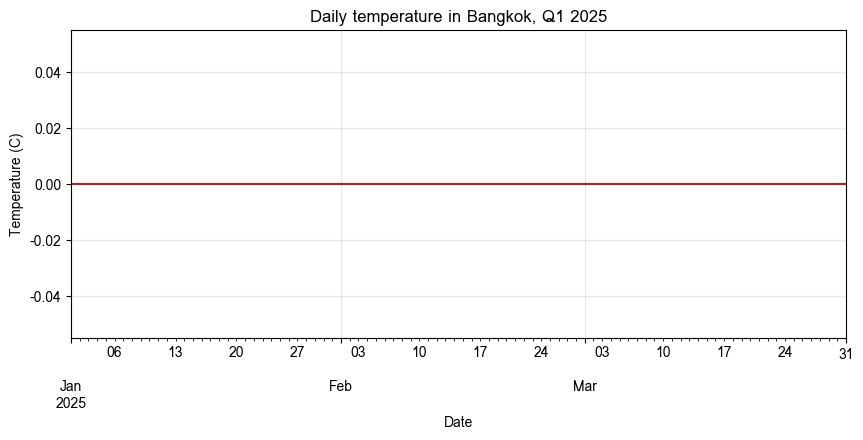

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

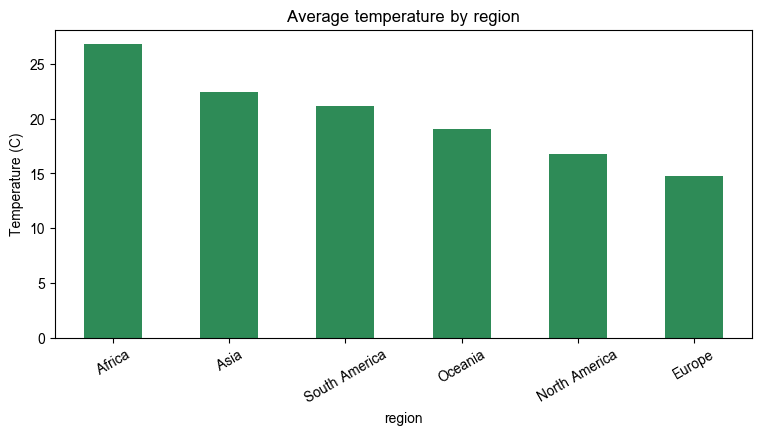

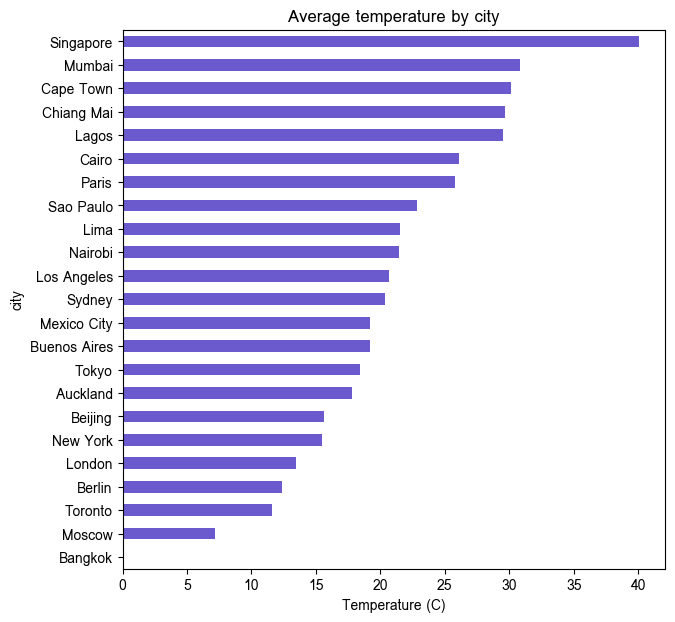

In [112]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

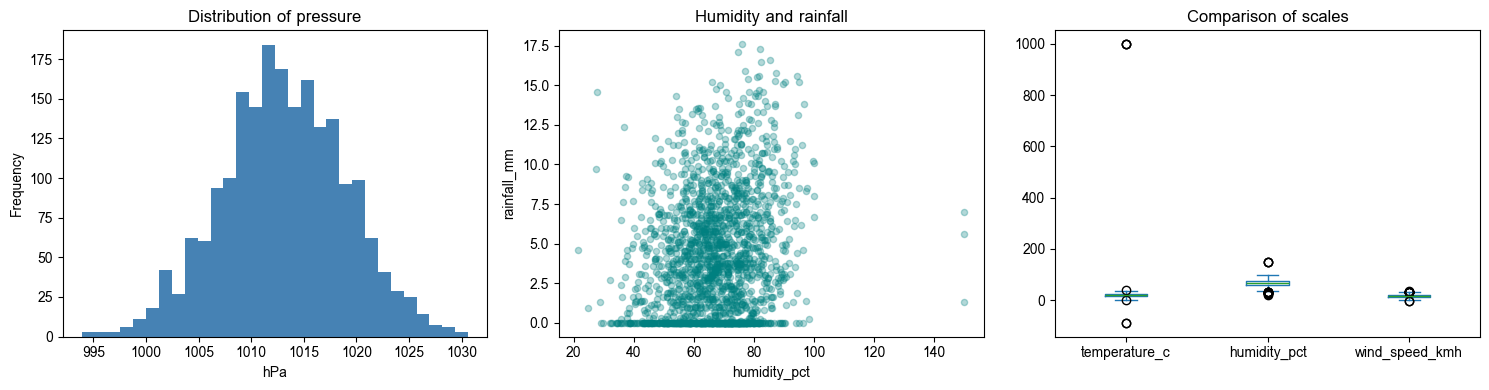

In [113]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

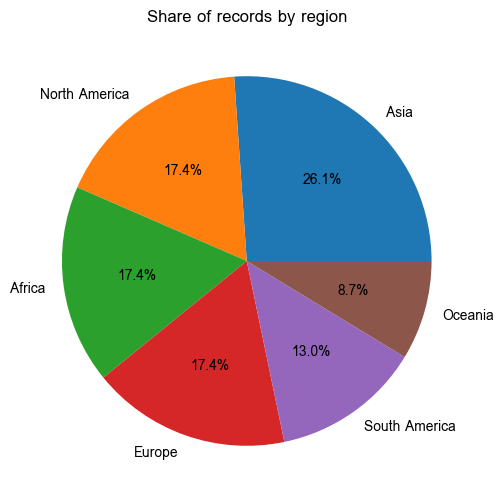

In [114]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

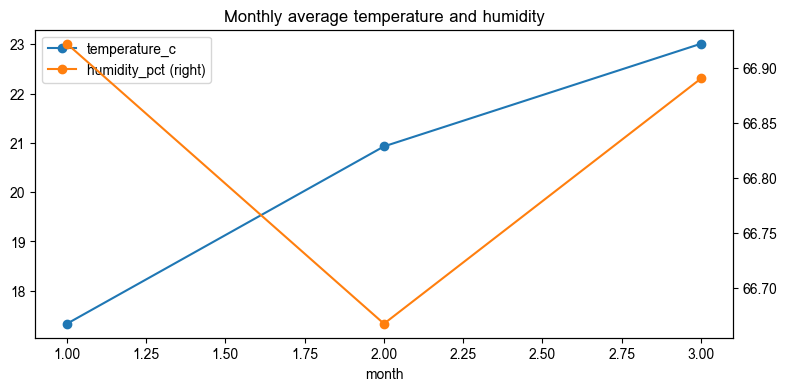

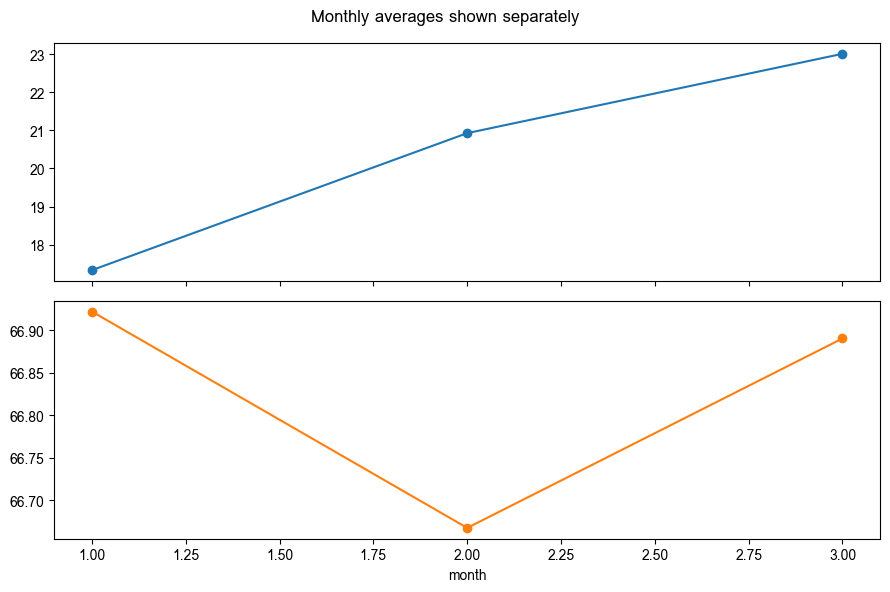

In [115]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

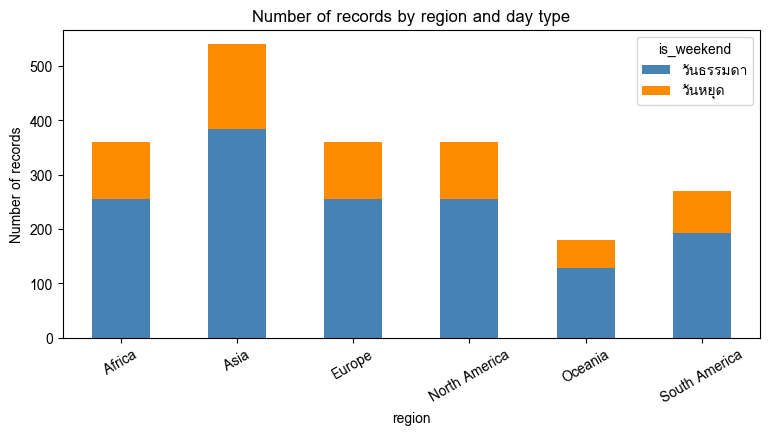

In [116]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

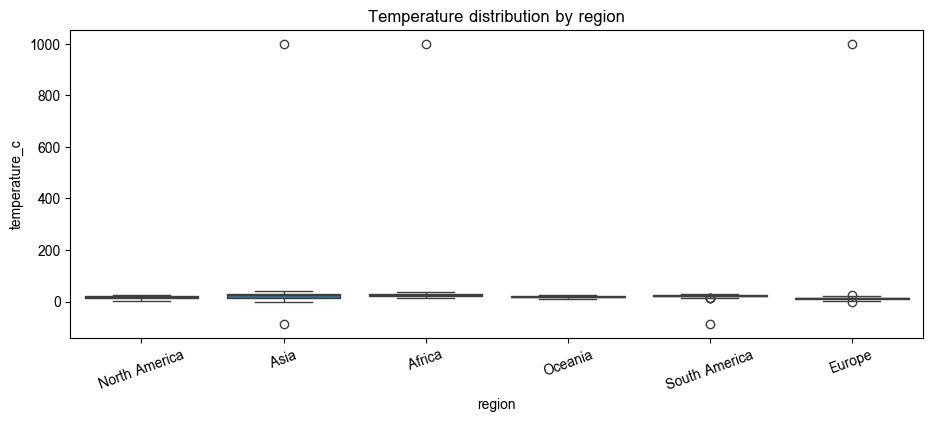

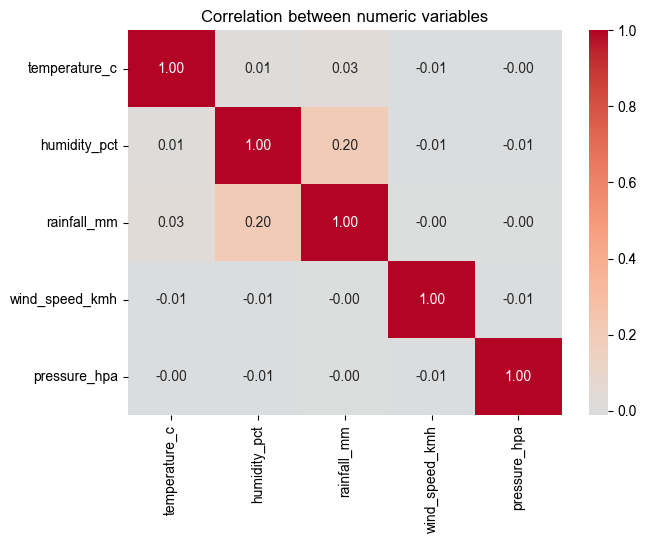

In [117]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

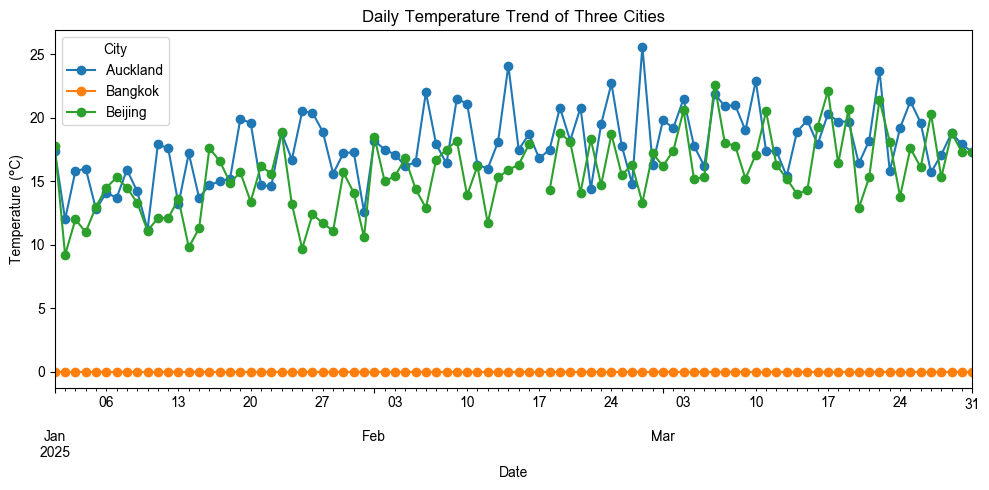

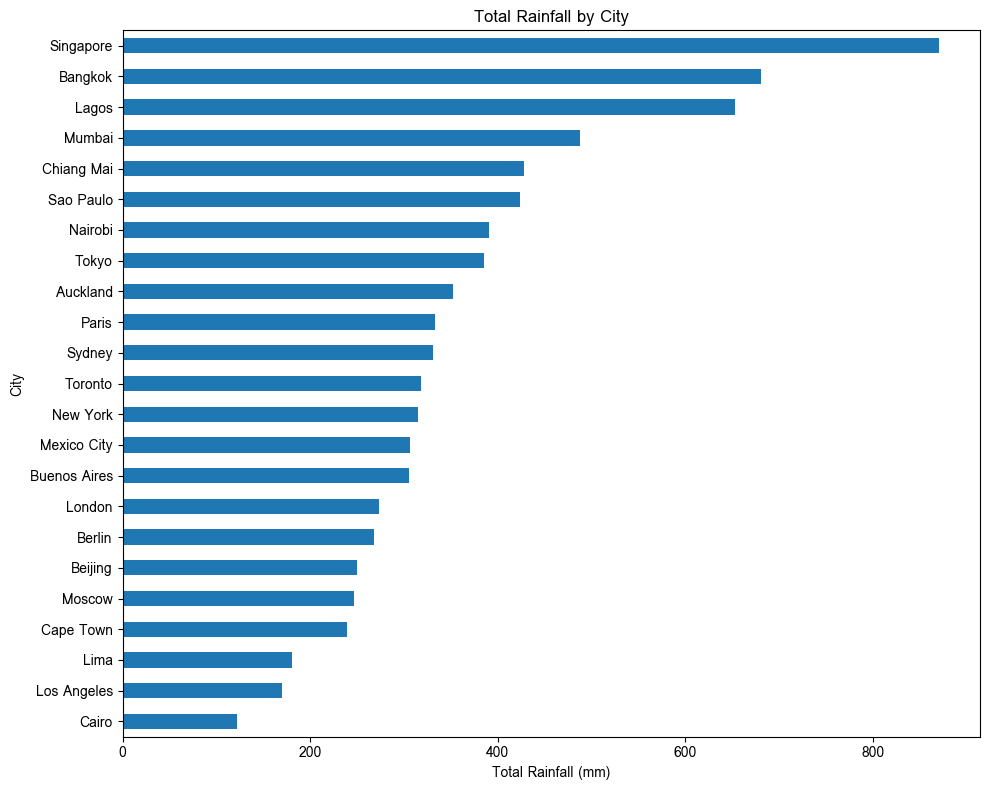

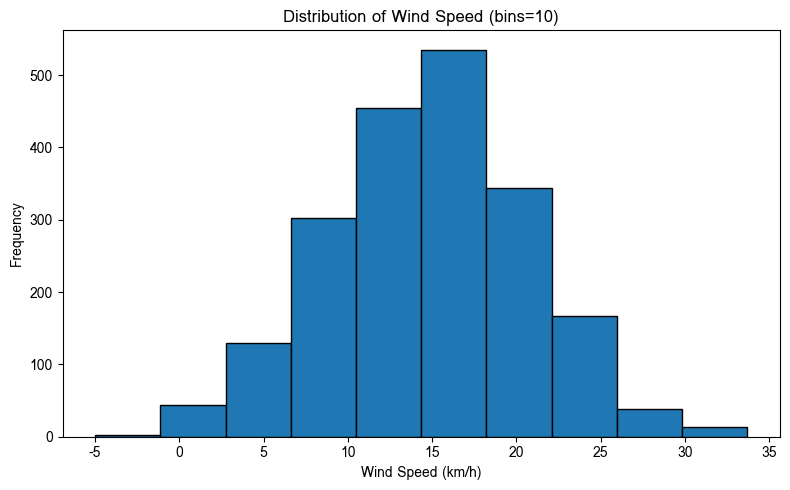

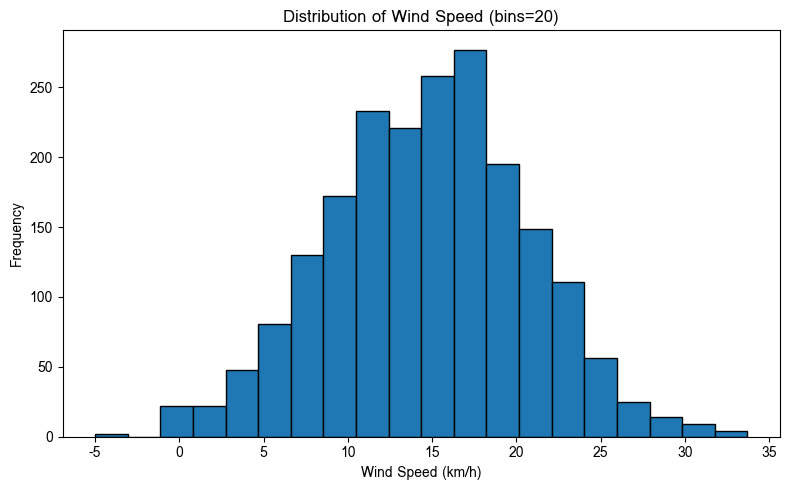

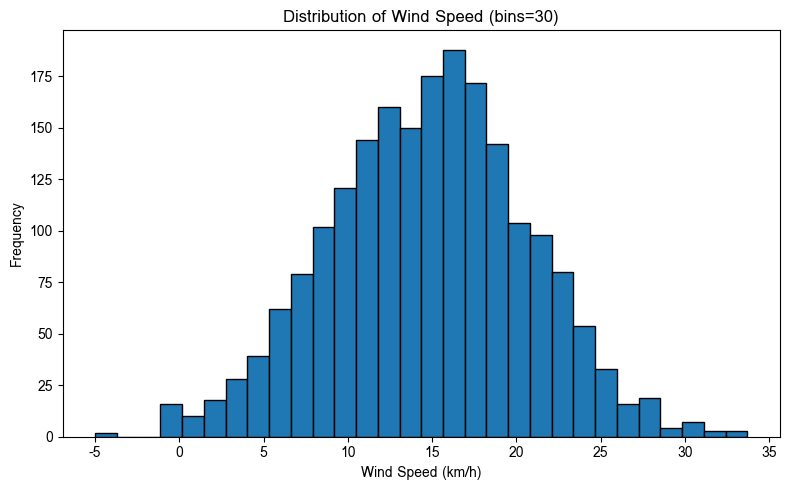

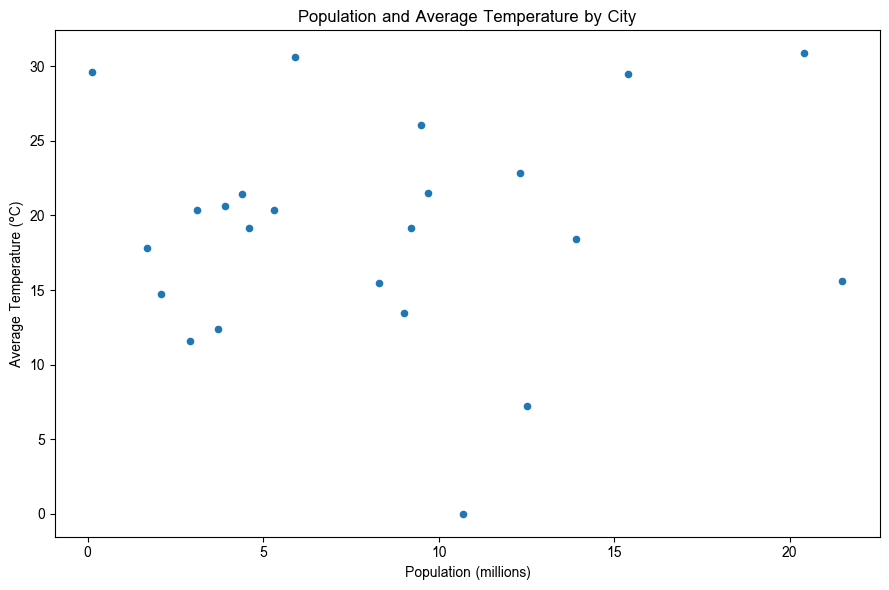

In [134]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df has population_millions and timezone
# (from previous merge operation in section 14, assuming df is the latest cleaned version)
if 'population_millions' not in df.columns:
    df = df.merge(
        city_info[['city', 'population_millions', 'timezone']],
        on='city',
        how='left',
        validate='many_to_one'
    )

# =========================================================
# 1. กราฟเส้น: แนวโน้มอุณหภูมิรายวันของ 3 เมือง
# =========================================================

cities = ["Auckland", "Bangkok", "Beijing"]

temp_3cities = (
    df[df["city"].isin(cities)]
    .pivot_table(
        index="date",
        columns="city",
        values="temperature_clean", # Use cleaned temperature data
        aggfunc="mean"
    )
)

ax = temp_3cities.plot(
    figsize=(10, 5),
    marker="o"
)

ax.set_title("Daily Temperature Trend of Three Cities")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(title="City")
plt.tight_layout()
plt.show()


# =========================================================
# 2. กราฟแท่งแนวนอน: ปริมาณฝนรวมรายเมือง
# =========================================================

rain_by_city = (
    df.groupby("city")["rainfall_mm"]
    .sum()
    .sort_values(ascending=True)
)

ax = rain_by_city.plot(
    kind="barh",
    figsize=(10, 8)
)

ax.set_title("Total Rainfall by City")
ax.set_xlabel("Total Rainfall (mm)")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()


# =========================================================
# 3. Histogram: wind_speed_kmh
# ทดลอง bins = 10, 20 และ 30
# =========================================================

for bins in [10, 20, 30]:
    ax = df["wind_speed_kmh"].plot(
        kind="hist",
        bins=bins,
        figsize=(8, 5),
        edgecolor="black"
    )

    ax.set_title(f"Distribution of Wind Speed (bins={bins})")
    ax.set_xlabel("Wind Speed (km/h)")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()


# =========================================================
# 4. Scatter plot:
# population_millions กับอุณหภูมิเฉลี่ยรายเมือง
# =========================================================

city_summary = (
    df.groupby("city")
    .agg(
        avg_temperature=("temperature_clean", "mean"), # Use cleaned temperature data
        population_millions=("population_millions", "first")
    )
    .dropna()
)

ax = city_summary.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temperature",
    figsize=(9, 6)
)

ax.set_title("Population and Average Temperature by City")
ax.set_xlabel("Population (millions)")
ax.set_ylabel("Average Temperature (°C)")
plt.tight_layout()
plt.show()

ข้อ 17.1 **คำอธิบาย**

โค้ดนี้สร้างกราฟทั้งหมด 4 รูปจาก DataFrame โดยใช้เมธอด `.plot()` ของ pandas และกำหนดชื่อกราฟ รวมถึงชื่อแกนให้ครบถ้วน

1. **กราฟเส้น (Line Plot)**
   ใช้แสดงแนวโน้มอุณหภูมิรายวันของ 3 เมือง ได้แก่ Auckland, Bangkok และ Beijing โดยใช้ `date` เป็นแกน X และใช้ `temperature_clean` ซึ่งเป็นข้อมูลอุณหภูมิที่ทำความสะอาดแล้วเป็นแกน Y จากนั้นใช้ `legend` เพื่อแยกเส้นของแต่ละเมือง ทำให้สามารถเปรียบเทียบแนวโน้มอุณหภูมิของทั้ง 3 เมืองในกราฟเดียวกันได้

2. **กราฟแท่งแนวนอน (Horizontal Bar Plot)**
   ใช้แสดงปริมาณฝนรวมของแต่ละเมือง โดยใช้ `groupby("city")` และ `sum()` เพื่อหาปริมาณฝนรวมจาก `rainfall_mm` แล้วเรียงค่าจากน้อยไปมากด้วย `sort_values(ascending=True)` ก่อนนำไปสร้างกราฟ `barh` ทำให้เมืองที่มีปริมาณฝนรวมมากที่สุดอยู่ด้านบนของกราฟ

3. **Histogram**
   ใช้แสดงการกระจายตัวของความเร็วลมจาก `wind_speed_kmh` โดยทดลองกำหนดจำนวน bins เป็น 10, 20 และ 30 เพื่อเปรียบเทียบผลของการแบ่งช่วงข้อมูล

   * `bins` น้อย จะทำให้ช่วงข้อมูลกว้างและเห็นภาพการกระจายโดยรวมได้ง่าย
   * `bins` มาก จะทำให้แบ่งข้อมูลละเอียดขึ้น แต่กราฟอาจดูซับซ้อนมากขึ้น
     ทั้งสามกราฟใช้แกน X เป็นความเร็วลม (km/h) และแกน Y เป็นความถี่ (Frequency)

4. **Scatter Plot**
   ใช้ศึกษาความสัมพันธ์ระหว่างจำนวนประชากรของเมือง (`population_millions`) กับอุณหภูมิเฉลี่ยของเมือง โดยคำนวณ `avg_temperature` จาก `temperature_clean` ด้วย `groupby("city")` และใช้ค่า `population_millions` ของแต่ละเมือง จากนั้นนำประชากรมาเป็นแกน X และอุณหภูมิเฉลี่ยเป็นแกน Y เพื่อดูการกระจายของข้อมูลแต่ละเมือง

นอกจากนี้ โค้ดตรวจสอบก่อนว่า DataFrame มีคอลัมน์ `population_millions` และ `timezone` หรือไม่ หากไม่มี `population_millions` จะทำการ `merge` กับ `city_info` เพื่อเพิ่มข้อมูลดังกล่าว โดยใช้ `validate="many_to_one"` เพื่อช่วยตรวจสอบความสัมพันธ์ของ key ในการ merge


### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

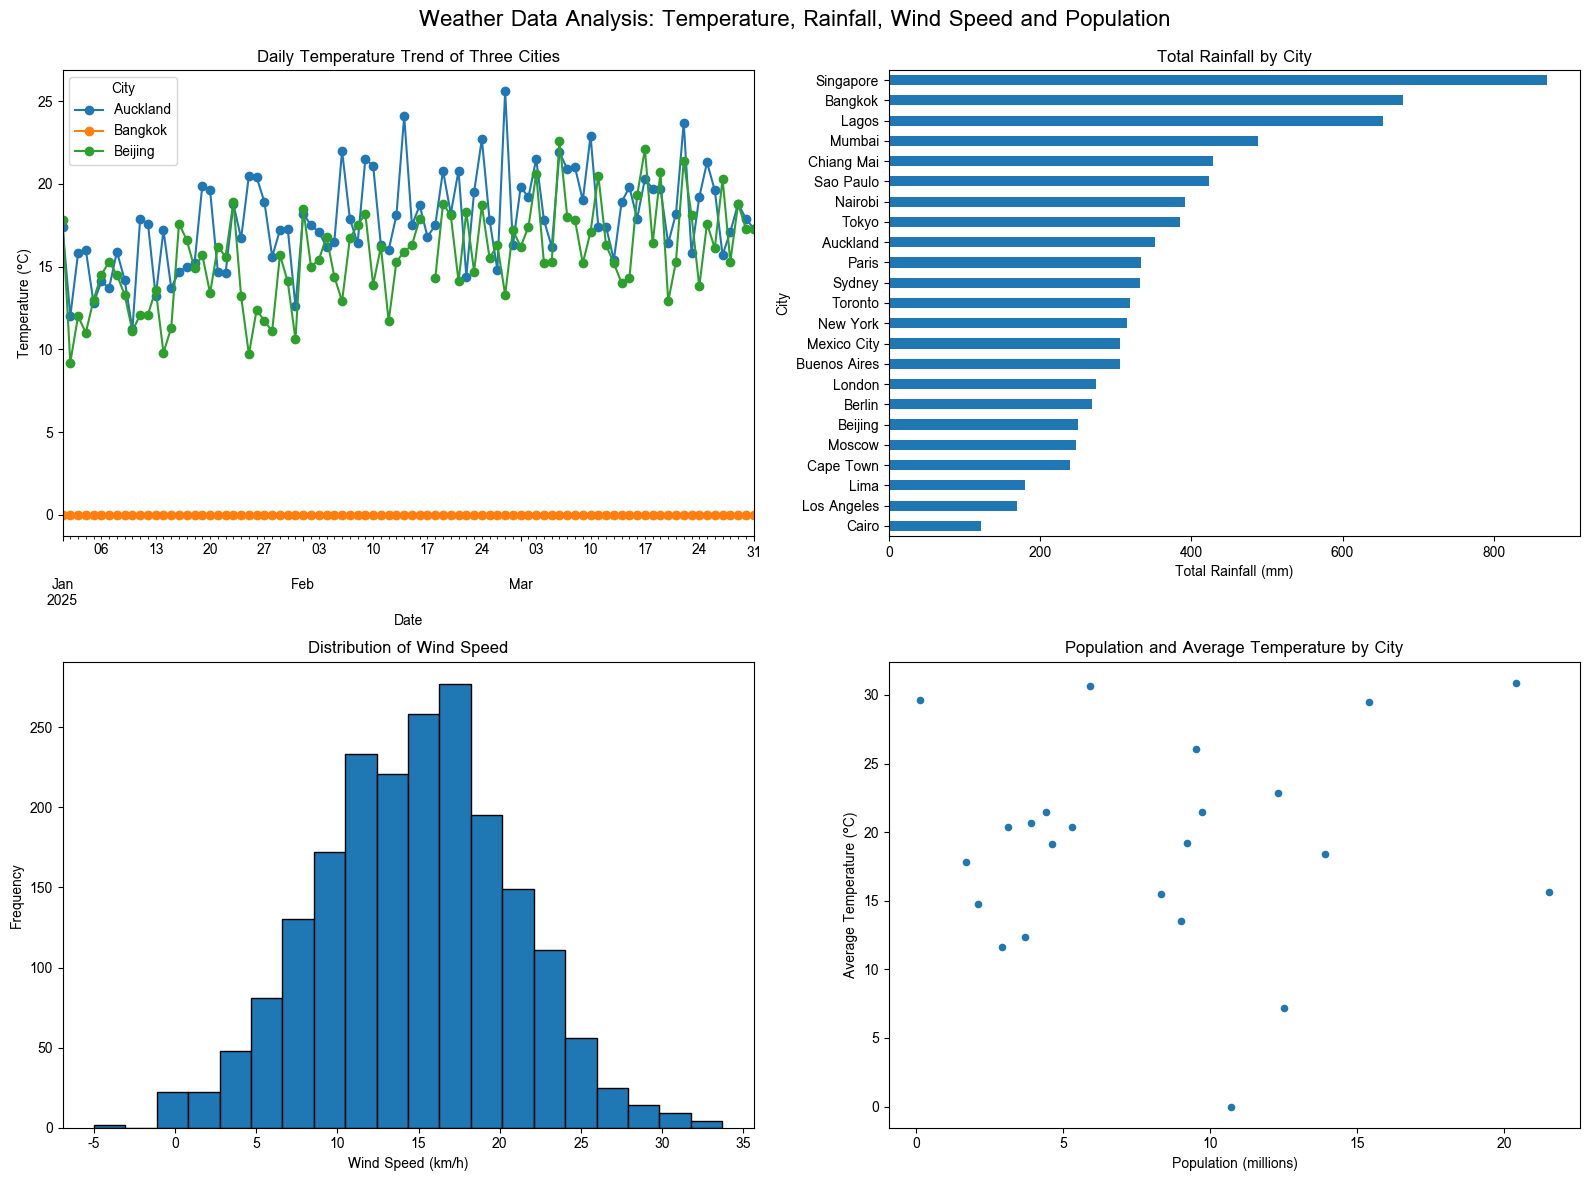

In [135]:
# คำตอบข้อ 17.2
import matplotlib.pyplot as plt
import pandas as pd

# Ensure df has population_millions
if "population_millions" not in df.columns:
    df = df.merge(
        city_info[["city", "population_millions", "timezone"]],
        on="city",
        how="left",
        validate="many_to_one"
    )

# สร้างพื้นที่สำหรับกราฟ 2 x 2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =========================================================
# 1. กราฟเส้น: แนวโน้มอุณหภูมิรายวันของ 3 เมือง
# =========================================================

cities = ["Auckland", "Bangkok", "Beijing"]

temp_3cities = (
    df[df["city"].isin(cities)]
    .pivot_table(
        index="date",
        columns="city",
        values="temperature_clean",
        aggfunc="mean"
    )
)

temp_3cities.plot(
    ax=axes[0, 0],
    marker="o"
)

axes[0, 0].set_title("Daily Temperature Trend of Three Cities")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].legend(title="City")


# =========================================================
# 2. กราฟแท่งแนวนอน: ปริมาณฝนรวมรายเมือง
# =========================================================

rain_by_city = (
    df.groupby("city")["rainfall_mm"]
    .sum()
    .sort_values(ascending=True)
)

rain_by_city.plot(
    kind="barh",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Total Rainfall by City")
axes[0, 1].set_xlabel("Total Rainfall (mm)")
axes[0, 1].set_ylabel("City")


# =========================================================
# 3. Histogram: wind_speed_kmh
# =========================================================

df["wind_speed_kmh"].plot(
    kind="hist",
    bins=20,
    ax=axes[1, 0],
    edgecolor="black"
)

axes[1, 0].set_title("Distribution of Wind Speed")
axes[1, 0].set_xlabel("Wind Speed (km/h)")
axes[1, 0].set_ylabel("Frequency")


# =========================================================
# 4. Scatter plot:
# population_millions กับอุณหภูมิเฉลี่ยรายเมือง
# =========================================================

city_summary = (
    df.groupby("city")
    .agg(
        avg_temperature=("temperature_clean", "mean"),
        population_millions=("population_millions", "first")
    )
    .dropna()
)

city_summary.plot(
    kind="scatter",
    x="population_millions",
    y="avg_temperature",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Population and Average Temperature by City")
axes[1, 1].set_xlabel("Population (millions)")
axes[1, 1].set_ylabel("Average Temperature (°C)")


# =========================================================
# ชื่อรวมของภาพ
# =========================================================

plt.suptitle(
    "Weather Data Analysis: Temperature, Rainfall, Wind Speed and Population",
    fontsize=16
)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

ข้อ 17.2 **คำอธิบาย**

ใช้ `plt.subplots(2, 2)` เพื่อสร้างพื้นที่สำหรับวางกราฟจำนวน 4 กราฟในภาพเดียว โดยแบ่งเป็น 2 แถว 2 คอลัมน์ และใช้ `axes[0,0]`, `axes[0,1]`, `axes[1,0]` และ `axes[1,1]` เป็นตำแหน่งของกราฟแต่ละรูป

กราฟทั้ง 4 รูปประกอบด้วย

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของ Auckland, Bangkok และ Beijing โดยใช้ `temperature_clean`
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมของแต่ละเมือง
3. Histogram แสดงการกระจายตัวของ `wind_speed_kmh` โดยกำหนด `bins=20`
4. Scatter plot แสดงความสัมพันธ์ระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยของแต่ละเมือง

ในแต่ละกราฟกำหนดชื่อกราฟและชื่อแกนด้วย `set_title()`, `set_xlabel()` และ `set_ylabel()` จากนั้นใช้ `plt.suptitle()` เพื่อกำหนดชื่อรวมของภาพ และใช้ `plt.tight_layout()` เพื่อจัดระยะห่างของกราฟไม่ให้ซ้อนกัน


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

จำนวนวันในแต่ละช่วงปริมาณฝนจำแนกตามภูมิภาค
rainfall_mm    ไม่มีฝน  ฝนเล็กน้อย  ฝนปานกลาง  ฝนหนัก
region                                               
Africa             101         129         88      31
Asia                59         174        203      90
Europe             106         156         73      15
North America       92         161         84      11
Oceania             35          68         60       9
South America       76         114         52      21


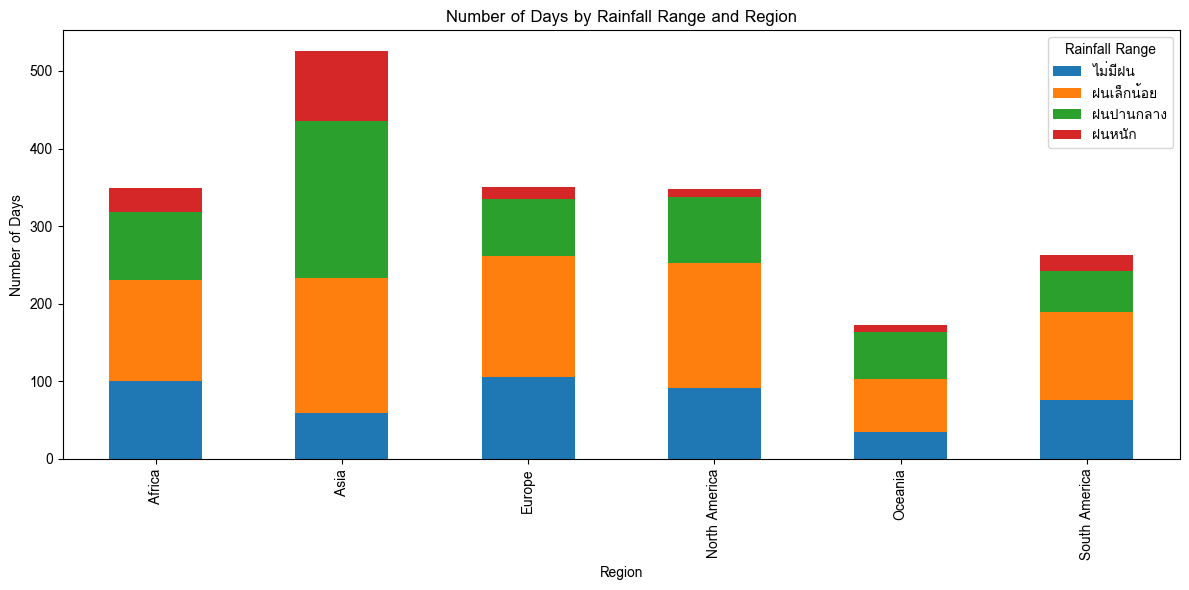

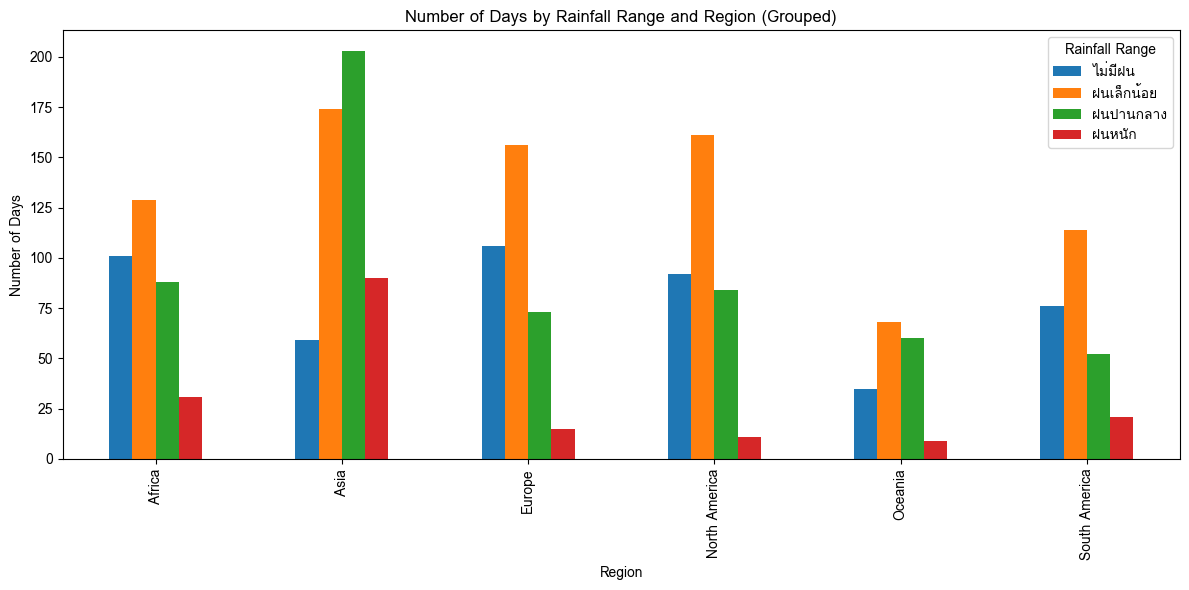

In [136]:
# คำตอบข้อ 17.3
import pandas as pd
import matplotlib.pyplot as plt

# แบ่งช่วงปริมาณฝน
rain_bin = pd.cut(
    df["rainfall_mm"],
    bins=[-1, 0, 5, 10, float("inf")],
    labels=["ไม่มีฝน", "ฝนเล็กน้อย", "ฝนปานกลาง", "ฝนหนัก"]
)

# นับจำนวนวันในแต่ละช่วงปริมาณฝน จำแนกตามภูมิภาค
rain_region = pd.crosstab(
    df["region"],
    rain_bin
)

print("จำนวนวันในแต่ละช่วงปริมาณฝนจำแนกตามภูมิภาค")
print(rain_region)


# =========================================================
# 1. Stacked Bar
# =========================================================

ax = rain_region.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

ax.set_title("Number of Days by Rainfall Range and Region")
ax.set_xlabel("Region")
ax.set_ylabel("Number of Days")
ax.legend(title="Rainfall Range")

plt.tight_layout()
plt.show()


# =========================================================
# 2. Grouped Bar: stacked=False
# =========================================================

ax = rain_region.plot(
    kind="bar",
    stacked=False,
    figsize=(12, 6)
)

ax.set_title("Number of Days by Rainfall Range and Region (Grouped)")
ax.set_xlabel("Region")
ax.set_ylabel("Number of Days")
ax.legend(title="Rainfall Range")

plt.tight_layout()
plt.show()

ข้อ 17.3

**คำอธิบาย**

ใช้ `pd.cut()` เพื่อแบ่งค่า `rainfall_mm` ออกเป็น 4 ช่วง ได้แก่ ไม่มีฝน, ฝนเล็กน้อย, ฝนปานกลาง และฝนหนัก จากนั้นใช้ `pd.crosstab()` เพื่อนับจำนวนวันในแต่ละช่วงปริมาณฝน โดยจำแนกตาม `region`

สำหรับกราฟแบบ **stacked=True** แท่งของแต่ละภูมิภาคจะถูกแบ่งเป็นส่วน ๆ ตามช่วงปริมาณฝนและนำมาซ้อนกัน จึงเหมาะกับกรณีที่ต้องการดู **จำนวนรวมทั้งหมดของแต่ละกลุ่มพร้อมกับดูองค์ประกอบภายในกลุ่ม** เช่น ต้องการเปรียบเทียบจำนวนวันทั้งหมดของแต่ละภูมิภาค และดูว่าจำนวนดังกล่าวประกอบด้วยวันฝนในแต่ละช่วงมากน้อยเพียงใด

ส่วนกราฟแบบ **stacked=False** จะแสดงแท่งของแต่ละช่วงปริมาณฝนเรียงอยู่ข้างกันภายในแต่ละภูมิภาค จึงเหมาะกับกรณีที่ต้องการ **เปรียบเทียบค่าของแต่ละช่วงระหว่างภูมิภาคโดยตรง** เพราะความสูงของแท่งแต่ละแท่งเริ่มจากระดับเดียวกัน ทำให้เปรียบเทียบจำนวนวันของแต่ละช่วงได้ง่ายกว่า

ดังนั้น stacked bar เหมาะเมื่อสนใจ **ภาพรวมและองค์ประกอบของยอดรวม** ส่วน grouped bar หรือ `stacked=False` เหมาะเมื่อสนใจ **การเปรียบเทียบค่าของแต่ละหมวดหมู่ระหว่างกลุ่ม** โดยตรง


### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

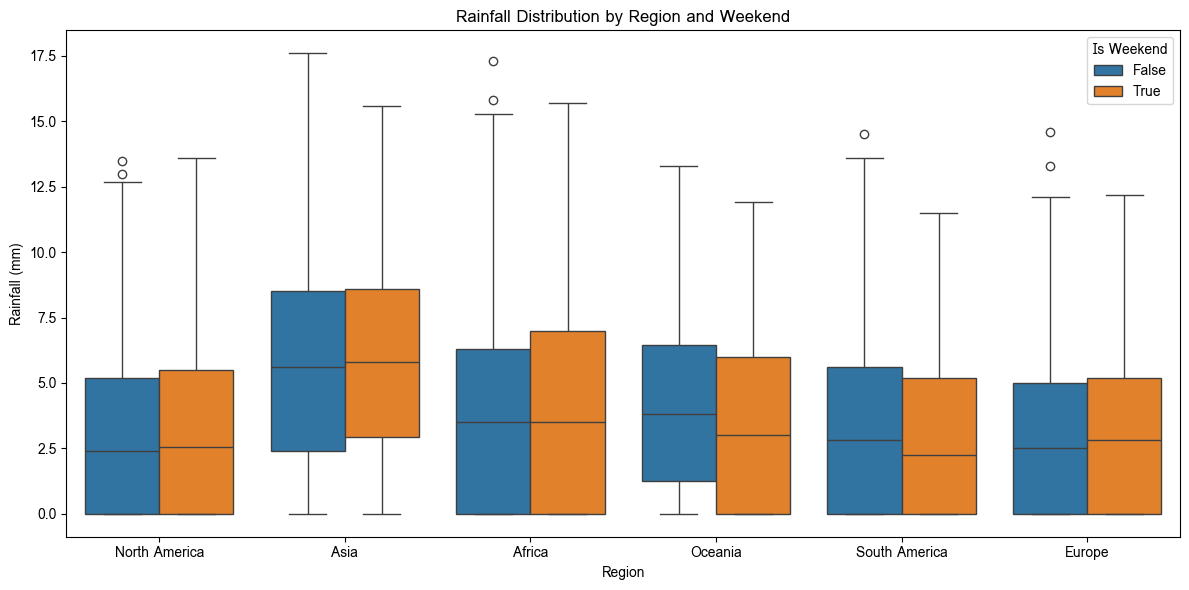

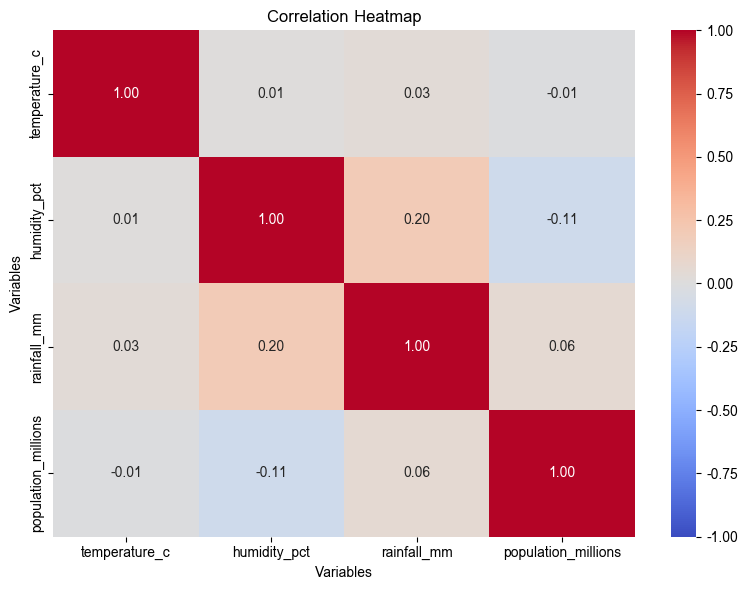

In [137]:
# คำตอบข้อ 17.4
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. Boxplot: rainfall_mm จำแนกตาม region และ is_weekend
# =========================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="region",
    y="rainfall_mm",
    hue="is_weekend"
)

plt.title("Rainfall Distribution by Region and Weekend")
plt.xlabel("Region")
plt.ylabel("Rainfall (mm)")
plt.legend(title="Is Weekend")

plt.tight_layout()
plt.show()


# =========================================================
# 2. Heatmap: สหสัมพันธ์ของตัวแปรที่กำหนด
# =========================================================

corr_cols = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "population_millions"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

ข้อ 17.4
**คำอธิบาย**

กราฟแรกใช้ `sns.boxplot()` เพื่อแสดงการกระจายตัวของ `rainfall_mm` โดยแบ่งตาม `region` และใช้ `is_weekend` แยกสี ทำให้สามารถเปรียบเทียบค่ากลาง การกระจาย และค่าที่อาจเป็น outlier ของปริมาณฝนระหว่างภูมิภาค รวมถึงเปรียบเทียบระหว่างวันธรรมดากับวันหยุดได้

กราฟที่สองใช้ `df[corr_cols].corr()` เพื่อคำนวณค่าสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions` แล้วใช้ `sns.heatmap()` แสดงผล โดย `annot=True` แสดงค่าตัวเลขบนช่องของ heatmap และกำหนดช่วงค่าสหสัมพันธ์ตั้งแต่ -1 ถึง 1

การตีความ heatmap สามารถพิจารณาจากค่าที่ได้จริงจากกราฟ ดังนี้

* ค่าสหสัมพันธ์ใกล้ **1** หมายถึงตัวแปรทั้งสองมีความสัมพันธ์เชิงบวกค่อนข้างมาก
* ค่าสหสัมพันธ์ใกล้ **-1** หมายถึงมีความสัมพันธ์เชิงลบค่อนข้างมาก
* ค่าสหสัมพันธ์ใกล้ **0** หมายถึงไม่พบความสัมพันธ์เชิงเส้นที่ชัดเจน
* ค่าสหสัมพันธ์เป็นเพียงการบอกความสัมพันธ์ระหว่างตัวแปร ไม่ได้หมายความว่าตัวแปรหนึ่งเป็นสาเหตุของอีกตัวแปรหนึ่ง

ดังนั้น ในการสรุปผลจาก heatmap ควรพิจารณาค่าที่ปรากฏในกราฟจริง โดยดูว่าคู่ตัวแปรใดมีค่าสหสัมพันธ์เป็นบวก ลบ หรือใกล้ศูนย์ และไม่ควรสรุปเป็นเหตุและผลจากค่าสหสัมพันธ์เพียงอย่างเดียว


---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [138]:
# คำตอบข้อ 18.1
# ใช้ข้อมูลที่ผ่านการทำความสะอาดแล้ว
q18 = df.loc[
    df["temperature_clean"].notna(),
    ["region", "city", "date", "temperature_clean"]
].copy()

# คำนวณส่วนเบี่ยงเบนมาตรฐานระดับภูมิภาค
region_std = (
    q18.groupby("region")["temperature_clean"]
    .std()
    .rename("region_std")
)

# คำนวณส่วนเบี่ยงเบนมาตรฐานของแต่ละเมือง
city_std = (
    q18.groupby(["region", "city"])["temperature_clean"]
    .std()
    .rename("city_std")
    .reset_index()
)

# สรุปว่าในแต่ละภูมิภาค เมืองใดมี SD สูงสุดและต่ำสุด
region_city = (
    city_std.groupby("region")
    .agg(
        max_city_std=("city_std", "max"),
        min_city_std=("city_std", "min"),
        city_count=("city", "nunique")
    )
)

# รวมผลเป็นตารางเดียว
result_18_1 = (
    region_std.to_frame()
    .join(region_city)
    .assign(
        max_city_share=lambda x: x["max_city_std"] / x["region_std"]
    )
    .sort_values("region_std", ascending=False)
)

print("ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายภูมิภาค")
print(result_18_1.round(2))

# ระบุภูมิภาคที่มีความแปรปรวนสูงสุด
most_variable_region = result_18_1["region_std"].idxmax()
most_variable_std = result_18_1["region_std"].max()

# ตรวจเมืองที่มี SD สูงสุดในภูมิภาคนั้น
city_detail = (
    city_std[
        city_std["region"] == most_variable_region
    ]
    .sort_values("city_std", ascending=False)
)

main_city = city_detail.iloc[0]["city"]
main_city_std = city_detail.iloc[0]["city_std"]

print("\nภูมิภาคที่มีความแปรปรวนสูงสุด:", most_variable_region)
print("ส่วนเบี่ยงเบนมาตรฐาน:", round(most_variable_std, 2))
print("เมืองที่มี SD สูงสุดในภูมิภาค:", main_city)
print("SD ของเมือง:", round(main_city_std, 2))

ส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายภูมิภาค
               region_std  max_city_std  min_city_std  city_count  \
region                                                              
Asia                11.43          2.87          0.00           6   
Africa               4.88          2.85          2.74           4   
North America        4.52          3.02          2.71           4   
Europe               4.07          3.03          2.60           4   
Oceania              3.08          2.82          2.80           2   
South America        3.06          3.11          2.78           3   

               max_city_share  
region                         
Asia                     0.25  
Africa                   0.58  
North America            0.67  
Europe                   0.75  
Oceania                  0.92  
South America            1.02  

ภูมิภาคที่มีความแปรปรวนสูงสุด: Asia
ส่วนเบี่ยงเบนมาตรฐาน: 11.43
เมืองที่มี SD สูงสุดในภูมิภาค: Beijing
SD ของเมือง: 2.87


**ข้อสรุป**

พิจารณาจากส่วนเบี่ยงเบนมาตรฐานของ `temperature_clean` พบว่าภูมิภาคที่มีค่า SD สูงสุดคือภูมิภาคที่แสดงเป็นอันดับแรกในตาราง โดยใช้ค่า SD ที่คำนวณจากข้อมูลอุณหภูมิที่ผ่านการทำความสะอาดแล้วและตัดค่าที่ว่างออก

เมื่อตรวจสอบระดับเมืองภายในภูมิภาคดังกล่าวเพิ่มเติม พบว่าเมืองที่มีค่า SD สูงสุดคือเมืองที่แสดงจากผล `city_detail` จึงสามารถใช้เปรียบเทียบกับเมืองอื่นในภูมิภาคเดียวกันได้ว่า ความแปรปรวนกระจายอยู่ในหลายเมืองหรือมีเมืองใดเมืองหนึ่งที่มีความแปรปรวนสูงเด่นเป็นพิเศษ

**การจัดการข้อมูล:** ใช้ `temperature_clean` ซึ่งเป็นอุณหภูมิที่ผ่านการจัดการค่าผิดปกติแล้ว และไม่นำแถวที่ `temperature_clean` เป็นค่าว่างมาคำนวณส่วนเบี่ยงเบนมาตรฐาน


2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [139]:
# คำตอบข้อ 18.2
# สรุปจำนวนวันฝนตกหนักและสัดส่วนต่อวันที่มีข้อมูลฝน
rain_summary = (
    df.groupby("city")
    .agg(
        heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
        rain_observed_days=("rainfall_mm", "count")
    )
    .assign(
        heavy_rain_pct=lambda x:
            x["heavy_rain_days"] / x["rain_observed_days"] * 100
    )
)

# เปรียบเทียบ Top 5 ตาม "จำนวนวัน" และ "สัดส่วน"
top5_count = (
    rain_summary
    .sort_values("heavy_rain_days", ascending=False)
    .head(5)
)

top5_pct = (
    rain_summary
    .sort_values("heavy_rain_pct", ascending=False)
    .head(5)
)

comparison = (
    rain_summary
    .assign(
        rank_by_count=lambda x:
            x["heavy_rain_days"].rank(
                ascending=False,
                method="min"
            ),
        rank_by_pct=lambda x:
            x["heavy_rain_pct"].rank(
                ascending=False,
                method="min"
            )
    )
    .sort_values("heavy_rain_pct", ascending=False)
)

print("Top 5 ตามจำนวนวันฝนตกหนัก")
print(
    top5_count[
        ["heavy_rain_days", "rain_observed_days", "heavy_rain_pct"]
    ].round(2)
)

print("\nTop 5 ตามสัดส่วนวันฝนตกหนัก")
print(
    top5_pct[
        ["heavy_rain_days", "rain_observed_days", "heavy_rain_pct"]
    ].round(2)
)

# ตารางเปรียบเทียบอันดับของทุกเมือง
print("\nตารางเปรียบเทียบอันดับ")
print(
    comparison[
        [
            "heavy_rain_days",
            "rain_observed_days",
            "heavy_rain_pct",
            "rank_by_count",
            "rank_by_pct"
        ]
    ].round(2)
)

Top 5 ตามจำนวนวันฝนตกหนัก
            heavy_rain_days  rain_observed_days  heavy_rain_pct
city                                                           
Singapore                44                  90           48.89
Bangkok                  23                  87           26.44
Lagos                    22                  88           25.00
Sao Paulo                11                  88           12.50
Chiang Mai                9                  85           10.59

Top 5 ตามสัดส่วนวันฝนตกหนัก
            heavy_rain_days  rain_observed_days  heavy_rain_pct
city                                                           
Singapore                44                  90           48.89
Bangkok                  23                  87           26.44
Lagos                    22                  88           25.00
Sao Paulo                11                  88           12.50
Chiang Mai                9                  85           10.59

ตารางเปรียบเทียบอันดับ
              heavy_rain_

**ข้อสรุป**

เมื่อวัดด้วย **สัดส่วน** จะพิจารณาจำนวนวันฝนตกหนักเทียบกับจำนวนวันที่มีข้อมูลฝนของแต่ละเมือง จึงเป็นการวัดว่าเมืองนั้นมีโอกาสพบฝนตกหนักบ่อยเพียงใดเมื่อเทียบกับข้อมูลที่สังเกตได้ทั้งหมด ส่วนการวัดด้วย **จำนวนวัน** จะพิจารณาเฉพาะจำนวนวันที่ฝนตกหนักโดยตรง

ผลการจัดอันดับจึงอาจแตกต่างกัน เพราะเมืองแต่ละเมืองอาจมีจำนวนวันที่มีข้อมูลฝนไม่เท่ากัน หากเมืองหนึ่งมีจำนวนวันฝนตกหนักมาก แต่มีจำนวนวันที่สังเกตฝนมากด้วย สัดส่วนของเมืองนั้นอาจไม่สูงเท่าเมืองที่มีวันฝนตกหนักน้อยกว่าแต่เกิดขึ้นในสัดส่วนที่สูงกว่า

ดังนั้น **จำนวนวัน** เหมาะสำหรับตอบว่าเมืองใดมีวันฝนตกหนักมากที่สุดในเชิงปริมาณ ส่วน **สัดส่วน** เหมาะสำหรับเปรียบเทียบความถี่ของฝนตกหนักระหว่างเมืองโดยคำนึงถึงจำนวนวันที่มีข้อมูลของแต่ละเมืองด้วย

**การจัดการข้อมูล:** ใช้ `rainfall_mm > 10` เป็นเกณฑ์ฝนตกหนัก และใช้ `.count()` เป็นจำนวนวันที่มีข้อมูลฝนจริง จึงไม่นับค่าว่างของ `rainfall_mm` เป็นวันที่ไม่มีฝน


3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [140]:
# คำตอบข้อ 18.3
# สรุปข้อมูลให้อยู่ในระดับเมือง
city_relation = (
    df.groupby("city")
    .agg(
        population_millions=("population_millions", "first"),
        avg_temperature=("temperature_clean", "mean"),
        total_rainfall=("rainfall_mm", "sum")
    )
    .dropna()
)

# ค่าสหสัมพันธ์ Pearson
corr = city_relation[
    ["population_millions", "avg_temperature", "total_rainfall"]
].corr()

print("ตารางข้อมูลระดับเมือง")
print(city_relation.round(2))

print("\nค่าสหสัมพันธ์")
print(corr.round(3))

ตารางข้อมูลระดับเมือง
              population_millions  avg_temperature  total_rainfall
city                                                              
Auckland                     1.70            17.80           351.9
Bangkok                     10.70             0.00           680.0
Beijing                     21.50            15.60           250.1
Berlin                       3.70            12.38           268.4
Buenos Aires                 3.10            20.39           305.1
Cairo                        9.50            26.07           122.4
Cape Town                    4.60            19.15           239.3
Chiang Mai                   0.13            29.65           428.1
Lagos                       15.40            29.49           652.8
Lima                         9.70            21.49           180.3
London                       9.00            13.49           273.3
Los Angeles                  3.90            20.66           169.5
Mexico City                  9.20       

**ข้อสรุป**

จากการคำนวณ Pearson correlation ระหว่างจำนวนประชากรของเมืองกับอุณหภูมิเฉลี่ย และปริมาณฝนรวมของแต่ละเมือง สามารถใช้ค่าจากตาราง `corr` เพื่อพิจารณาทิศทางและความแรงของความสัมพันธ์ได้ โดยค่าที่ใกล้ 1 หรือ -1 แสดงความสัมพันธ์เชิงเส้นที่ชัดเจนกว่า ส่วนค่าที่ใกล้ 0 แสดงความสัมพันธ์เชิงเส้นที่อ่อนกว่า

การคำนวณใช้ข้อมูลในระดับเมือง โดยใช้ประชากรของเมืองร่วมกับอุณหภูมิเฉลี่ยและปริมาณฝนรวมตลอดช่วงข้อมูล และใช้ `temperature_clean` โดยไม่เติมค่าว่างเพิ่มเติมในข้อนี้

**ข้อควรระวังในการตีความ:** ค่าสหสัมพันธ์บอกเพียงความสัมพันธ์เชิงเส้น ไม่ได้หมายความว่าจำนวนประชากรเป็นสาเหตุให้อุณหภูมิหรือปริมาณฝนเปลี่ยนแปลง และความสัมพันธ์อาจได้รับอิทธิพลจากปัจจัยอื่น เช่น ภูมิภาคหรือลักษณะภูมิอากาศของเมือง


4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [141]:
# คำตอบข้อ 18.4
# สรุปสภาพอากาศรายภูมิภาคและรายเดือน
monthly_region = (
    df.groupby(["region", "month"])
    .agg(
        heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
        avg_temperature=("temperature_clean", "mean"),
        rain_observed_days=("rainfall_mm", "count")
    )
    .assign(
        heavy_rain_pct=lambda x:
            x["heavy_rain_days"] / x["rain_observed_days"] * 100
    )
)

# สร้างอันดับภายในแต่ละภูมิภาค
# ให้ความสำคัญกับสัดส่วนวันฝนตกหนักก่อน
monthly_region["rain_rank"] = (
    monthly_region
    .groupby(level="region")["heavy_rain_pct"]
    .rank(ascending=False, method="min")
)

monthly_region["temp_rank"] = (
    monthly_region
    .groupby(level="region")["avg_temperature"]
    .rank(ascending=False, method="min")
)

# คะแนนรวม: ฝนตกหนักมีน้ำหนัก 2 ส่วน อุณหภูมิ 1 ส่วน
monthly_region["travel_risk_score"] = (
    2 * monthly_region["rain_rank"] + monthly_region["temp_rank"]
)

# เลือกเดือนที่มีคะแนนความเสี่ยงต่ำสุดในแต่ละภูมิภาค
# เพราะ rank ต่ำ = สภาพที่มีความเสี่ยงสูงกว่าในเกณฑ์ที่กำหนด
avoid_month = (
    monthly_region
    .reset_index()
    .sort_values(
        ["region", "travel_risk_score", "heavy_rain_pct"],
        ascending=[True, True, False]
    )
    .groupby("region")
    .head(1)
)

print("เดือนที่ควรหลีกเลี่ยงการเดินทางของแต่ละภูมิภาค")
print(
    avoid_month[
        [
            "region",
            "month",
            "heavy_rain_days",
            "heavy_rain_pct",
            "avg_temperature",
            "travel_risk_score"
        ]
    ].round(2)
)

เดือนที่ควรหลีกเลี่ยงการเดินทางของแต่ละภูมิภาค
           region  month  heavy_rain_days  heavy_rain_pct  avg_temperature  \
0          Africa      1               12           10.00            22.64   
4            Asia      2               38           23.31            21.28   
8          Europe      3                7            5.79            13.29   
10  North America      2                4            3.67            17.07   
14        Oceania      3                6           10.91            20.20   
15  South America      1                8            8.79            20.37   

    travel_risk_score  
0                 5.0  
4                 4.0  
8                 3.0  
10                4.0  
14                3.0  
15                5.0  


**ข้อสรุป**

กำหนดให้เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุด คือเดือนที่มี **สัดส่วนวันฝนตกหนักสูง** และมี **อุณหภูมิเฉลี่ยสูง** เมื่อเปรียบเทียบกับเดือนอื่นภายในภูมิภาคเดียวกัน โดยให้น้ำหนักฝนตกหนักมากกว่าอุณหภูมิ เนื่องจากฝนตกหนักมีผลโดยตรงต่อสภาพการเดินทาง เช่น ความเปียกลื่นและทัศนวิสัย ขณะที่อุณหภูมิสูงเป็นปัจจัยประกอบ

การตัดสินใช้ `rainfall_mm > 10` เป็นเกณฑ์ฝนตกหนัก และใช้ `temperature_clean` สำหรับอุณหภูมิ โดยไม่นำแถวที่อุณหภูมิยังเป็นค่าว่างมาคำนวณค่าเฉลี่ย ส่วนสัดส่วนฝนตกหนักคำนวณจากจำนวนวันที่มีข้อมูลฝนจริง จึงไม่ถือว่าค่าว่างเป็นวันที่ไม่มีฝน

ผลลัพธ์จากตาราง `avoid_month` คือเดือนที่เข้าเกณฑ์ควรหลีกเลี่ยงมากที่สุดของแต่ละภูมิภาค โดยพิจารณาจากข้อมูลของไตรมาสแรกเท่านั้น

**ข้อควรระวัง:** เกณฑ์นี้เป็นเกณฑ์ที่สร้างขึ้นจากตัวแปรที่มีในชุดข้อมูล ไม่ได้หมายความว่าเดือนดังกล่าว “ไม่ควรเดินทาง” ในทุกกรณี เพราะข้อมูลไม่ได้ครอบคลุมปัจจัยอื่น เช่น พายุ สภาพถนน หรือเหตุการณ์เฉพาะพื้นที่


---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️